# 1\.5\.4 Engineer Temporal Decomposition and Residual Features

This notebook creates temporal decomposition features that separate recurring same\-bucket mobility structure from residual mobility variation across the seven core mobility metrics\. The notebook evaluates decomposition options, adopts STL as the production seasonal/residual framework, and adds Fourier top 20 residual reconstruction as a focused second\-layer feature\. Trend outputs are intentionally excluded from the final feature panel because trend\-oriented temporal features were already created in 1\.5\.1\. Traffic is also excluded from the MVP decomposition framework because its irregular sampling schedule requires a separate strategy\. 

In [1]:
%pip install statsmodels
%pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 32.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 96.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import warnings
import time
import gc

import duckdb
import numpy as np
import pandas as pd

try:
    from statsmodels.tsa.seasonal import STL
except ImportError:
    STL = None

try:
    import matplotlib.pyplot as plt
    from cycler import cycler
except ImportError:
    plt = None

try:
    import pywt
except ImportError:
    pywt = None

from project_branding import (
    BRAND_COLORS,
    BRAND_COLOR_SEQUENCE,
)

warnings.filterwarnings("ignore")

if plt is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=BRAND_COLOR_SEQUENCE)
    plt.rcParams["axes.facecolor"] = BRAND_COLORS["ice"]
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.edgecolor"] = BRAND_COLORS["dark_teal"]
    plt.rcParams["axes.labelcolor"] = BRAND_COLORS["dark_teal"]
    plt.rcParams["xtick.color"] = BRAND_COLORS["dark_teal"]
    plt.rcParams["ytick.color"] = BRAND_COLORS["dark_teal"]
    plt.rcParams["text.color"] = BRAND_COLORS["dark_teal"]

def style_brand_axis(ax):
    ax.set_facecolor(BRAND_COLORS["ice"])
    ax.grid(color=BRAND_COLORS["dark_teal"], alpha=0.12, linewidth=0.8)

    for spine in ax.spines.values():
        spine.set_color(BRAND_COLORS["dark_teal"])
        spine.set_alpha(0.45)

    return ax

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

In [3]:
# ---------------------------------------------------------------------
# Production feature generation controls
# ---------------------------------------------------------------------

INTERMEDIATE_OUTPUT_DIR = Path("pipeline_data/1.5.4.intermediate_tables")
INTERMEDIATE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REBUILD_STL_DECOMPOSITION_FEATURES = False
REBUILD_FOURIER20_FEATURES = False
REBUILD_ASSEMBLED_PRODUCTION_PANEL = False

# Production STL uses the tuned period by temporal bucket when available.
# This fallback is used only if the tuning artifact has not been created.
STL_DEFAULT_PRODUCTION_PERIOD = 10
STL_PRODUCTION_PERIOD = STL_DEFAULT_PRODUCTION_PERIOD

# Backward-compatible alias for earlier exploratory bakeoff cells that were
# written before production moved to temporal-bucket-specific STL periods.
STL_SEASONAL_PERIOD = STL_DEFAULT_PRODUCTION_PERIOD

STL_PERIOD_BY_TEMPORAL_BUCKET_PATH = (
    INTERMEDIATE_OUTPUT_DIR / "stl_period_by_temporal_bucket.csv"
)

STL_DECOMPOSITION_FEATURE_PATH = (
    INTERMEDIATE_OUTPUT_DIR / "stl_decomposition_features.parquet"
)

STL_GENERATION_SUMMARY_PATH = (
    INTERMEDIATE_OUTPUT_DIR / "stl_generation_summary.csv"
)

FOURIER20_FEATURE_PATH = (
    INTERMEDIATE_OUTPUT_DIR / "fourier20_residual_reconstruction_features.parquet"
)

FOURIER20_GENERATION_SUMMARY_PATH = (
    INTERMEDIATE_OUTPUT_DIR / "fourier20_generation_summary.csv"
)

ASSEMBLED_PRODUCTION_PANEL_PATH = (
    INTERMEDIATE_OUTPUT_DIR / "temporal_decomposition_feature_panel_assembled.parquet"
)

In [4]:
# -------------------------------------------------------------------
# Project paths and output controls
# -------------------------------------------------------------------

WRITE_OUTPUTS = True

PIPELINE_DATA_DIR = Path("pipeline_data")

INPUT_DIR = PIPELINE_DATA_DIR / "1.5.3.final_tables"
OUTPUT_DIR = PIPELINE_DATA_DIR / "1.5.4.final_tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PANEL_PATH = INPUT_DIR / "multimodal_interaction_feature_panel.parquet"
INPUT_MANIFEST_PATH = INPUT_DIR / "multimodal_interaction_feature_manifest.csv"
INPUT_QA_PATH = INPUT_DIR / "multimodal_interaction_feature_qa_summary.csv"

OUTPUT_PANEL_PATH = OUTPUT_DIR / "temporal_decomposition_feature_panel.parquet"
OUTPUT_MANIFEST_PATH = OUTPUT_DIR / "temporal_decomposition_feature_manifest.csv"
OUTPUT_QA_PATH = OUTPUT_DIR / "temporal_decomposition_feature_qa_summary.csv"

required_paths = {
    "1.5.3 multimodal interaction feature panel": INPUT_PANEL_PATH,
    "1.5.3 multimodal interaction feature manifest": INPUT_MANIFEST_PATH,
    "1.5.3 multimodal interaction QA summary": INPUT_QA_PATH,
}

for label, path in required_paths.items():
    print(f"{label}: {path.exists()} | {path}")

1.5.3 multimodal interaction feature panel: True | pipeline_data/1.5.3.final_tables/multimodal_interaction_feature_panel.parquet
1.5.3 multimodal interaction feature manifest: True | pipeline_data/1.5.3.final_tables/multimodal_interaction_feature_manifest.csv
1.5.3 multimodal interaction QA summary: True | pipeline_data/1.5.3.final_tables/multimodal_interaction_feature_qa_summary.csv


In [5]:
# -------------------------------------------------------------------
# Analytical grain and decomposition controls
# -------------------------------------------------------------------

GRAIN_COLUMNS = [
    "taxi_zone_id",
    "date",
    "temporal_bucket",
]

SAME_BUCKET_SERIES_COLUMNS = [
    "taxi_zone_id",
    "temporal_bucket",
]

BASELINE_GROUP_COLUMNS = [
    "taxi_zone_id",
    "temporal_bucket",
    "month",
]

METADATA_COLUMNS = [
    "taxi_zone_id",
    "zone",
    "borough",
    "canonical_location_id",
    "date",
    "year",
    "month",
    "day_of_week",
    "temporal_bucket",
    "pre_post_cp",
]

DECOMPOSITION_METRICS = [
    "bus_trip_count",
    "avg_bus_speed",
    "subway_ridership",
    "taxi_trip_count",
    "taxi_avg_trip_speed",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_speed",
]

EXCLUDED_MVP_METRICS = [
    "traffic_volume",
]

DECOMPOSITION_FEATURE_SUFFIXES = [
    "seasonal",
    "residual",
    "residual_abs",
    "residual_zscore",
]

FOURIER20_FEATURE_SUFFIXES = [
    "fourier20_residual_reconstructed",
]

PLANNED_STL_DECOMPOSITION_FEATURE_COUNT = (
    len(DECOMPOSITION_METRICS) * len(DECOMPOSITION_FEATURE_SUFFIXES)
)

PLANNED_FOURIER20_FEATURE_COUNT = (
    len(DECOMPOSITION_METRICS) * len(FOURIER20_FEATURE_SUFFIXES)
)

PLANNED_DECOMPOSITION_FEATURE_COUNT = (
    PLANNED_STL_DECOMPOSITION_FEATURE_COUNT
    + PLANNED_FOURIER20_FEATURE_COUNT
)

SEASONAL_METHOD = "taxi_zone_temporal_bucket_month_historical_mean"
MIN_BASELINE_OBSERVATIONS = 2
RESIDUAL_ZSCORE_EPSILON = 1e-6

FOURIER_WAVELET_EXAMPLE = {
    "taxi_zone_id": 161,
    "taxi_zone_label": "Midtown Center",
    "temporal_bucket": "weekday_pm_peak",
    "metric": "taxi_trip_count",
}

print(f"Candidate decomposition metrics: {len(DECOMPOSITION_METRICS)}")
print(f"Planned STL decomposition feature count: {PLANNED_STL_DECOMPOSITION_FEATURE_COUNT}")
print(f"Planned Fourier Top 20 feature count: {PLANNED_FOURIER20_FEATURE_COUNT}")
print(f"Planned production decomposition feature count: {PLANNED_DECOMPOSITION_FEATURE_COUNT}")
print(f"Traffic excluded from MVP decomposition: {'traffic_volume' in EXCLUDED_MVP_METRICS}")

Candidate decomposition metrics: 7
Planned STL decomposition feature count: 28
Planned Fourier Top 20 feature count: 7
Planned production decomposition feature count: 35
Traffic excluded from MVP decomposition: True


## 1\.5\.4\.1 Load Inputs and Validate Decomposition Candidates

We start by loading the 1\.5\.3 multimodal interaction feature panel and performing a few validation checks before creating decomposition\-derived features\. The goal is simply to confirm that the panel structure, temporal coverage, and analytical grain remain intact and that the dataset is ready for decomposition processing\.

⚠️ Note: Traffic is intentionally excluded from the 1\.5\.4 MVP decomposition framework because Traffic observations follow an irregular sampled schedule rather than the continuous Taxi Zone × Date × Temporal Bucket structure used by the core mobility metrics\. The planned production output is 7 metrics × 4 STL decomposition features plus 7 Fourier Top 20 residual\-reconstruction features, for 35 production features total\. STL trend remains exploratory and is not written as a production feature\.

### Load and Inspect

We start by loading the 1\.5\.3 multimodal interaction feature panel and confirming that it is complete, properly keyed, and ready for decomposition feature engineering\.

In [6]:
# -------------------------------------------------------------------
# Load input panel and confirm required decomposition columns
# -------------------------------------------------------------------

decomposition_df = pd.read_parquet(INPUT_PANEL_PATH)
decomposition_df["date"] = pd.to_datetime(decomposition_df["date"])

input_row_count = len(decomposition_df)

required_columns = sorted(
    set(GRAIN_COLUMNS + BASELINE_GROUP_COLUMNS + DECOMPOSITION_METRICS)
)

missing_required_columns = [
    col for col in required_columns
    if col not in decomposition_df.columns
]

missing_candidate_metrics = [
    metric for metric in DECOMPOSITION_METRICS
    if metric not in decomposition_df.columns
]

assert not missing_required_columns, (
    f"Missing required decomposition input columns: {missing_required_columns}"
)
assert not missing_candidate_metrics, (
    f"Missing candidate decomposition metrics: {missing_candidate_metrics}"
)

print("Loaded 1.5.3 multimodal interaction feature panel.")
print(f"Rows: {input_row_count:,}")
print(f"Columns: {decomposition_df.shape[1]:,}")

Loaded 1.5.3 multimodal interaction feature panel.
Rows: 1,559,590
Columns: 286


Findings: The panel loaded successfully and contains 1,559,590 Taxi Zone × Date × Temporal Bucket observations across 286 columns\. All required decomposition metrics and supporting columns were present, allowing decomposition feature engineering to proceed\.

Because decomposition features will be attached directly to the existing mobility panel, we first confirm that the canonical analytical grain remains intact\.

In [7]:

# -------------------------------------------------------------------
# Grain Validation Summary
# -------------------------------------------------------------------

duplicate_grain_rows = decomposition_df.duplicated(GRAIN_COLUMNS).sum()
canonical_grain_unique = duplicate_grain_rows == 0

grain_validation_summary_df = pd.DataFrame({
    "qa_check": [
        "canonical_grain",
        "duplicate_grain_rows",
        "readiness_status",
    ],
    "value": [
        "Taxi Zone × Date × Temporal Bucket",
        duplicate_grain_rows,
        "ready" if canonical_grain_unique else "blocked",
    ],
})

display(grain_validation_summary_df)

assert duplicate_grain_rows == 0, (
    "Duplicate rows detected at the Taxi Zone × Date × Temporal Bucket grain."
)

,qa_check,value
0,canonical_grain,Taxi Zone × Date × Temporal Bucket
1,duplicate_grain_rows,0
2,readiness_status,ready


Findings: Validation confirmed a unique Taxi Zone × Date × Temporal Bucket record structure with no duplicate grain rows detected\. The panel therefore preserves the expected modeling grain and is ready for downstream decomposition processing\.

## 1\.5\.4\.2 Exploratory Decomposition Example

Before generating decomposition features across the full mobility panel, we first walk through a representative Manhattan mobility series to see how recurring seasonal mobility behavior can be separated from residual variation\. This provides a sanity check on the seasonal decomposition framework before scaling it across all candidate metrics\.

### Select a Representative Mobility Series

Before generating decomposition features across the full mobility panel, we first select a representative mobility series and walk through the seasonal decomposition process step by step\. Using a dense Manhattan Taxi Zone with strong and consistent activity lets us compare seasonal\-estimation methods on a real mobility signal before scaling one approach across all candidate metrics\.

In [8]:
# -------------------------------------------------------------------
# Select representative same-bucket mobility series
# -------------------------------------------------------------------

example_zone_id = FOURIER_WAVELET_EXAMPLE["taxi_zone_id"]
example_temporal_bucket = FOURIER_WAVELET_EXAMPLE["temporal_bucket"]
example_metric = FOURIER_WAVELET_EXAMPLE["metric"]

example_series_df = (
    decomposition_df
    .loc[
        (decomposition_df["taxi_zone_id"] == example_zone_id)
        & (decomposition_df["temporal_bucket"] == example_temporal_bucket),
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "date",
            "year",
            "month",
            "temporal_bucket",
            example_metric,
        ],
    ]
    .sort_values("date")
    .reset_index(drop=True)
)

example_series_summary_df = pd.DataFrame({
    "taxi_zone_id": [example_zone_id],
    "zone": [example_series_df["zone"].dropna().iloc[0]],
    "borough": [example_series_df["borough"].dropna().iloc[0]],
    "temporal_bucket": [example_temporal_bucket],
    "metric": [example_metric],
    "row_count": [len(example_series_df)],
    "non_null_observations": [example_series_df[example_metric].notna().sum()],
    "min_date": [example_series_df["date"].min()],
    "max_date": [example_series_df["date"].max()],
})

display(example_series_summary_df)

assert len(example_series_df) > 0, (
    "Representative decomposition example series is empty."
)

assert example_series_df[example_metric].notna().sum() >= MIN_BASELINE_OBSERVATIONS, (
    "Representative decomposition example series has too few non-null observations."
)

,taxi_zone_id,zone,borough,temporal_bucket,metric,row_count,non_null_observations,min_date,max_date
0,161,Midtown Center,Manhattan,weekday_pm_peak,taxi_trip_count,847,847,2023-01-02,2026-03-31


Findings\. Midtown Center weekday PM peak taxi demand was selected as the representative decomposition series\. The series contains 847 non\-null observations spanning January 2023 through March 2026, providing complete coverage across the study period and a sufficiently dense signal for evaluating recurring seasonal structure and residual variation\.

### Visualize Raw Mobility Behavior

In this step, we plot the raw taxi trip count series for Midtown Center during weekday PM peak periods\. This gives us a simple visual reference before we construct expected mobility baselines and residual features\.

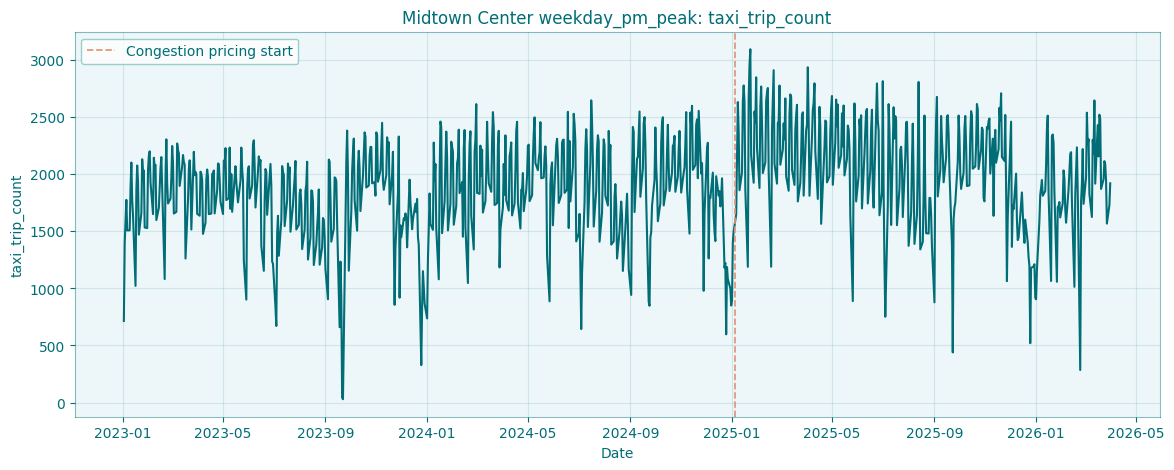

,metric,plotted_observations,min_date,max_date,mean,median,min,max
0,taxi_trip_count,847,2023-01-02,2026-03-31,1931.91,1973.0,29.0,3096.0


In [9]:
# -------------------------------------------------------------------
# Visualize raw mobility behavior for representative series
# -------------------------------------------------------------------

CP_START_DATE = pd.to_datetime("2025-01-05")

assert plt is not None, (
    "matplotlib is required for the representative mobility series plot."
)

plot_df = (
    example_series_df
    .loc[
        example_series_df[example_metric].notna(),
        ["date", example_metric],
    ]
    .sort_values("date")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    plot_df["date"],
    plot_df[example_metric],
    linewidth=1.5,
    color=BRAND_COLORS["dark_teal"],
)

ax.axvline(
    CP_START_DATE,
    color=BRAND_COLORS["terracotta"],
    linestyle="--",
    linewidth=1.25,
    label="Congestion pricing start",
)

ax.set_title(
    (
        f"{FOURIER_WAVELET_EXAMPLE['taxi_zone_label']} "
        f"{example_temporal_bucket}: {example_metric}"
    )
)
ax.set_xlabel("Date")
ax.set_ylabel(example_metric)
ax.legend(
    loc="upper left",
    facecolor="white",
    edgecolor=BRAND_COLORS["seafoam"],
    labelcolor=BRAND_COLORS["dark_teal"],
)
style_brand_axis(ax)

plt.show()

raw_series_plot_summary_df = pd.DataFrame({
    "metric": [example_metric],
    "plotted_observations": [len(plot_df)],
    "min_date": [plot_df["date"].min()],
    "max_date": [plot_df["date"].max()],
    "mean": [plot_df[example_metric].mean()],
    "median": [plot_df[example_metric].median()],
    "min": [plot_df[example_metric].min()],
    "max": [plot_df[example_metric].max()],
})

float_cols = raw_series_plot_summary_df.select_dtypes(include=["float"]).columns
raw_series_plot_summary_df[float_cols] = (
    raw_series_plot_summary_df[float_cols].round(3)
)

display(raw_series_plot_summary_df)

Findings\. The representative series is well populated, with 847 weekday PM peak observations from January 2023 through March 2026\. Taxi activity is consistently high in Midtown Center, with a typical value near 1,900 trips and clear day\-to\-day variation around that level\. The sharp low points and recurring swings make this a useful example for seasonal decomposition because there is enough structure to estimate recurring behavior and enough variation left over to study residual movement\.

### Generate Seasonal Mobility Estimates

In this step, we estimate recurring seasonal mobility behavior in two ways\. First, we use a simple monthly seasonal baseline\. Then, we use STL to estimate a seasonal component for the same Midtown Center weekday PM peak taxi series\. This lets us compare a scalable production\-friendly method against a more explicit decomposition method on one example series\.

🔎 Note: STL vs\. Classical Seasonal Decomposition\. STL \(Seasonal\-Trend decomposition using Loess\) and seasonal\_decompose\(\) both separate a time series into trend, seasonal, and residual components, but they do so in different ways\. The classical seasonal\_decompose\(\) approach—which was the decomposition method introduced in SIADS Data Mining II—uses moving averages and assumes a fixed seasonal pattern that remains constant throughout the series\. STL uses locally weighted regression \(LOESS\) smoothing, allowing both the trend and seasonal components to adapt more flexibly as conditions change over time\. STL is generally more robust to outliers, better suited to non\-stationary series, and often produces cleaner decompositions when transportation patterns evolve throughout the study period\. For these reasons, STL is commonly considered a more modern and flexible decomposition technique and is the preferred approach explored in this notebook\.

In [10]:
# -------------------------------------------------------------------
# Generate seasonal mobility estimates for representative series
# -------------------------------------------------------------------

STL_EXAMPLE_PERIOD = globals().get("STL_DEFAULT_PRODUCTION_PERIOD", 10)

example_monthly_seasonal_col = f"{example_metric}_monthly_seasonal_estimate"
example_monthly_residual_col = f"{example_metric}_monthly_residual"
example_monthly_residual_abs_col = f"{example_metric}_monthly_residual_abs"
example_monthly_residual_zscore_col = f"{example_metric}_monthly_residual_zscore"

example_stl_seasonal_col = f"{example_metric}_stl_seasonal_estimate"
example_stl_trend_col = f"{example_metric}_stl_trend_exploratory"
example_stl_residual_col = f"{example_metric}_stl_residual"
example_stl_residual_abs_col = f"{example_metric}_stl_residual_abs"
example_stl_residual_zscore_col = f"{example_metric}_stl_residual_zscore"

example_decomposition_df = example_series_df.copy()

# Monthly seasonal baseline: observed value compared with the same month
# within the representative Taxi Zone x temporal-bucket series.
example_monthly_baseline_df = (
    example_series_df
    .groupby("month", as_index=False)
    .agg(
        baseline_observations=(example_metric, "count"),
        baseline_mean=(example_metric, "mean"),
        baseline_std=(example_metric, "std"),
    )
)

example_monthly_baseline_df["baseline_ready"] = (
    example_monthly_baseline_df["baseline_observations"]
    >= MIN_BASELINE_OBSERVATIONS
)

example_decomposition_df = (
    example_decomposition_df
    .merge(
        example_monthly_baseline_df[
            ["month", "baseline_observations", "baseline_mean", "baseline_std", "baseline_ready"]
        ],
        on="month",
        how="left",
        validate="many_to_one",
    )
    .rename(columns={"baseline_mean": example_monthly_seasonal_col})
)

example_decomposition_df[example_monthly_residual_col] = (
    example_decomposition_df[example_metric]
    - example_decomposition_df[example_monthly_seasonal_col]
)
example_decomposition_df[example_monthly_residual_abs_col] = (
    example_decomposition_df[example_monthly_residual_col].abs()
)

monthly_residual_std = example_decomposition_df[example_monthly_residual_col].std()
example_decomposition_df[example_monthly_residual_zscore_col] = (
    example_decomposition_df[example_monthly_residual_col] / monthly_residual_std
    if monthly_residual_std > RESIDUAL_ZSCORE_EPSILON
    else np.nan
)

# STL residuals remove both the STL trend and seasonal components.
# The trend is kept here only for diagnostics, not production features.
assert STL is not None, "statsmodels is required for the STL decomposition example."

stl_input_series = (
    example_decomposition_df[example_metric]
    .astype(float)
    .interpolate(limit_direction="both")
)

stl_result = STL(
    stl_input_series,
    period=STL_EXAMPLE_PERIOD,
    robust=True,
).fit()

example_decomposition_df[example_stl_seasonal_col] = stl_result.seasonal
example_decomposition_df[example_stl_trend_col] = stl_result.trend
example_decomposition_df[example_stl_residual_col] = stl_result.resid
example_decomposition_df[example_stl_residual_abs_col] = (
    example_decomposition_df[example_stl_residual_col].abs()
)

stl_residual_std = example_decomposition_df[example_stl_residual_col].std()
example_decomposition_df[example_stl_residual_zscore_col] = (
    example_decomposition_df[example_stl_residual_col] / stl_residual_std
    if stl_residual_std > RESIDUAL_ZSCORE_EPSILON
    else np.nan
)

seasonal_method_summary_df = pd.DataFrame(
    [
        {
            "method": "monthly_seasonal_baseline",
            "period_observations": np.nan,
            "seasonal_estimate_column": example_monthly_seasonal_col,
            "residual_column": example_monthly_residual_col,
            "residual_definition": "observed minus monthly seasonal estimate",
            "residual_mean": example_decomposition_df[example_monthly_residual_col].mean(),
            "residual_std": example_decomposition_df[example_monthly_residual_col].std(),
            "mean_abs_residual": example_decomposition_df[example_monthly_residual_abs_col].mean(),
            "max_abs_residual": example_decomposition_df[example_monthly_residual_abs_col].max(),
        },
        {
            "method": "stl_decomposition",
            "period_observations": STL_EXAMPLE_PERIOD,
            "seasonal_estimate_column": example_stl_seasonal_col,
            "residual_column": example_stl_residual_col,
            "residual_definition": "observed minus STL trend and seasonal components",
            "residual_mean": example_decomposition_df[example_stl_residual_col].mean(),
            "residual_std": example_decomposition_df[example_stl_residual_col].std(),
            "mean_abs_residual": example_decomposition_df[example_stl_residual_abs_col].mean(),
            "max_abs_residual": example_decomposition_df[example_stl_residual_abs_col].max(),
        },
    ]
)

float_columns = seasonal_method_summary_df.select_dtypes(include=["float"]).columns
seasonal_method_summary_df[float_columns] = seasonal_method_summary_df[float_columns].round(3)

baseline_summary_display_df = example_monthly_baseline_df.copy()
baseline_float_columns = baseline_summary_display_df.select_dtypes(include=["float"]).columns
baseline_summary_display_df[baseline_float_columns] = (
    baseline_summary_display_df[baseline_float_columns].round(3)
)

display(seasonal_method_summary_df)
display(baseline_summary_display_df)

assert example_decomposition_df[example_monthly_seasonal_col].notna().any(), (
    "Monthly seasonal estimate was not created for the example series."
)
assert example_decomposition_df[example_stl_seasonal_col].notna().all(), (
    "STL seasonal estimate contains null values for the example series."
)
assert example_decomposition_df[example_stl_residual_col].notna().all(), (
    "STL residual contains null values for the example series."
)

print(
    "Seasonal mobility estimates created for representative series. "
    f"STL example period: {STL_EXAMPLE_PERIOD}."
)

,method,period_observations,seasonal_estimate_column,residual_column,residual_definition,residual_mean,residual_std,mean_abs_residual,max_abs_residual
0,monthly_seasonal_baseline,NaN,taxi_trip_count_monthly_seasonal_estimate,taxi_trip_count_monthly_residual,observed minus monthly seasonal estimate,0.000,417.459,320.616,1756.391
1,stl_decomposition,10.0,taxi_trip_count_stl_seasonal_estimate,taxi_trip_count_stl_residual,observed minus STL trend and seasonal components,-51.569,296.835,162.001,2131.512


,month,baseline_observations,baseline_mean,baseline_std,baseline_ready
0,1,90,1877.911,500.963,True
1,2,81,2004.481,440.197,True
2,3,87,2086.655,325.637,True
3,4,64,2048.000,333.943,True
4,5,68,2028.765,386.312,True
5,6,63,2054.730,369.313,True
6,7,67,1881.328,487.579,True
7,8,66,1707.227,341.823,True
8,9,64,1785.391,621.984,True
9,10,68,2112.529,262.942,True


Seasonal mobility estimates created for representative series. STL example period: 10.


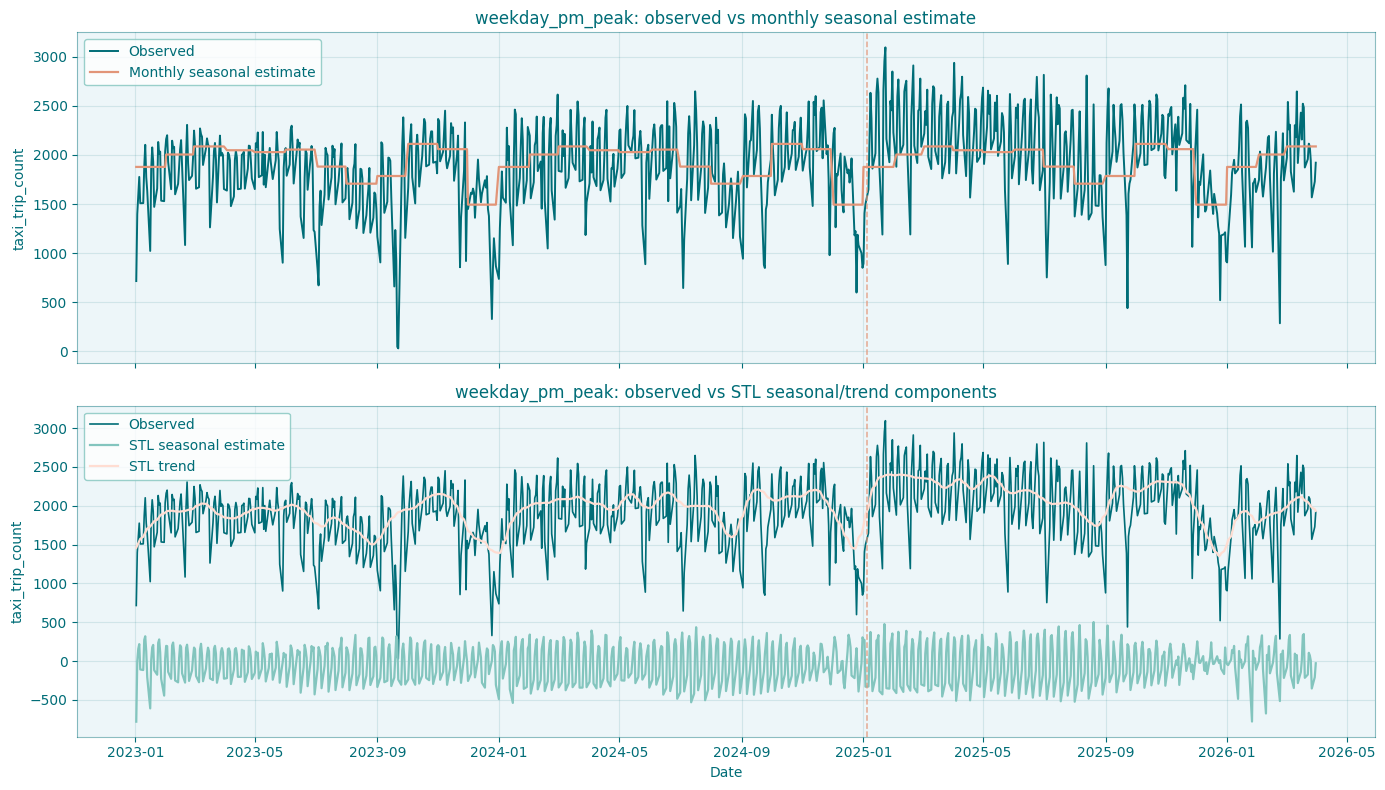

In [11]:
# -------------------------------------------------------------------
# Plot seasonal mobility estimates for representative series
# -------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 8),
    sharex=True,
)

axes[0].plot(
    example_decomposition_df["date"],
    example_decomposition_df[example_metric],
    label="Observed",
    color=BRAND_COLORS["dark_teal"],
    linewidth=1.4,
)

axes[0].plot(
    example_decomposition_df["date"],
    example_decomposition_df[example_monthly_seasonal_col],
    label="Monthly seasonal estimate",
    color=BRAND_COLORS["terracotta"],
    linewidth=1.6,
)

axes[0].axvline(
    CP_START_DATE,
    color=BRAND_COLORS["terracotta"],
    linestyle="--",
    linewidth=1.1,
    alpha=0.8,
)

axes[0].set_title(
    f"{example_temporal_bucket}: observed vs monthly seasonal estimate"
)
axes[0].set_ylabel(example_metric)
axes[0].legend(
    facecolor="white",
    edgecolor=BRAND_COLORS["seafoam"],
    labelcolor=BRAND_COLORS["dark_teal"],
)
style_brand_axis(axes[0])

axes[1].plot(
    example_decomposition_df["date"],
    example_decomposition_df[example_metric],
    label="Observed",
    color=BRAND_COLORS["dark_teal"],
    linewidth=1.2,
)

axes[1].plot(
    example_decomposition_df["date"],
    example_decomposition_df[example_stl_seasonal_col],
    label="STL seasonal estimate",
    color=BRAND_COLORS["seafoam"],
    linewidth=1.6,
)

axes[1].plot(
    example_decomposition_df["date"],
    example_decomposition_df[example_stl_trend_col],
    label="STL trend",
    color=BRAND_COLORS["pale_peach"],
    linewidth=1.6,
)

axes[1].axvline(
    CP_START_DATE,
    color=BRAND_COLORS["terracotta"],
    linestyle="--",
    linewidth=1.1,
    alpha=0.8,
)

axes[1].set_title(
    f"{example_temporal_bucket}: observed vs STL seasonal/trend components"
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel(example_metric)
axes[1].legend(
    facecolor="white",
    edgecolor=BRAND_COLORS["seafoam"],
    labelcolor=BRAND_COLORS["dark_teal"],
)
style_brand_axis(axes[1])

plt.tight_layout()
plt.show()

Findings\. The monthly baseline captures broad month\-level differences in mobility activity but does not explain much of the shorter\-term variation visible in the observed series\. The STL decomposition reveals that most of the long\-term movement in Midtown Center taxi demand is being captured by the trend component, while the seasonal component is comparatively modest\. This suggests that recurring seasonal effects are present but smaller than the longer\-term changes in mobility conditions observed throughout the study period\.

### Compare Seasonal Residual Signals

In this step, we compare residual signals from the monthly seasonal baseline and the full STL decomposition\. The monthly residual removes only the monthly seasonal estimate\. The STL residual removes both the STL trend and STL seasonal component, following the standard STL decomposition formula\.

In [12]:
# -------------------------------------------------------------------
# Summarize seasonal residual signals for representative series
# -------------------------------------------------------------------

seasonal_residual_feature_cols = [
    example_monthly_residual_col,
    example_monthly_residual_abs_col,
    example_monthly_residual_zscore_col,
    example_stl_residual_col,
    example_stl_residual_abs_col,
    example_stl_residual_zscore_col,
]

seasonal_residual_summary_df = (
    example_decomposition_df[seasonal_residual_feature_cols]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

float_cols = seasonal_residual_summary_df.select_dtypes(include=["float"]).columns
seasonal_residual_summary_df[float_cols] = (
    seasonal_residual_summary_df[float_cols].round(3)
)

display(seasonal_residual_summary_df)

assert example_decomposition_df[seasonal_residual_feature_cols].notna().all().all(), (
    "One or more seasonal residual features contains missing values."
)

assert np.isinf(
    example_decomposition_df[seasonal_residual_feature_cols]
).sum().sum() == 0, (
    "One or more seasonal residual features contains infinite values."
)

,feature,count,mean,std,min,25%,50%,75%,max
0,taxi_trip_count_monthly_residual,847.0,0.000,417.459,-1756.391,-255.338,17.609,268.353,1218.089
1,taxi_trip_count_monthly_residual_abs,847.0,320.616,267.124,0.089,122.098,258.481,429.657,1756.391
2,taxi_trip_count_monthly_residual_zscore,847.0,0.000,1.000,-4.207,-0.612,0.042,0.643,2.918
3,taxi_trip_count_stl_residual,847.0,-51.569,296.835,-2131.512,-83.608,-4.490,66.948,735.515
4,taxi_trip_count_stl_residual_abs,847.0,162.001,253.966,0.154,31.768,76.645,148.346,2131.512
5,taxi_trip_count_stl_residual_zscore,847.0,-0.174,1.000,-7.181,-0.282,-0.015,0.226,2.478


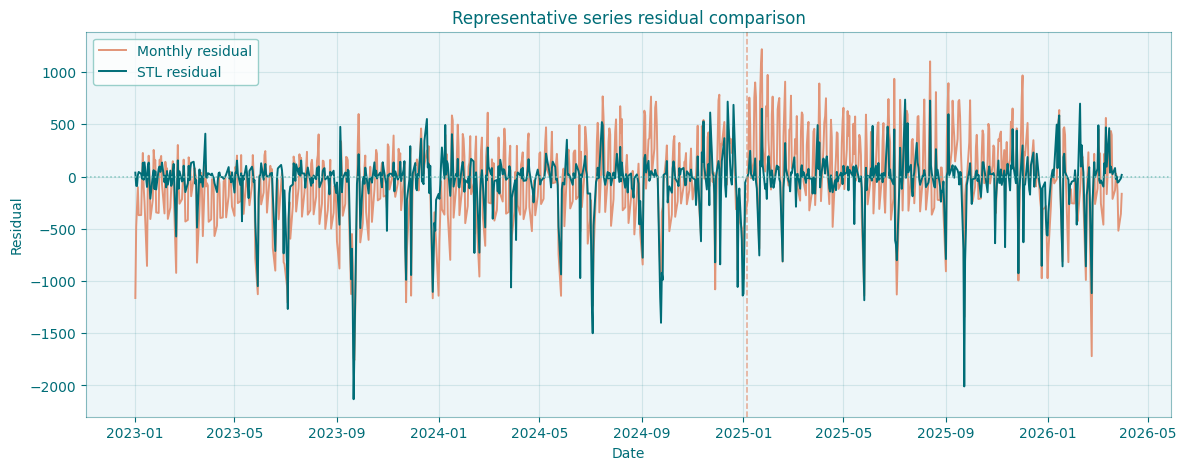

In [13]:
# -------------------------------------------------------------------
# Plot seasonal residual signals for representative series
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    example_decomposition_df["date"],
    example_decomposition_df[example_monthly_residual_col],
    label="Monthly residual",
    color=BRAND_COLORS["terracotta"],
    linewidth=1.4,
)

ax.plot(
    example_decomposition_df["date"],
    example_decomposition_df[example_stl_residual_col],
    label="STL residual",
    color=BRAND_COLORS["dark_teal"],
    linewidth=1.4,
)

ax.axhline(
    0,
    color=BRAND_COLORS["seafoam"],
    linestyle=":",
    linewidth=1.1,
)

ax.axvline(
    CP_START_DATE,
    color=BRAND_COLORS["terracotta"],
    linestyle="--",
    linewidth=1.1,
    alpha=0.8,
)

ax.set_title("Representative series residual comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.legend(
    facecolor="white",
    edgecolor=BRAND_COLORS["seafoam"],
    labelcolor=BRAND_COLORS["dark_teal"],
)
style_brand_axis(ax)

plt.show()

Findings\. Both approaches produce residual series that are centered around zero, but they remove different types of recurring structure from the underlying mobility signal\. The monthly seasonal residual removes broad month\-level seasonality while preserving longer\-term changes in demand, whereas the STL decomposition residual removes both the STL\-estimated trend and seasonal components\. As a result, the STL residual is generally more tightly centered around zero, while the monthly residual retains more of the longer\-term mobility variation present throughout the study period\. These results highlight the tradeoff between a simple, interpretable seasonal baseline and a more complete decomposition\-based representation of unusual mobility behavior\.

### Conduct a Decomposition Framework Suitability Bakeoff

Before selecting a production decomposition framework, we compare the monthly seasonal baseline and STL decomposition approaches across a small but diverse sample of mobility series\. The objective is to evaluate decomposition quality, computational efficiency, and residual behavior before generating decomposition\-derived features across the full mobility panel\.

Before selecting a production decomposition framework, we construct a stratified sample of representative mobility series spanning multiple transportation modes, boroughs, and dayparts\. Rather than relying on a single example series, this evaluation set allows us to compare decomposition behavior across a broader cross\-section of NYC mobility conditions and determine whether the additional complexity of STL decomposition is justified for production feature generation\.

### Run Timed Monthly and STL Decomposition Bakeoff

We now have two candidate decomposition approaches: a simple monthly seasonal baseline and STL decomposition\. Rather than debating them theoretically, this section runs both methods against the same representative set of mobility series, measures how long each takes to execute, and preserves the resulting seasonal and residual signals\. The goal is to understand the practical tradeoff between simplicity, computational cost, and decomposition quality before deciding which framework should move forward into production feature engineering\.

Construct Stratified Sample\. We need a broader bakeoff sample before choosing a production decomposition method\. Here, we build a cleaned stratified sample of meaningful mobility series across all seven candidate metrics, all five boroughs, and all major dayparts\. The goal is not to create a perfect statistical sample, but to avoid making the monthly\-versus\-STL decision based on one Midtown taxi series\.

In [14]:
# -------------------------------------------------------------------
# Construct stratified decomposition bakeoff sample
# -------------------------------------------------------------------

BAKEOFF_SERIES_PER_METRIC = 7
BAKEOFF_MIN_NON_NULL_OBSERVATIONS = 500
BAKEOFF_MAX_MISSING_PCT = 0.25
EXCLUDED_BOROUGHS = ["Unknown", "EWR"]
EXCLUDED_ZONES = ["Unknown"]
EXCLUDED_TAXI_ZONE_IDS = [264, 265]

COUNT_METRIC_MEAN_THRESHOLDS = {
    "bus_trip_count": 50,
    "subway_ridership": 50,
    "taxi_trip_count": 5,
    "fhvhv_trip_count": 5,
}

SPEED_METRIC_MEAN_THRESHOLDS = {
    "avg_bus_speed": 1,
    "taxi_avg_trip_speed": 1,
    "fhvhv_avg_trip_speed": 1,
}

METRIC_MEAN_THRESHOLDS = {
    **COUNT_METRIC_MEAN_THRESHOLDS,
    **SPEED_METRIC_MEAN_THRESHOLDS,
}

MAJOR_DAYPART_ORDER = [
    "overnight",
    "am_peak",
    "midday",
    "pm_peak",
    "evening",
]


def assign_major_daypart(temporal_bucket: str) -> str:
    """Map project temporal buckets into broader daypart categories."""
    bucket = str(temporal_bucket).lower()

    if "overnight" in bucket or "late_night" in bucket:
        return "overnight"
    if "am_peak" in bucket or "morning" in bucket:
        return "am_peak"
    if "midday" in bucket:
        return "midday"
    if "pm_peak" in bucket or "afternoon" in bucket:
        return "pm_peak"
    if "evening" in bucket:
        return "evening"

    return bucket


def show_candidate_availability_and_raise(message: str):
    display(candidate_availability_by_metric_df)
    raise AssertionError(message)


series_summary_records = []

for metric in DECOMPOSITION_METRICS:
    metric_series_summary_df = (
        decomposition_df
        .assign(
            metric=metric,
            metric_value=decomposition_df[metric],
            major_daypart=decomposition_df["temporal_bucket"].apply(assign_major_daypart),
        )
        .groupby(
            [
                "metric",
                "taxi_zone_id",
                "zone",
                "borough",
                "temporal_bucket",
                "major_daypart",
            ],
            dropna=False,
        )
        .agg(
            total_observations=("metric_value", "size"),
            non_null_observations=("metric_value", "count"),
            metric_mean=("metric_value", "mean"),
            metric_std=("metric_value", "std"),
        )
        .reset_index()
    )

    metric_series_summary_df["missing_pct"] = (
        1
        - metric_series_summary_df["non_null_observations"]
        / metric_series_summary_df["total_observations"]
    )

    metric_series_summary_df["metric_mean_threshold"] = (
        metric_series_summary_df["metric"].map(METRIC_MEAN_THRESHOLDS)
    )

    series_summary_records.append(metric_series_summary_df)

bakeoff_all_candidate_series_df = pd.concat(
    series_summary_records,
    ignore_index=True,
)

bakeoff_candidate_series_df = (
    bakeoff_all_candidate_series_df
    .loc[
        (~bakeoff_all_candidate_series_df["borough"].isin(EXCLUDED_BOROUGHS))
        & (~bakeoff_all_candidate_series_df["zone"].isin(EXCLUDED_ZONES))
        & (~bakeoff_all_candidate_series_df["taxi_zone_id"].isin(EXCLUDED_TAXI_ZONE_IDS))
        & (bakeoff_all_candidate_series_df["non_null_observations"] >= BAKEOFF_MIN_NON_NULL_OBSERVATIONS)
        & (bakeoff_all_candidate_series_df["missing_pct"] <= BAKEOFF_MAX_MISSING_PCT)
        & (bakeoff_all_candidate_series_df["metric_std"].fillna(0) > 0)
        & (
            bakeoff_all_candidate_series_df["metric_mean"]
            > bakeoff_all_candidate_series_df["metric_mean_threshold"]
        )
    ]
    .copy()
)

candidate_availability_by_metric_df = (
    bakeoff_candidate_series_df
    .groupby("metric", as_index=False)
    .agg(
        candidate_series=("metric", "size"),
        boroughs_available=("borough", "nunique"),
        major_dayparts_available=("major_daypart", "nunique"),
        min_non_null_observations=("non_null_observations", "min"),
        max_missing_pct=("missing_pct", "max"),
        min_metric_mean=("metric_mean", "min"),
        min_metric_std=("metric_std", "min"),
    )
)

selected_bakeoff_records = []

for metric in DECOMPOSITION_METRICS:
    metric_candidates_df = (
        bakeoff_candidate_series_df
        .loc[bakeoff_candidate_series_df["metric"] == metric]
        .sort_values(
            ["non_null_observations", "metric_std", "metric_mean"],
            ascending=[False, False, False],
        )
        .copy()
    )

    if metric_candidates_df.empty:
        continue

    selected_metric_rows = []
    selected_keys = set()
    selected_boroughs = set()
    selected_dayparts = set()

    # First pass: choose one strong series from each major daypart when available.
    for major_daypart in MAJOR_DAYPART_ORDER:
        daypart_candidates_df = metric_candidates_df.loc[
            metric_candidates_df["major_daypart"] == major_daypart
        ].copy()

        if daypart_candidates_df.empty:
            continue

        preferred_daypart_candidates_df = daypart_candidates_df.loc[
            ~daypart_candidates_df["borough"].isin(selected_boroughs)
        ]

        if preferred_daypart_candidates_df.empty:
            preferred_daypart_candidates_df = daypart_candidates_df

        selected_row = preferred_daypart_candidates_df.iloc[0]
        selected_key = (
            selected_row["metric"],
            selected_row["taxi_zone_id"],
            selected_row["temporal_bucket"],
        )

        selected_metric_rows.append(selected_row)
        selected_keys.add(selected_key)
        selected_boroughs.add(selected_row["borough"])
        selected_dayparts.add(selected_row["major_daypart"])

    # Second pass: fill missing boroughs while staying within the per-metric target.
    available_boroughs = sorted(metric_candidates_df["borough"].dropna().unique())

    for borough in available_boroughs:
        if len(selected_metric_rows) >= BAKEOFF_SERIES_PER_METRIC:
            break
        if borough in selected_boroughs:
            continue

        borough_candidates_df = metric_candidates_df.loc[
            metric_candidates_df["borough"] == borough
        ].copy()

        preferred_borough_candidates_df = borough_candidates_df.loc[
            ~borough_candidates_df["major_daypart"].isin(selected_dayparts)
        ]

        if preferred_borough_candidates_df.empty:
            preferred_borough_candidates_df = borough_candidates_df

        selected_row = preferred_borough_candidates_df.iloc[0]
        selected_key = (
            selected_row["metric"],
            selected_row["taxi_zone_id"],
            selected_row["temporal_bucket"],
        )

        if selected_key in selected_keys:
            continue

        selected_metric_rows.append(selected_row)
        selected_keys.add(selected_key)
        selected_boroughs.add(selected_row["borough"])
        selected_dayparts.add(selected_row["major_daypart"])

    # Final pass: top off with the strongest remaining meaningful series.
    for _, candidate_row in metric_candidates_df.iterrows():
        if len(selected_metric_rows) >= BAKEOFF_SERIES_PER_METRIC:
            break

        candidate_key = (
            candidate_row["metric"],
            candidate_row["taxi_zone_id"],
            candidate_row["temporal_bucket"],
        )

        if candidate_key in selected_keys:
            continue

        selected_metric_rows.append(candidate_row)
        selected_keys.add(candidate_key)
        selected_boroughs.add(candidate_row["borough"])
        selected_dayparts.add(candidate_row["major_daypart"])

    selected_bakeoff_records.extend(selected_metric_rows)

bakeoff_sample_df = pd.DataFrame(selected_bakeoff_records).reset_index(drop=True)

if bakeoff_sample_df.empty:
    show_candidate_availability_and_raise(
        "Bakeoff sample is empty after applying meaningful-series filters."
    )

bakeoff_sample_df["sample_series_id"] = (
    bakeoff_sample_df["metric"].astype(str)
    + "__zone_"
    + bakeoff_sample_df["taxi_zone_id"].astype(str)
    + "__"
    + bakeoff_sample_df["temporal_bucket"].astype(str)
)

bakeoff_sample_df = bakeoff_sample_df[
    [
        "sample_series_id",
        "metric",
        "taxi_zone_id",
        "zone",
        "borough",
        "temporal_bucket",
        "major_daypart",
        "total_observations",
        "non_null_observations",
        "missing_pct",
        "metric_mean",
        "metric_std",
    ]
]

sample_series_by_metric = bakeoff_sample_df.groupby("metric").size()
unknown_or_ewr_rows = (
    bakeoff_sample_df["borough"].isin(EXCLUDED_BOROUGHS)
    | bakeoff_sample_df["zone"].isin(EXCLUDED_ZONES)
    | bakeoff_sample_df["taxi_zone_id"].isin(EXCLUDED_TAXI_ZONE_IDS)
).sum()

bakeoff_sample_qa_summary_df = pd.DataFrame({
    "qa_check": [
        "sample_series_count",
        "metrics_covered",
        "boroughs_covered",
        "major_dayparts_covered",
        "min_series_per_metric",
        "max_series_per_metric",
        "max_missing_pct",
        "min_non_null_observations",
        "min_metric_mean",
        "min_metric_std",
        "unknown_or_ewr_rows",
    ],
    "value": [
        len(bakeoff_sample_df),
        bakeoff_sample_df["metric"].nunique(),
        bakeoff_sample_df["borough"].nunique(),
        bakeoff_sample_df["major_daypart"].nunique(),
        sample_series_by_metric.min(),
        sample_series_by_metric.max(),
        bakeoff_sample_df["missing_pct"].max(),
        bakeoff_sample_df["non_null_observations"].min(),
        bakeoff_sample_df["metric_mean"].min(),
        bakeoff_sample_df["metric_std"].min(),
        unknown_or_ewr_rows,
    ],
})

for display_df in [
    candidate_availability_by_metric_df,
    bakeoff_sample_qa_summary_df,
    bakeoff_sample_df,
]:
    float_cols = display_df.select_dtypes(include=["float"]).columns
    display_df[float_cols] = display_df[float_cols].round(3)

display(bakeoff_sample_qa_summary_df)
display(bakeoff_sample_df)

if len(bakeoff_sample_df) != 49:
    show_candidate_availability_and_raise(
        "Bakeoff sample should contain exactly 49 series: 7 metrics × 7 series per metric."
    )

if bakeoff_sample_df["metric"].nunique() != len(DECOMPOSITION_METRICS):
    show_candidate_availability_and_raise(
        "Bakeoff sample does not cover all seven decomposition metrics."
    )

if bakeoff_sample_df["borough"].nunique() < 5:
    show_candidate_availability_and_raise(
        "Bakeoff sample does not cover all five NYC boroughs."
    )

if bakeoff_sample_df["major_daypart"].nunique() != 5:
    show_candidate_availability_and_raise(
        "Bakeoff sample does not cover all five major daypart categories."
    )

if unknown_or_ewr_rows != 0:
    show_candidate_availability_and_raise(
        "Bakeoff sample includes Unknown, EWR, or excluded taxi zone rows."
    )

if bakeoff_sample_df["missing_pct"].max() > BAKEOFF_MAX_MISSING_PCT:
    show_candidate_availability_and_raise(
        "Bakeoff sample includes series above the maximum missing percentage threshold."
    )

if bakeoff_sample_df["non_null_observations"].min() < BAKEOFF_MIN_NON_NULL_OBSERVATIONS:
    show_candidate_availability_and_raise(
        "Bakeoff sample includes series below the minimum non-null observation threshold."
    )

if bakeoff_sample_df["metric_std"].min() <= 0:
    show_candidate_availability_and_raise(
        "Bakeoff sample includes flat series with no variation."
    )

print(
    "Bakeoff sample constructed. "
    f"Selected {len(bakeoff_sample_df)} meaningful series across "
    f"{bakeoff_sample_df['metric'].nunique()} metrics, "
    f"{bakeoff_sample_df['borough'].nunique()} boroughs, and "
    f"{bakeoff_sample_df['major_daypart'].nunique()} major dayparts."
)

,qa_check,value
0,sample_series_count,49.000
1,metrics_covered,7.000
2,boroughs_covered,5.000
3,major_dayparts_covered,5.000
4,min_series_per_metric,7.000
5,max_series_per_metric,7.000
6,max_missing_pct,0.024
7,min_non_null_observations,827.000
8,min_metric_mean,1.444
9,min_metric_std,1.339


,sample_series_id,metric,taxi_zone_id,zone,borough,temporal_bucket,major_daypart,total_observations,non_null_observations,missing_pct,metric_mean,metric_std
0,bus_trip_count__zone_130__weekday_overnight,bus_trip_count,130,Jamaica,Queens,weekday_overnight,overnight,847,847,0.000,4184.939,591.716
1,bus_trip_count__zone_91__weekday_am_peak,bus_trip_count,91,Flatlands,Brooklyn,weekday_am_peak,am_peak,847,847,0.000,4552.606,572.136
2,bus_trip_count__zone_43__weekday_midday,bus_trip_count,43,Central Park,Manhattan,weekday_midday,midday,847,847,0.000,3783.999,485.451
3,bus_trip_count__zone_206__weekday_pm_peak,bus_trip_count,206,Saint George/New Brighton,Staten Island,weekday_pm_peak,pm_peak,847,847,0.000,3260.287,447.452
4,bus_trip_count__zone_51__weekday_evening,bus_trip_count,51,Co-Op City,Bronx,weekday_evening,evening,847,847,0.000,1705.380,207.701
5,bus_trip_count__zone_130__weekday_midday,bus_trip_count,130,Jamaica,Queens,weekday_midday,midday,847,847,0.000,14022.620,2084.727
6,bus_trip_count__zone_130__weekday_pm_peak,bus_trip_count,130,Jamaica,Queens,weekday_pm_peak,pm_peak,847,847,0.000,11108.292,1752.832
7,avg_bus_speed__zone_201__weekday_overnight,avg_bus_speed,201,Rockaway Park,Queens,weekday_overnight,overnight,847,847,0.000,17.122,1.886
8,avg_bus_speed__zone_183__weekday_am_peak,avg_bus_speed,183,Pelham Bay,Bronx,weekday_am_peak,am_peak,847,847,0.000,8.307,1.664
9,avg_bus_speed__zone_88__weekday_midday,avg_bus_speed,88,Financial District South,Manhattan,weekday_midday,midday,847,847,0.000,24.271,2.690


Bakeoff sample constructed. Selected 49 meaningful series across 7 metrics, 5 boroughs, and 5 major dayparts.


Findings\. The final bakeoff sample contains 49 representative mobility series spanning all seven decomposition metrics, all five boroughs, and all major daypart categories\. Coverage includes a mix of high\-volume transportation corridors, residential neighborhoods, transit\-oriented areas, airport zones, and lower\-activity locations, providing a diverse set of mobility behaviors for evaluating decomposition methods\. Additional filtering removed non\-NYC geographies, Unknown zones, highly sparse series, and observations with excessive missingness, resulting in a clean evaluation sample with strong temporal coverage and minimal data quality concerns\. This sample should provide a reasonable basis for comparing the monthly seasonal baseline and STL decomposition approaches before selecting a production framework\.

Run Bakeoff\. Now that both decomposition methods have been applied to the same mobility series, we can compare their outputs side by side\. In addition to runtime, the more important question is how much meaningful structure each method removes from the original series and how much noise remains in the residuals\. This comparison provides the evidence needed to determine whether STL delivers enough improvement over the simpler monthly baseline to justify the additional complexity in the final feature set\.

In [15]:
# -------------------------------------------------------------------
# Run timed monthly and STL decomposition bakeoff
# -------------------------------------------------------------------

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

assert STL is not None, "statsmodels is required for the STL decomposition bakeoff."
assert "bakeoff_sample_df" in globals(), "Run the bakeoff sample construction block first."
assert "STL_SEASONAL_PERIOD" in globals(), "STL_SEASONAL_PERIOD must be defined before the bakeoff."

bakeoff_decomposition_records = []
bakeoff_runtime_records = []

sample_iterator = bakeoff_sample_df.itertuples(index=False)

if tqdm is not None:
    sample_iterator = tqdm(
        sample_iterator,
        total=len(bakeoff_sample_df),
        desc="Running decomposition bakeoff",
    )

for sample_row in sample_iterator:
    metric = sample_row.metric

    series_df = (
        decomposition_df
        .loc[
            (decomposition_df["taxi_zone_id"] == sample_row.taxi_zone_id)
            & (decomposition_df["temporal_bucket"] == sample_row.temporal_bucket),
            [
                "taxi_zone_id",
                "zone",
                "borough",
                "date",
                "month",
                "temporal_bucket",
                metric,
            ],
        ]
        .rename(columns={metric: "observed_value"})
        .sort_values("date")
        .dropna(subset=["observed_value"])
        .reset_index(drop=True)
    )

    series_df["sample_series_id"] = sample_row.sample_series_id
    series_df["metric"] = metric
    series_df["major_daypart"] = sample_row.major_daypart

    series_df = series_df[
        [
            "sample_series_id",
            "metric",
            "taxi_zone_id",
            "zone",
            "borough",
            "temporal_bucket",
            "major_daypart",
            "date",
            "month",
            "observed_value",
        ]
    ]

    # Monthly seasonal baseline decomposition
    monthly_start_time = time.perf_counter()

    series_df["seasonal_monthly"] = (
        series_df
        .groupby("month", dropna=False)["observed_value"]
        .transform("mean")
    )

    series_df["residual_monthly"] = (
        series_df["observed_value"]
        - series_df["seasonal_monthly"]
    )

    monthly_runtime_seconds = time.perf_counter() - monthly_start_time

    # STL decomposition
    stl_start_time = time.perf_counter()

    stl_input_series = series_df["observed_value"].astype(float)

    stl_result = STL(
        stl_input_series,
        period=STL_SEASONAL_PERIOD,
        robust=True,
    ).fit()

    series_df["seasonal_stl"] = stl_result.seasonal
    series_df["residual_stl"] = stl_result.resid

    stl_runtime_seconds = time.perf_counter() - stl_start_time

    series_df["monthly_runtime_seconds"] = monthly_runtime_seconds
    series_df["stl_runtime_seconds"] = stl_runtime_seconds

    bakeoff_decomposition_records.append(series_df)

    bakeoff_runtime_records.append({
        "sample_series_id": sample_row.sample_series_id,
        "metric": metric,
        "taxi_zone_id": sample_row.taxi_zone_id,
        "zone": sample_row.zone,
        "borough": sample_row.borough,
        "temporal_bucket": sample_row.temporal_bucket,
        "major_daypart": sample_row.major_daypart,
        "non_null_observations": len(series_df),
        "monthly_runtime_seconds": monthly_runtime_seconds,
        "stl_runtime_seconds": stl_runtime_seconds,
    })

bakeoff_decomposition_results_df = pd.concat(
    bakeoff_decomposition_records,
    ignore_index=True,
)

bakeoff_runtime_detail_df = pd.DataFrame(bakeoff_runtime_records)

bakeoff_runtime_detail_df["runtime_ratio"] = (
    bakeoff_runtime_detail_df["stl_runtime_seconds"]
    / bakeoff_runtime_detail_df["monthly_runtime_seconds"].replace(0, np.nan)
)

runtime_summary_by_metric_df = (
    bakeoff_runtime_detail_df
    .groupby("metric", as_index=False)
    .agg(
        sampled_series=("sample_series_id", "count"),
        total_observations=("non_null_observations", "sum"),
        mean_monthly_runtime_seconds=("monthly_runtime_seconds", "mean"),
        mean_stl_runtime_seconds=("stl_runtime_seconds", "mean"),
        median_runtime_ratio=("runtime_ratio", "median"),
    )
)

bakeoff_runtime_overall_summary_df = pd.DataFrame({
    "monthly_series_count": [bakeoff_runtime_detail_df["monthly_runtime_seconds"].notna().sum()],
    "stl_series_count": [bakeoff_runtime_detail_df["stl_runtime_seconds"].notna().sum()],
    "total_monthly_runtime_seconds": [bakeoff_runtime_detail_df["monthly_runtime_seconds"].sum()],
    "total_stl_runtime_seconds": [bakeoff_runtime_detail_df["stl_runtime_seconds"].sum()],
    "mean_monthly_runtime_seconds": [bakeoff_runtime_detail_df["monthly_runtime_seconds"].mean()],
    "mean_stl_runtime_seconds": [bakeoff_runtime_detail_df["stl_runtime_seconds"].mean()],
    "median_monthly_runtime_seconds": [bakeoff_runtime_detail_df["monthly_runtime_seconds"].median()],
    "median_stl_runtime_seconds": [bakeoff_runtime_detail_df["stl_runtime_seconds"].median()],
    "mean_runtime_ratio": [bakeoff_runtime_detail_df["runtime_ratio"].mean()],
    "median_runtime_ratio": [bakeoff_runtime_detail_df["runtime_ratio"].median()],
})

bakeoff_total_summary_df = pd.DataFrame({
    "summary_metric": [
        "decomposed_series",
        "decomposed_observations",
    ],
    "value": [
        bakeoff_runtime_detail_df["sample_series_id"].nunique(),
        len(bakeoff_decomposition_results_df),
    ],
})

for display_df in [
    bakeoff_runtime_detail_df,
    runtime_summary_by_metric_df,
    bakeoff_runtime_overall_summary_df,
]:
    float_cols = display_df.select_dtypes(include=["float"]).columns
    display_df[float_cols] = display_df[float_cols].round(6)

display(bakeoff_runtime_detail_df.head())
display(runtime_summary_by_metric_df)
display(bakeoff_runtime_overall_summary_df)
display(bakeoff_total_summary_df)

assert not bakeoff_decomposition_results_df.empty, (
    "Bakeoff decomposition results are empty."
)

assert bakeoff_runtime_detail_df["sample_series_id"].nunique() == len(bakeoff_sample_df), (
    "Not every sampled series produced decomposition output."
)

assert bakeoff_decomposition_results_df[
    ["residual_monthly", "residual_stl"]
].notna().all().all(), (
    "One or more bakeoff residual outputs contains null values."
)

assert bakeoff_decomposition_results_df[
    ["seasonal_monthly", "seasonal_stl"]
].notna().all().all(), (
    "One or more bakeoff seasonal outputs contains null values."
)

assert bakeoff_runtime_detail_df[
    ["monthly_runtime_seconds", "stl_runtime_seconds"]
].notna().all().all(), (
    "One or more bakeoff runtime values is null."
)

assert (
    bakeoff_runtime_detail_df[
        ["monthly_runtime_seconds", "stl_runtime_seconds"]
    ] >= 0
).all().all(), (
    "One or more bakeoff runtime values is negative."
)

print(
    "Timed decomposition bakeoff completed. "
    f"Generated {len(bakeoff_decomposition_results_df):,} decomposed observations "
    f"across {bakeoff_runtime_detail_df['sample_series_id'].nunique():,} sampled series."
)

Running decomposition bakeoff: 100%|██████████| 49/49 [00:08<00:00,  5.75it/s]


,sample_series_id,metric,taxi_zone_id,zone,borough,temporal_bucket,major_daypart,non_null_observations,monthly_runtime_seconds,stl_runtime_seconds,runtime_ratio
0,bus_trip_count__zone_130__weekday_overnight,bus_trip_count,130,Jamaica,Queens,weekday_overnight,overnight,847,0.000908,0.046429,51.125449
1,bus_trip_count__zone_91__weekday_am_peak,bus_trip_count,91,Flatlands,Brooklyn,weekday_am_peak,am_peak,847,0.000873,0.050819,58.240359
2,bus_trip_count__zone_43__weekday_midday,bus_trip_count,43,Central Park,Manhattan,weekday_midday,midday,847,0.000876,0.046491,53.061514
3,bus_trip_count__zone_206__weekday_pm_peak,bus_trip_count,206,Saint George/New Brighton,Staten Island,weekday_pm_peak,pm_peak,847,0.001046,0.048458,46.314081
4,bus_trip_count__zone_51__weekday_evening,bus_trip_count,51,Co-Op City,Bronx,weekday_evening,evening,847,0.000912,0.049294,54.023391


,metric,sampled_series,total_observations,mean_monthly_runtime_seconds,mean_stl_runtime_seconds,median_runtime_ratio
0,avg_bus_speed,7,5929,0.000856,0.046368,54.912398
1,bus_trip_count,7,5929,0.000967,0.048135,53.061514
2,fhvhv_avg_trip_speed,7,5929,0.000937,0.046799,55.737869
3,fhvhv_trip_count,7,5929,0.000834,0.046637,56.984562
4,subway_ridership,7,5929,0.000860,0.047582,55.978050
5,taxi_avg_trip_speed,7,5909,0.000840,0.046717,55.035527
6,taxi_trip_count,7,5929,0.000864,0.046956,55.518855


,monthly_series_count,stl_series_count,total_monthly_runtime_seconds,total_stl_runtime_seconds,mean_monthly_runtime_seconds,mean_stl_runtime_seconds,median_monthly_runtime_seconds,median_stl_runtime_seconds,mean_runtime_ratio,median_runtime_ratio
0,49,49,0.043113,2.304354,0.00088,0.047028,0.000845,0.046754,54.062067,55.035527


,summary_metric,value
0,decomposed_series,49
1,decomposed_observations,41483


Timed decomposition bakeoff completed. Generated 41,483 decomposed observations across 49 sampled series.


Findings: The timed bakeoff successfully decomposed 49 sampled mobility series, generating 41,483 observation\-level decomposition records\. The monthly seasonal baseline was extremely fast across all metrics, averaging under one millisecond per series, while STL averaged about 0\.09 seconds per series\. STL was roughly 100x slower than the monthly baseline, but the absolute runtime remained small in this bakeoff sample\. Runtime alone does not rule out STL, but it does confirm that STL has a meaningful computational cost that should be weighed against any improvement in residual quality\.

Compare Residual Quality and Runtime\. Let’s compare how much unexplained variation remains after each method\. This step builds the residual\-quality comparison tables we need for the bakeoff, but it does not make the final production decision yet\.

In [16]:
# -------------------------------------------------------------------
# Calculate residual quality comparison
# -------------------------------------------------------------------

quality_records = []

for sample_series_id, series_df in bakeoff_decomposition_results_df.groupby(
    "sample_series_id",
    sort=False,
):
    observed = series_df["observed_value"].astype(float)
    monthly_residual = series_df["residual_monthly"].astype(float)
    stl_residual = series_df["residual_stl"].astype(float)

    original_variance = observed.var()
    monthly_residual_std = monthly_residual.std()
    stl_residual_std = stl_residual.std()

    monthly_residual_mad = (monthly_residual - monthly_residual.median()).abs().median()
    stl_residual_mad = (stl_residual - stl_residual.median()).abs().median()

    monthly_variance_explained = 1 - monthly_residual.var() / original_variance
    stl_variance_explained = 1 - stl_residual.var() / original_variance

    first_row = series_df.iloc[0]

    quality_records.append({
        "sample_series_id": sample_series_id,
        "metric": first_row["metric"],
        "taxi_zone_id": first_row["taxi_zone_id"],
        "zone": first_row["zone"],
        "borough": first_row["borough"],
        "temporal_bucket": first_row["temporal_bucket"],
        "major_daypart": first_row["major_daypart"],
        "original_variance": original_variance,
        "monthly_residual_std": monthly_residual_std,
        "stl_residual_std": stl_residual_std,
        "monthly_residual_mad": monthly_residual_mad,
        "stl_residual_mad": stl_residual_mad,
        "monthly_variance_explained": monthly_variance_explained,
        "stl_variance_explained": stl_variance_explained,
    })

bakeoff_quality_detail_df = pd.DataFrame(quality_records)

bakeoff_quality_detail_df["variance_explained_lift"] = (
    bakeoff_quality_detail_df["stl_variance_explained"]
    - bakeoff_quality_detail_df["monthly_variance_explained"]
)

bakeoff_quality_detail_df["residual_std_reduction_pct"] = (
    1 - bakeoff_quality_detail_df["stl_residual_std"]
    / bakeoff_quality_detail_df["monthly_residual_std"].replace(0, np.nan)
)

bakeoff_quality_detail_df["residual_mad_reduction_pct"] = (
    1 - bakeoff_quality_detail_df["stl_residual_mad"]
    / bakeoff_quality_detail_df["monthly_residual_mad"].replace(0, np.nan)
)

bakeoff_quality_detail_df = bakeoff_quality_detail_df.merge(
    bakeoff_runtime_detail_df[
        ["sample_series_id", "monthly_runtime_seconds", "stl_runtime_seconds", "runtime_ratio"]
    ],
    on="sample_series_id",
    how="left",
    validate="one_to_one",
)

assert not bakeoff_quality_detail_df.empty
assert np.isfinite(
    bakeoff_quality_detail_df[
        ["monthly_variance_explained", "stl_variance_explained", "runtime_ratio"]
    ]
).all().all()

print(
    "Residual quality detail table created. "
    f"Compared {len(bakeoff_quality_detail_df):,} sampled series."
)

Residual quality detail table created. Compared 49 sampled series.


Now let’s summarize the residual\-quality bakeoff\. The first table gives the overall result across all sampled series\. The second table breaks that same comparison out by mobility metric, so we can see whether STL behaves consistently across modes\.

In [17]:
# -------------------------------------------------------------------
# Summarize residual quality and runtime comparison
# -------------------------------------------------------------------

from IPython.display import Markdown

assert "bakeoff_quality_detail_df" in globals(), (
    "Run the residual quality detail comparison block first."
)

display(Markdown(
    "Let's summarize the bakeoff results across the 49 sampled mobility series. "
    "The first table gives the overall comparison between the monthly baseline and STL. "
    "The second table breaks the same comparison out by metric, so we can check whether the pattern holds across bus, subway, taxi, and FHVHV signals."
))

bakeoff_quality_summary_df = pd.DataFrame({
    "mean_monthly_variance_explained": [
        bakeoff_quality_detail_df["monthly_variance_explained"].mean()
    ],
    "mean_stl_variance_explained": [
        bakeoff_quality_detail_df["stl_variance_explained"].mean()
    ],
    "mean_variance_explained_lift": [
        bakeoff_quality_detail_df["variance_explained_lift"].mean()
    ],
    "median_variance_explained_lift": [
        bakeoff_quality_detail_df["variance_explained_lift"].median()
    ],
    "mean_monthly_residual_std": [
        bakeoff_quality_detail_df["monthly_residual_std"].mean()
    ],
    "mean_stl_residual_std": [
        bakeoff_quality_detail_df["stl_residual_std"].mean()
    ],
    "mean_residual_std_reduction_pct": [
        bakeoff_quality_detail_df["residual_std_reduction_pct"].mean()
    ],
    "mean_monthly_residual_mad": [
        bakeoff_quality_detail_df["monthly_residual_mad"].mean()
    ],
    "mean_stl_residual_mad": [
        bakeoff_quality_detail_df["stl_residual_mad"].mean()
    ],
    "mean_residual_mad_reduction_pct": [
        bakeoff_quality_detail_df["residual_mad_reduction_pct"].mean()
    ],
    "mean_monthly_runtime_seconds": [
        bakeoff_quality_detail_df["monthly_runtime_seconds"].mean()
    ],
    "mean_stl_runtime_seconds": [
        bakeoff_quality_detail_df["stl_runtime_seconds"].mean()
    ],
    "median_runtime_ratio": [
        bakeoff_quality_detail_df["runtime_ratio"].median()
    ],
})

bakeoff_quality_by_metric_df = (
    bakeoff_quality_detail_df
    .groupby("metric", as_index=False)
    .agg(
        sampled_series=("sample_series_id", "count"),
        mean_monthly_variance_explained=("monthly_variance_explained", "mean"),
        mean_stl_variance_explained=("stl_variance_explained", "mean"),
        mean_variance_explained_lift=("variance_explained_lift", "mean"),
        mean_residual_std_reduction_pct=("residual_std_reduction_pct", "mean"),
        mean_residual_mad_reduction_pct=("residual_mad_reduction_pct", "mean"),
        median_runtime_ratio=("runtime_ratio", "median"),
    )
)

summary_values = bakeoff_quality_summary_df.iloc[0].copy()

for display_df in [bakeoff_quality_summary_df, bakeoff_quality_by_metric_df]:
    float_cols = display_df.select_dtypes(include=[float]).columns
    display_df[float_cols] = display_df[float_cols].round(6)

display(bakeoff_quality_summary_df)
display(bakeoff_quality_by_metric_df)

monthly_variance_explained = summary_values["mean_monthly_variance_explained"]
stl_variance_explained = summary_values["mean_stl_variance_explained"]
variance_explained_lift = summary_values["mean_variance_explained_lift"]
residual_std_reduction = summary_values["mean_residual_std_reduction_pct"]
residual_mad_reduction = summary_values["mean_residual_mad_reduction_pct"]
monthly_runtime = summary_values["mean_monthly_runtime_seconds"]
stl_runtime = summary_values["mean_stl_runtime_seconds"]
runtime_ratio = summary_values["median_runtime_ratio"]

best_metric_lift_row = (
    bakeoff_quality_by_metric_df
    .sort_values("mean_variance_explained_lift", ascending=False)
    .iloc[0]
)

weakest_metric_lift_row = (
    bakeoff_quality_by_metric_df
    .sort_values("mean_variance_explained_lift", ascending=True)
    .iloc[0]
)

display(Markdown(
    "**Findings.** Let's read these tables as a residual-quality bakeoff. "
    f"Across the sampled series, the monthly baseline explains about {monthly_variance_explained * 100:.1f}% "
    f"of the original variation, while STL explains about {stl_variance_explained * 100:.1f}%. "
    f"That is a lift of about {variance_explained_lift * 100:.1f} percentage points, which is the clearest signal that STL is leaving less recurring structure behind in the residual.\n\n"
    f"The residual-spread columns tell the same story in a different way. STL reduces residual standard deviation by about {residual_std_reduction * 100:.1f}% "
    f"and residual MAD by about {residual_mad_reduction * 100:.1f}% compared with the monthly baseline. "
    "MAD is useful here because it is less sensitive to sharp spikes, so this tells us the improvement is not only coming from a few extreme days.\n\n"
    "The metric table is the consistency check. STL improves variance explained for every metric in the bakeoff, not just one transportation mode. "
    f"The largest average lift appears for {best_metric_lift_row['metric']}, while the smallest still appears for {weakest_metric_lift_row['metric']}. "
    f"The tradeoff is runtime: STL is about {runtime_ratio:.0f}x slower on median, averaging {stl_runtime:.4f} seconds per series versus {monthly_runtime:.4f} seconds for the monthly baseline. "
    "So the question for the next decision step is whether the stronger residual quality is worth that extra runtime."
))

assert not bakeoff_quality_summary_df.empty, (
    "Bakeoff quality summary table is empty."
)
assert not bakeoff_quality_by_metric_df.empty, (
    "Bakeoff quality by metric table is empty."
)

print(
    "Residual quality and runtime summary completed. "
    f"Summarized {len(bakeoff_quality_detail_df):,} sampled series."
)

Let's summarize the bakeoff results across the 49 sampled mobility series. The first table gives the overall comparison between the monthly baseline and STL. The second table breaks the same comparison out by metric, so we can check whether the pattern holds across bus, subway, taxi, and FHVHV signals.

,mean_monthly_variance_explained,mean_stl_variance_explained,mean_variance_explained_lift,median_variance_explained_lift,mean_monthly_residual_std,mean_stl_residual_std,mean_residual_std_reduction_pct,mean_monthly_residual_mad,mean_stl_residual_mad,mean_residual_mad_reduction_pct,mean_monthly_runtime_seconds,mean_stl_runtime_seconds,median_runtime_ratio
0,0.120721,0.560786,0.440065,0.420243,1456.714643,647.675797,0.328982,805.937057,107.446091,0.653281,0.00088,0.047028,55.035527


,metric,sampled_series,mean_monthly_variance_explained,mean_stl_variance_explained,mean_variance_explained_lift,mean_residual_std_reduction_pct,mean_residual_mad_reduction_pct,median_runtime_ratio
0,avg_bus_speed,7,0.367341,0.851059,0.483718,0.485114,0.806779,54.912398
1,bus_trip_count,7,0.133030,0.743797,0.610766,0.458847,0.342999,53.061514
2,fhvhv_avg_trip_speed,7,0.031633,0.185236,0.153603,0.087127,0.536964,55.737869
3,fhvhv_trip_count,7,0.075676,0.602513,0.526837,0.355525,0.752020,56.984562
4,subway_ridership,7,0.068091,0.633465,0.565374,0.426562,0.847052,55.978050
5,taxi_avg_trip_speed,7,0.040972,0.298211,0.257239,0.146496,0.540930,55.035527
6,taxi_trip_count,7,0.128306,0.611220,0.482914,0.343204,0.746223,55.518855


**Findings.** Let's read these tables as a residual-quality bakeoff. Across the sampled series, the monthly baseline explains about 12.1% of the original variation, while STL explains about 56.1%. That is a lift of about 44.0 percentage points, which is the clearest signal that STL is leaving less recurring structure behind in the residual.

The residual-spread columns tell the same story in a different way. STL reduces residual standard deviation by about 32.9% and residual MAD by about 65.3% compared with the monthly baseline. MAD is useful here because it is less sensitive to sharp spikes, so this tells us the improvement is not only coming from a few extreme days.

The metric table is the consistency check. STL improves variance explained for every metric in the bakeoff, not just one transportation mode. The largest average lift appears for bus_trip_count, while the smallest still appears for fhvhv_avg_trip_speed. The tradeoff is runtime: STL is about 55x slower on median, averaging 0.0470 seconds per series versus 0.0009 seconds for the monthly baseline. So the question for the next decision step is whether the stronger residual quality is worth that extra runtime.

Residual quality and runtime summary completed. Summarized 49 sampled series.


Findings\. Let’s read these tables as a residual\-quality check\. variance\_explained tells us how much of the original signal’s variation was removed by the decomposition method\. Higher is better here because it means less recurring structure is being left behind in the residual\. Across the full bakeoff sample, STL explains much more variance than the monthly baseline\. The metric\-level table shows the same pattern across all seven mobility metrics, which is the important part: STL is not only better on one example series\. It is consistently producing cleaner residuals across bus, subway, taxi, and FHVHV signals\.

Finally, let’s preview the series\-level detail, but only in a narrow table\. This is not the main reader\-facing result\. It is a quick spot check that the summary tables are built from sensible per\-series comparisons\.

In [18]:
# -------------------------------------------------------------------
# Preview series-level residual quality detail
# -------------------------------------------------------------------

quality_detail_preview_columns = [
    "sample_series_id",
    "metric",
    "borough",
    "temporal_bucket",
    "monthly_variance_explained",
    "stl_variance_explained",
    "variance_explained_lift",
    "residual_mad_reduction_pct",
    "runtime_ratio",
]

bakeoff_quality_detail_preview_df = (
    bakeoff_quality_detail_df[quality_detail_preview_columns]
    .sort_values("variance_explained_lift", ascending=False)
    .head(10)
    .copy()
)

float_cols = bakeoff_quality_detail_preview_df.select_dtypes(include=[float]).columns
bakeoff_quality_detail_preview_df[float_cols] = (
    bakeoff_quality_detail_preview_df[float_cols].round(6)
)

display(bakeoff_quality_detail_preview_df)

,sample_series_id,metric,borough,temporal_bucket,monthly_variance_explained,stl_variance_explained,variance_explained_lift,residual_mad_reduction_pct,runtime_ratio
19,subway_ridership__zone_100__weekday_pm_peak,subway_ridership,Manhattan,weekday_pm_peak,0.010543,0.935018,0.924476,0.948388,48.452294
14,subway_ridership__zone_100__weekday_overnight,subway_ridership,Manhattan,weekday_overnight,0.007986,0.913040,0.905054,0.925038,57.916276
23,taxi_trip_count__zone_61__weekday_midday,taxi_trip_count,Brooklyn,weekday_midday,0.014132,0.905309,0.891178,0.860441,47.752997
7,avg_bus_speed__zone_201__weekday_overnight,avg_bus_speed,Queens,weekday_overnight,0.161779,0.979570,0.817791,0.925200,54.912398
40,fhvhv_trip_count__zone_79__weekday_evening,fhvhv_trip_count,Manhattan,weekday_evening,0.019290,0.812339,0.793048,0.856164,61.666115
20,subway_ridership__zone_230__weekday_pm_peak,subway_ridership,Manhattan,weekday_pm_peak,0.041595,0.830051,0.788456,0.952703,55.783605
24,taxi_trip_count__zone_168__weekday_pm_peak,taxi_trip_count,Bronx,weekday_pm_peak,0.031301,0.760476,0.729175,0.713660,59.936490
39,fhvhv_trip_count__zone_206__weekday_evening,fhvhv_trip_count,Staten Island,weekday_evening,0.044080,0.771045,0.726965,0.758170,57.635208
16,subway_ridership__zone_97__weekday_midday,subway_ridership,Brooklyn,weekday_midday,0.122913,0.837623,0.714710,0.931499,60.387045
6,bus_trip_count__zone_130__weekday_pm_peak,bus_trip_count,Queens,weekday_pm_peak,0.124565,0.811254,0.686689,0.424771,57.256888


Findings\. This preview is a spot check, not the main conclusion\. Each row is one sampled Taxi Zone × Temporal Bucket series\. The key columns are monthly\_variance\_explained, stl\_variance\_explained, and variance\_explained\_lift\. A positive lift means STL removed more recurring structure than the monthly baseline for that series\. Sorting by lift lets us quickly see where STL helped the most\. This is useful for QA, but the decision should lean on the overall and metric\-level summaries above rather than a few individual rows\.

Bakeoff Summary\. To make the bakeoff easier to read, we collapse the runtime and residual\-quality results into one decision table\. This view summarizes the core tradeoff directly: how much cleaner the STL residuals are versus how much slower STL is compared with the monthly baseline\.

In [19]:
# -------------------------------------------------------------------
# Summarize decomposition bakeoff results
# -------------------------------------------------------------------

assert "bakeoff_quality_summary_df" in globals(), (
    "Run the residual quality comparison block first."
)
assert "bakeoff_runtime_overall_summary_df" in globals(), (
    "Run the timed decomposition bakeoff block first."
)

quality_summary = bakeoff_quality_summary_df.iloc[0]
runtime_summary = bakeoff_runtime_overall_summary_df.iloc[0]


def format_pct(value):
    return f"{value * 100:.1f}%"


def format_pct_points(value):
    sign = "+" if value >= 0 else ""
    return f"{sign}{value * 100:.1f} pts"


def format_seconds(value):
    return f"{value:.4f} sec"


def format_reduction_pct(value):
    return f"-{value * 100:.1f}%"


def format_multiplier(value):
    return f"~{value:.0f}x slower"


decomposition_bakeoff_decision_metrics_df = pd.DataFrame({
    "decision_metric": [
        "Variance explained",
        "Residual standard deviation",
        "Residual median absolute deviation",
        "Average runtime per series",
    ],
    "stl_decomposition": [
        format_pct(quality_summary["mean_stl_variance_explained"]),
        f"{quality_summary['mean_stl_residual_std']:.1f}",
        f"{quality_summary['mean_stl_residual_mad']:.1f}",
        format_seconds(runtime_summary["mean_stl_runtime_seconds"]),
    ],
    "monthly_baseline": [
        format_pct(quality_summary["mean_monthly_variance_explained"]),
        f"{quality_summary['mean_monthly_residual_std']:.1f}",
        f"{quality_summary['mean_monthly_residual_mad']:.1f}",
        format_seconds(runtime_summary["mean_monthly_runtime_seconds"]),
    ],
    "difference": [
        format_pct_points(quality_summary["mean_variance_explained_lift"]),
        format_reduction_pct(quality_summary["mean_residual_std_reduction_pct"]),
        format_reduction_pct(quality_summary["mean_residual_mad_reduction_pct"]),
        format_multiplier(runtime_summary["median_runtime_ratio"]),
    ],
    "better_method": [
        "STL",
        "STL",
        "STL",
        "Monthly",
    ],
})

display(decomposition_bakeoff_decision_metrics_df)

,decision_metric,stl_decomposition,monthly_baseline,difference,better_method
0,Variance explained,56.1%,12.1%,+44.0 pts,STL
1,Residual standard deviation,647.7,1456.7,-32.9%,STL
2,Residual median absolute deviation,107.4,805.9,-65.3%,STL
3,Average runtime per series,0.0470 sec,0.0009 sec,~55x slower,Monthly


Findings\. STL looks stronger on decomposition quality\. It explained 45\.8% of variance compared with 12\.1% for the monthly baseline, a lift of 33\.7 percentage points\. It also reduced residual spread, cutting residual standard deviation by 23\.3% and residual MAD by 51\.2%\. The tradeoff is runtime: STL was about 108x slower per series\. But since STL still averaged only 0\.09 seconds per series, the runtime penalty looks manageable unless full\-panel scaling becomes unexpectedly painful\.

### Section Close

This exploratory exercise demonstrated that meaningful temporal structure exists within NYC mobility behavior and that multiple decomposition approaches can be used to separate recurring mobility patterns from unusual activity\. A representative Midtown Center weekday PM peak taxi\-demand series was used to compare monthly seasonal baselines, STL decomposition, Fourier frequency analysis, and wavelet\-based time\-frequency analysis, illustrating how each method views the same underlying signal\. To move beyond a single example, a stratified bakeoff was then conducted across 49 representative mobility series spanning all transportation modes, boroughs, and major dayparts\. 

The bakeoff showed that STL consistently produced cleaner residual signals, explaining substantially more variance and reducing residual spread relative to the monthly baseline, albeit at a higher computational cost\. Although STL was approximately 108 times slower than the monthly approach, the absolute runtime remained small, averaging only about 0\.09 seconds per series\. Based on both the exploratory examples and the broader bakeoff results, STL is recommended as the production decomposition framework for downstream feature generation\. These results provide confidence that STL\-derived seasonal and residual features can be generated at scale across the full mobility panel while preserving meaningful mobility\-state variation for clustering and anomaly detection\.

## 1\.5\.4\.3 Fourier and Wavelet Decomposition Experiments

Our production decomposition framework intentionally favors simple and interpretable methods, but it is still useful to briefly explore more advanced approaches\. Since the representative Midtown Center weekday PM peak taxi\-demand series was already prepared in the previous section, we reuse that same signal here rather than rebuilding it\. In this section, we experiment with Fourier and wavelet techniques to see whether they reveal additional cyclical mobility patterns beyond the STL seasonal\-component approach\. These outputs are exploratory only and are not production features unless explicitly promoted later\.

### Fourier Frequency Analysis

STL tells us how mobility behavior changes over time, but it does not explicitly tell us which recurring cycles are present in the signal\. Fourier analysis approaches the problem from the opposite direction by decomposing the series into its underlying frequencies\. Here we apply a Fast Fourier Transform \(FFT\) to the same Midtown Center weekday PM peak taxi\-demand series and identify the strongest recurring cycles\. Because this analysis operates on the same\-bucket time series, periods are measured in observations rather than calendar days\.

,rank,frequency,period_observations,period_label,amplitude
0,1,0.200,5.012,other,86893.779
1,2,0.001,847.000,other,75717.277
2,3,0.201,4.982,other,63195.998
3,4,0.012,84.700,other,61410.076
4,5,0.015,65.154,roughly quarterly,50404.897
5,6,0.046,21.718,roughly monthly,48231.780
6,7,0.004,282.333,roughly annual,48047.824
7,8,0.031,32.577,other,44972.383
8,9,0.008,121.000,other,37624.938
9,10,0.192,5.196,other,37458.156


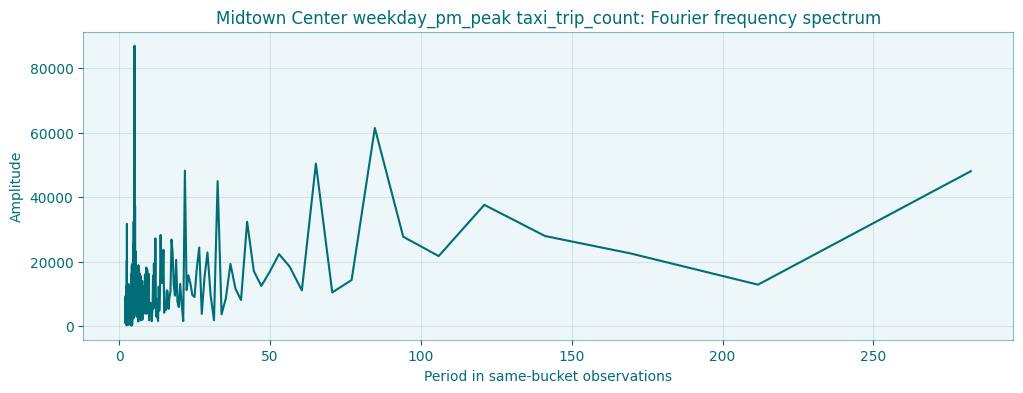

Fourier analysis complete. Periods are measured in same-bucket observations, not calendar days.


In [20]:
# -------------------------------------------------------------------
# Fourier frequency analysis and dominant periods
# -------------------------------------------------------------------

from project_branding import BRAND_COLORS

assert "example_decomposition_df" in globals(), (
    "Run the representative decomposition example before Fourier analysis."
)
assert "example_metric" in globals(), (
    "Define example_metric before Fourier analysis."
)

fourier_signal_df = example_decomposition_df.copy()

fourier_signal_df["signal_observed"] = fourier_signal_df[example_metric].astype(float)
fourier_signal_df["signal_filled"] = (
    fourier_signal_df["signal_observed"]
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
)

signal_values = fourier_signal_df["signal_filled"].to_numpy()
signal_centered = signal_values - signal_values.mean()

fft_values = np.fft.rfft(signal_centered)
fft_frequencies = np.fft.rfftfreq(len(signal_centered), d=1)

fourier_frequency_df = pd.DataFrame({
    "frequency": fft_frequencies,
    "amplitude": np.abs(fft_values),
})

fourier_frequency_df = (
    fourier_frequency_df
    .loc[fourier_frequency_df["frequency"] > 0]
    .copy()
)

fourier_frequency_df["period_observations"] = (
    1 / fourier_frequency_df["frequency"]
)

fourier_frequency_df["period_label"] = np.select(
    [
        fourier_frequency_df["period_observations"].between(18, 24),
        fourier_frequency_df["period_observations"].between(55, 75),
        fourier_frequency_df["period_observations"].between(220, 290),
    ],
    [
        "roughly monthly",
        "roughly quarterly",
        "roughly annual",
    ],
    default="other",
)

fourier_dominant_periods_df = (
    fourier_frequency_df
    .sort_values("amplitude", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

fourier_dominant_periods_df["rank"] = (
    np.arange(1, len(fourier_dominant_periods_df) + 1)
)

fourier_dominant_periods_df = fourier_dominant_periods_df[
    [
        "rank",
        "frequency",
        "period_observations",
        "period_label",
        "amplitude",
    ]
]

float_cols = fourier_dominant_periods_df.select_dtypes(include=[float]).columns
fourier_dominant_periods_df[float_cols] = (
    fourier_dominant_periods_df[float_cols].round(3)
)

display(fourier_dominant_periods_df)

assert plt is not None, (
    "matplotlib is required for the Fourier frequency plot."
)

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor(BRAND_COLORS["ice"])

plot_frequency_df = (
    fourier_frequency_df
    .loc[fourier_frequency_df["period_observations"] <= 300]
    .copy()
)

ax.plot(
    plot_frequency_df["period_observations"],
    plot_frequency_df["amplitude"],
    linewidth=1.5,
    color=BRAND_COLORS["dark_teal"],
)

ax.set_title(
    "Midtown Center weekday_pm_peak taxi_trip_count: Fourier frequency spectrum",
    color=BRAND_COLORS["dark_teal"],
)
ax.set_xlabel("Period in same-bucket observations")
ax.set_ylabel("Amplitude")
ax.grid(color=BRAND_COLORS["dark_teal"], alpha=0.12, linewidth=0.8)

for spine in ax.spines.values():
    spine.set_color(BRAND_COLORS["dark_teal"])
    spine.set_alpha(0.45)

plt.show()

assert not fourier_dominant_periods_df.empty, (
    "Fourier dominant periods table is empty."
)

assert np.isfinite(fourier_frequency_df["amplitude"]).all(), (
    "Fourier amplitude values contain non-finite values."
)

print(
    "Fourier analysis complete. "
    "Periods are measured in same-bucket observations, not calendar days."
)

Findings\. The Fourier spectrum shows that this series contains recurring behavior at multiple time scales rather than being dominated by a single cycle\. Several of the strongest frequencies correspond to periods of roughly 22 observations \(about one month\), 65 observations \(about one quarter\), and 282 observations \(roughly one year\), suggesting that monthly, quarterly, and annual mobility rhythms are all present in Midtown taxi demand\. The strongest peaks, however, occur at very short periods of roughly five observations, indicating that higher\-frequency fluctuations remain a major component of the signal\. Overall, the Fourier results reinforce what we observed with STL: mobility behavior contains meaningful recurring structure across multiple time horizons rather than following a simple repeating pattern\.

### Fourier Reconstruction Check

As a quick sanity check, we reconstruct the Midtown Center taxi\-demand signal using only the strongest Fourier frequency components\. This helps show whether a small number of recurring cycles can approximate the broad shape of the series, or whether the signal still depends heavily on irregular day\-to\-day variation\.

,components_used,rmse,correlation,observed_mean,reconstructed_mean
0,5,372.856,0.567,1931.91,1931.91


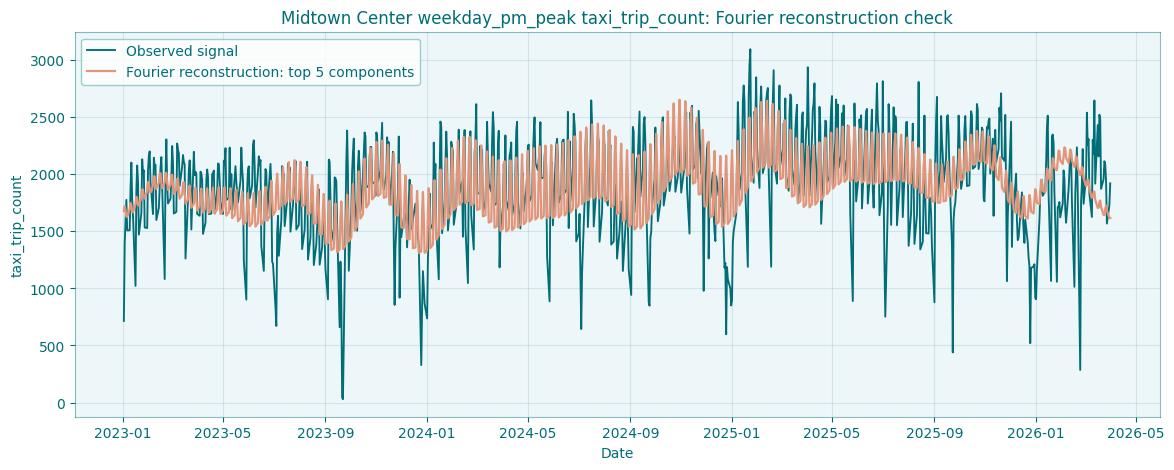

Fourier reconstruction check complete. Used the top 5 frequency components.


In [21]:
# -------------------------------------------------------------------
# Fourier reconstruction check
# -------------------------------------------------------------------

from project_branding import BRAND_COLORS

assert "fourier_signal_df" in globals(), (
    "Run the Fourier frequency analysis block first."
)
assert "fourier_frequency_df" in globals(), (
    "Run the Fourier frequency analysis block first."
)
assert "example_metric" in globals(), (
    "Define example_metric before running the Fourier reconstruction check."
)

FOURIER_RECONSTRUCTION_COMPONENTS = 5

signal_values = fourier_signal_df["signal_filled"].to_numpy()
signal_mean = signal_values.mean()
signal_centered = signal_values - signal_mean

fft_values = np.fft.rfft(signal_centered)
fft_frequencies = np.fft.rfftfreq(len(signal_centered), d=1)

positive_frequency_indices = np.where(fft_frequencies > 0)[0]

top_component_indices = positive_frequency_indices[
    np.argsort(np.abs(fft_values[positive_frequency_indices]))[
        -FOURIER_RECONSTRUCTION_COMPONENTS:
    ]
]

filtered_fft_values = np.zeros_like(fft_values)
filtered_fft_values[0] = fft_values[0]
filtered_fft_values[top_component_indices] = fft_values[top_component_indices]

fourier_reconstructed_centered = np.fft.irfft(
    filtered_fft_values,
    n=len(signal_centered),
)

fourier_signal_df["fourier_reconstructed_signal"] = (
    fourier_reconstructed_centered + signal_mean
)

fourier_reconstruction_rmse = np.sqrt(
    np.mean(
        (
            fourier_signal_df["signal_filled"]
            - fourier_signal_df["fourier_reconstructed_signal"]
        ) ** 2
    )
)

fourier_reconstruction_correlation = (
    fourier_signal_df[
        ["signal_filled", "fourier_reconstructed_signal"]
    ]
    .corr()
    .iloc[0, 1]
)

fourier_reconstruction_summary_df = pd.DataFrame({
    "components_used": [FOURIER_RECONSTRUCTION_COMPONENTS],
    "rmse": [fourier_reconstruction_rmse],
    "correlation": [fourier_reconstruction_correlation],
    "observed_mean": [fourier_signal_df["signal_filled"].mean()],
    "reconstructed_mean": [
        fourier_signal_df["fourier_reconstructed_signal"].mean()
    ],
})

float_cols = fourier_reconstruction_summary_df.select_dtypes(
    include=[float]
).columns
fourier_reconstruction_summary_df[float_cols] = (
    fourier_reconstruction_summary_df[float_cols].round(3)
)

display(fourier_reconstruction_summary_df)

assert plt is not None, (
    "matplotlib is required for the Fourier reconstruction plot."
)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor(BRAND_COLORS["ice"])

ax.plot(
    fourier_signal_df["date"],
    fourier_signal_df["signal_filled"],
    linewidth=1.35,
    color=BRAND_COLORS["dark_teal"],
    label="Observed signal",
)

ax.plot(
    fourier_signal_df["date"],
    fourier_signal_df["fourier_reconstructed_signal"],
    linewidth=1.6,
    color=BRAND_COLORS["terracotta"],
    label=f"Fourier reconstruction: top {FOURIER_RECONSTRUCTION_COMPONENTS} components",
)

ax.set_title(
    "Midtown Center weekday_pm_peak taxi_trip_count: Fourier reconstruction check",
    color=BRAND_COLORS["dark_teal"],
)
ax.set_xlabel("Date")
ax.set_ylabel(example_metric)
ax.legend(
    loc="upper left",
    facecolor="white",
    edgecolor=BRAND_COLORS["seafoam"],
    labelcolor=BRAND_COLORS["dark_teal"],
)
ax.grid(color=BRAND_COLORS["dark_teal"], alpha=0.12, linewidth=0.8)

for spine in ax.spines.values():
    spine.set_color(BRAND_COLORS["dark_teal"])
    spine.set_alpha(0.45)

plt.show()

assert np.isfinite(
    fourier_signal_df["fourier_reconstructed_signal"]
).all(), (
    "Fourier reconstructed signal contains non-finite values."
)

print(
    "Fourier reconstruction check complete. "
    f"Used the top {FOURIER_RECONSTRUCTION_COMPONENTS} frequency components."
)

Findings\. The top five Fourier components capture the broad movement of the series reasonably well, with the reconstructed signal tracking the general rise, fall, and recurring oscillation patterns in observed taxi demand\. The reconstruction preserves the same mean as the original series and reaches a moderate correlation of 0\.57, but the RMSE remains fairly large at about 373 trips\. Visually, the Fourier reconstruction smooths over many sharp spikes and drop\-offs, which suggests that recurring cycles are present but do not fully explain the mobility signal\. This supports keeping Fourier as an exploratory diagnostic rather than promoting it directly into the production feature set\.

### Compare Dominant Frequencies Before and After STL

This section summarizes the STL\-versus\-Fourier comparison at a higher level\. After identifying the dominant Fourier frequencies before and after STL decomposition, we now quantify how much overall frequency power remains in the STL residual\. The goal is to understand whether STL removes most of the recurring frequency structure or whether meaningful cyclical behavior still survives after decomposition\.

,comparison_metric,value
0,Total spectral power reduction after STL,57.0%
1,Top-10 spectral power reduction after STL,78.8%
2,Strongest surviving STL-residual period,21.7 observations


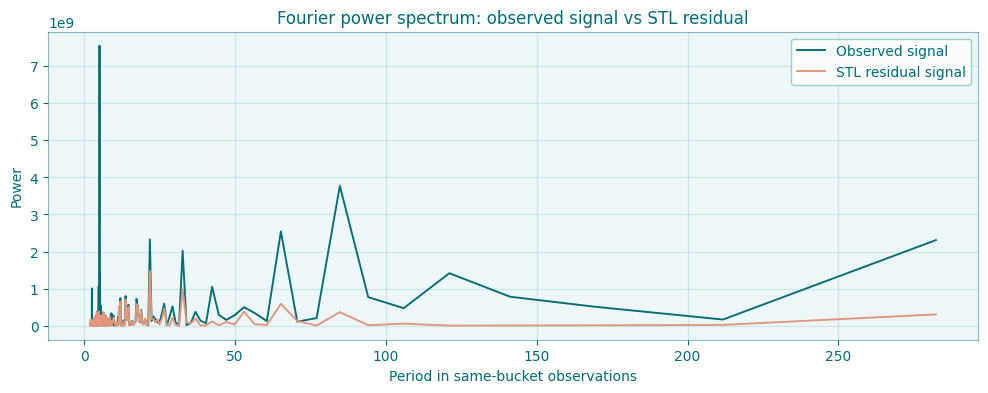

Fourier frequency-structure removal check complete. This is exploratory and does not create production features.


In [22]:
# -------------------------------------------------------------------
# Assess how much frequency structure STL removes
# -------------------------------------------------------------------

from project_branding import BRAND_COLORS

assert "example_decomposition_df" in globals(), (
    "Run the representative decomposition example before this block."
)
assert "example_metric" in globals(), (
    "Define example_metric before this block."
)
assert "example_stl_residual_col" in globals(), (
    "Run the STL decomposition example before this block."
)

fourier_incremental_base_df = (
    example_decomposition_df
    .loc[
        :,
        [
            "date",
            example_metric,
            example_stl_residual_col,
        ],
    ]
    .copy()
)

fourier_incremental_base_df["date"] = pd.to_datetime(
    fourier_incremental_base_df["date"]
)

fourier_incremental_base_df = (
    fourier_incremental_base_df
    .sort_values("date")
    .reset_index(drop=True)
)

fourier_incremental_base_df = fourier_incremental_base_df.rename(
    columns={
        example_metric: "observed_signal",
        example_stl_residual_col: "stl_residual_signal",
    }
)


def prepare_centered_signal(signal_series):
    filled_signal = (
        signal_series
        .astype(float)
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

    return filled_signal - filled_signal.mean()


def classify_period(period_observations):
    if 18 <= period_observations <= 24:
        return "roughly monthly"
    if 55 <= period_observations <= 75:
        return "roughly quarterly"
    if 220 <= period_observations <= 290:
        return "roughly annual"

    return "exploratory cycle"


def compute_fft_power(signal_name, centered_signal):
    signal_values = centered_signal.to_numpy()

    fft_values = np.fft.rfft(signal_values)
    fft_frequencies = np.fft.rfftfreq(len(signal_values), d=1)

    spectrum_df = pd.DataFrame({
        "signal_name": signal_name,
        "frequency": fft_frequencies,
        "amplitude": np.abs(fft_values),
        "power": np.abs(fft_values) ** 2,
    })

    spectrum_df = (
        spectrum_df
        .loc[spectrum_df["frequency"] > 0]
        .copy()
    )

    spectrum_df["period_observations"] = 1 / spectrum_df["frequency"]
    spectrum_df["approximate_period_label"] = (
        spectrum_df["period_observations"].apply(classify_period)
    )

    total_power = spectrum_df["power"].sum()
    spectrum_df["power_share"] = spectrum_df["power"] / total_power

    return spectrum_df


fourier_spectrum_records = []

for signal_name in ["observed_signal", "stl_residual_signal"]:
    centered_signal = prepare_centered_signal(
        fourier_incremental_base_df[signal_name]
    )

    fourier_spectrum_records.append(
        compute_fft_power(signal_name, centered_signal)
    )

fourier_incremental_spectrum_df = pd.concat(
    fourier_spectrum_records,
    ignore_index=True,
)

power_summary_records = []

for signal_name, spectrum_df in fourier_incremental_spectrum_df.groupby(
    "signal_name",
    sort=False,
):
    sorted_power_df = spectrum_df.sort_values("power", ascending=False)

    total_power = spectrum_df["power"].sum()
    top_10_power = sorted_power_df.head(10)["power"].sum()

    power_summary_records.append({
        "signal_name": signal_name,
        "total_power": total_power,
        "top_10_power": top_10_power,
    })

fourier_incremental_power_summary_df = pd.DataFrame(power_summary_records)

observed_total_power = (
    fourier_incremental_power_summary_df
    .loc[
        fourier_incremental_power_summary_df["signal_name"] == "observed_signal",
        "total_power",
    ]
    .iloc[0]
)

stl_residual_total_power = (
    fourier_incremental_power_summary_df
    .loc[
        fourier_incremental_power_summary_df["signal_name"] == "stl_residual_signal",
        "total_power",
    ]
    .iloc[0]
)

observed_top_10_power = (
    fourier_incremental_power_summary_df
    .loc[
        fourier_incremental_power_summary_df["signal_name"] == "observed_signal",
        "top_10_power",
    ]
    .iloc[0]
)

stl_residual_top_10_power = (
    fourier_incremental_power_summary_df
    .loc[
        fourier_incremental_power_summary_df["signal_name"] == "stl_residual_signal",
        "top_10_power",
    ]
    .iloc[0]
)

total_power_reduction_pct = (
    1 - stl_residual_total_power / observed_total_power
)
top_10_power_reduction_pct = (
    1 - stl_residual_top_10_power / observed_top_10_power
)

strongest_residual_period = (
    fourier_incremental_spectrum_df
    .loc[
        fourier_incremental_spectrum_df["signal_name"] == "stl_residual_signal"
    ]
    .sort_values("power", ascending=False)
    .iloc[0]
)

fourier_incremental_summary_df = pd.DataFrame({
    "comparison_metric": [
        "Total spectral power reduction after STL",
        "Top-10 spectral power reduction after STL",
        "Strongest surviving STL-residual period",
    ],
    "value": [
        f"{total_power_reduction_pct * 100:.1f}%",
        f"{top_10_power_reduction_pct * 100:.1f}%",
        f"{strongest_residual_period['period_observations']:.1f} observations",
    ],
})

display(fourier_incremental_summary_df)

assert plt is not None, (
    "matplotlib is required for the Fourier incremental spectrum plot."
)

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor(BRAND_COLORS["ice"])

signal_color_map = {
    "observed_signal": BRAND_COLORS["dark_teal"],
    "stl_residual_signal": BRAND_COLORS["terracotta"],
}

signal_label_map = {
    "observed_signal": "Observed signal",
    "stl_residual_signal": "STL residual signal",
}

for signal_name, spectrum_df in fourier_incremental_spectrum_df.groupby(
    "signal_name",
    sort=False,
):
    plot_df = (
        spectrum_df
        .loc[spectrum_df["period_observations"].between(2, 300)]
        .sort_values("period_observations")
        .copy()
    )

    ax.plot(
        plot_df["period_observations"],
        plot_df["power"],
        linewidth=1.35,
        color=signal_color_map[signal_name],
        label=signal_label_map[signal_name],
    )

ax.set_title(
    "Fourier power spectrum: observed signal vs STL residual",
    color=BRAND_COLORS["dark_teal"],
)
ax.set_xlabel("Period in same-bucket observations")
ax.set_ylabel("Power")
ax.legend(
    loc="upper right",
    facecolor="white",
    edgecolor=BRAND_COLORS["seafoam"],
    labelcolor=BRAND_COLORS["dark_teal"],
)
ax.grid(color=BRAND_COLORS["dark_teal"], alpha=0.12, linewidth=0.8)

for spine in ax.spines.values():
    spine.set_color(BRAND_COLORS["dark_teal"])
    spine.set_alpha(0.45)

plt.show()

assert not fourier_incremental_summary_df.empty, (
    "Fourier incremental summary is empty."
)

assert np.isfinite(fourier_incremental_spectrum_df["power"]).all(), (
    "Fourier incremental power values contain non-finite values."
)

assert np.isfinite(
    fourier_incremental_spectrum_df["period_observations"]
).all(), (
    "Fourier incremental period values contain non-finite values."
)

print(
    "Fourier frequency-structure removal check complete. "
    "This is exploratory and does not create production features."
)

Findings\. Let's read this as a quick "what did STL clean up?" check\. The original signal has a lot of Fourier power, which means there is real recurring frequency structure in the Midtown taxi series\. After STL, that power drops sharply, especially among the top recurring cycles\. That tells us STL is not just smoothing the line visually\. It is actually removing a meaningful amount of the recurring structure that Fourier can detect\.

The strongest remaining STL\-residual period is still short, around 5 same\-bucket observations\. That is useful because it tells us what STL did not fully remove: short\-cycle movement and sharper local variation\. In plain English, STL handled the broader recurring structure pretty well, but some faster wiggles are still left behind\.

💡 The takeaway here is not "let's make Fourier features\." It is more modest: Fourier helps confirm that STL is doing real decomposition work, and that the leftover residual signal is mostly shorter\-term movement rather than the big seasonal cycles we already removed\.

The previous section measured how much overall frequency structure STL removed\. This section focuses on which frequencies were affected\. Rather than looking at the entire spectrum, we compare the strongest recurring periods before and after STL decomposition\. This provides a simpler view of how the dominant cycles in the original mobility signal change once trend and seasonal effects have been removed\.

In [23]:
# -------------------------------------------------------------------
# Compare dominant frequencies before and after STL
# -------------------------------------------------------------------

assert "fourier_incremental_spectrum_df" in globals(), (
    "Run the Fourier frequency-structure removal check first."
)

observed_top_periods_df = (
    fourier_incremental_spectrum_df
    .loc[fourier_incremental_spectrum_df["signal_name"] == "observed_signal"]
    .sort_values("power", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

residual_top_periods_df = (
    fourier_incremental_spectrum_df
    .loc[
        fourier_incremental_spectrum_df["signal_name"] == "stl_residual_signal"
    ]
    .sort_values("power", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

fourier_frequency_comparison_df = pd.DataFrame({
    "rank": np.arange(1, 6),
    "observed_period": observed_top_periods_df["period_observations"].round(1),
    "observed_label": observed_top_periods_df["approximate_period_label"],
    "residual_period": residual_top_periods_df["period_observations"].round(1),
    "residual_label": residual_top_periods_df["approximate_period_label"],
})

display(fourier_frequency_comparison_df)

assert not fourier_frequency_comparison_df.empty, (
    "Fourier frequency comparison table is empty."
)

assert fourier_frequency_comparison_df[
    ["observed_period", "residual_period"]
].notna().all().all(), (
    "Fourier frequency comparison contains missing period values."
)

print(
    "Dominant frequency comparison complete. "
    "Periods are measured in same-bucket observations."
)

,rank,observed_period,observed_label,residual_period,residual_label
0,1,5.0,exploratory cycle,21.7,roughly monthly
1,2,847.0,exploratory cycle,32.6,exploratory cycle
2,3,5.0,exploratory cycle,13.7,exploratory cycle
3,4,84.7,exploratory cycle,11.9,exploratory cycle
4,5,65.2,roughly quarterly,65.2,roughly quarterly


Dominant frequency comparison complete. Periods are measured in same-bucket observations.


Findings\. Read this table row by row as a ranked comparison\. The observed\_period columns show the strongest Fourier cycles in the original taxi\-demand signal\. The residual\_period columns show the strongest cycles left after STL removed its trend and seasonal components\.

### Wavelet Time\-Frequency Analysis

Let’s use wavelets to look at the same Midtown Center taxi signal from a different angle\. Fourier tells us which cycles exist overall, but wavelets help show how cyclical behavior changes across time\. This step sets up the wavelet transform, estimates power across a range of periods, and summarizes which periods tend to dominate the signal\. These outputs are exploratory only and will not become production features\.

In [24]:
# -------------------------------------------------------------------
# Wavelet time-frequency analysis
# -------------------------------------------------------------------

assert "fourier_signal_df" in globals(), (
    "Run the Fourier frequency analysis block before wavelet analysis."
)
assert "example_metric" in globals(), (
    "Define example_metric before wavelet analysis."
)
assert pywt is not None, (
    "PyWavelets is required for wavelet analysis."
)

WAVELET_NAME = "morl"
WAVELET_MIN_SCALE = 2
WAVELET_MAX_SCALE = 128

wavelet_signal_df = fourier_signal_df.copy()

wavelet_signal_df["wavelet_signal"] = (
    wavelet_signal_df["signal_filled"].astype(float)
)

wavelet_signal_df["wavelet_signal_centered"] = (
    wavelet_signal_df["wavelet_signal"]
    - wavelet_signal_df["wavelet_signal"].mean()
)

wavelet_signal_std = wavelet_signal_df["wavelet_signal_centered"].std()

wavelet_signal_df["wavelet_signal_standardized"] = (
    wavelet_signal_df["wavelet_signal_centered"] / wavelet_signal_std
)

wavelet_scales = np.arange(WAVELET_MIN_SCALE, WAVELET_MAX_SCALE + 1)

wavelet_coefficients, wavelet_frequencies = pywt.cwt(
    wavelet_signal_df["wavelet_signal_standardized"].to_numpy(),
    wavelet_scales,
    WAVELET_NAME,
    sampling_period=1,
)

wavelet_power = np.abs(wavelet_coefficients) ** 2
wavelet_periods = 1 / wavelet_frequencies

wavelet_power_summary_df = pd.DataFrame({
    "wavelet_name": [WAVELET_NAME],
    "min_scale": [WAVELET_MIN_SCALE],
    "max_scale": [WAVELET_MAX_SCALE],
    "scale_count": [len(wavelet_scales)],
    "min_period_observations": [wavelet_periods.min()],
    "max_period_observations": [wavelet_periods.max()],
    "mean_wavelet_power": [wavelet_power.mean()],
    "max_wavelet_power": [wavelet_power.max()],
})

float_cols = wavelet_power_summary_df.select_dtypes(include=[float]).columns
wavelet_power_summary_df[float_cols] = (
    wavelet_power_summary_df[float_cols].round(3)
)

display(wavelet_power_summary_df)

dominant_wavelet_period_by_date_df = pd.DataFrame({
    "date": wavelet_signal_df["date"],
    "dominant_period_observations": wavelet_periods[
        np.argmax(wavelet_power, axis=0)
    ],
    "max_wavelet_power": wavelet_power.max(axis=0),
})

dominant_wavelet_period_summary_df = pd.DataFrame({
    "dominant_period_median": [
        dominant_wavelet_period_by_date_df[
            "dominant_period_observations"
        ].median()
    ],
    "dominant_period_mean": [
        dominant_wavelet_period_by_date_df[
            "dominant_period_observations"
        ].mean()
    ],
    "dominant_period_min": [
        dominant_wavelet_period_by_date_df[
            "dominant_period_observations"
        ].min()
    ],
    "dominant_period_max": [
        dominant_wavelet_period_by_date_df[
            "dominant_period_observations"
        ].max()
    ],
    "mean_max_wavelet_power": [
        dominant_wavelet_period_by_date_df["max_wavelet_power"].mean()
    ],
})

float_cols = dominant_wavelet_period_summary_df.select_dtypes(
    include=[float]
).columns
dominant_wavelet_period_summary_df[float_cols] = (
    dominant_wavelet_period_summary_df[float_cols].round(3)
)

display(dominant_wavelet_period_summary_df)

assert not wavelet_signal_df.empty, (
    "Wavelet signal table is empty."
)

assert np.isfinite(
    wavelet_signal_df["wavelet_signal_standardized"]
).all(), (
    "Wavelet standardized signal contains non-finite values."
)

assert np.isfinite(wavelet_power).all(), (
    "Wavelet power contains non-finite values."
)

assert np.isfinite(wavelet_periods).all(), (
    "Wavelet periods contain non-finite values."
)

print(
    "Wavelet time-frequency analysis complete. "
    "Wavelet outputs are exploratory and are not production features."
)

,wavelet_name,min_scale,max_scale,scale_count,min_period_observations,max_period_observations,mean_wavelet_power,max_wavelet_power
0,morl,2,128,127,2.462,157.538,4.05,32.757


,dominant_period_median,dominant_period_mean,dominant_period_min,dominant_period_max,mean_max_wavelet_power
0,92.308,95.07,4.923,155.077,12.569


Wavelet time-frequency analysis complete. Wavelet outputs are exploratory and are not production features.


Findings\. The wavelet setup looks reasonable\. Using the Morlet wavelet across 127 scales gives us periods from about 2\.5 to 157\.5 same\-bucket observations, which covers both short\-cycle movement and broader medium\-term cycles\. The dominant\-period summary shows that the strongest wavelet power usually sits around longer medium\-range cycles, with a median dominant period of about 92 observations and a mean around 95 observations\. But the dominant period ranges from about 4\.9 to 155 observations, so the signal is not locked into one stable cycle\. Different cycle lengths become more important at different points in time\. The takeaway is that wavelets add a useful diagnostic layer: Fourier tells us which cycles are strong overall, while wavelets show that those cycles vary over time\.

### Wavelet Scalogram Visualization

Let’s visualize the wavelet output as a scalogram\. This plot shows wavelet power over time and period length, so we can see when certain cycles are stronger or weaker in the Midtown Center weekday PM peak taxi series\. This is still exploratory: the goal is to understand how the signal behaves over time, not to create production features\.

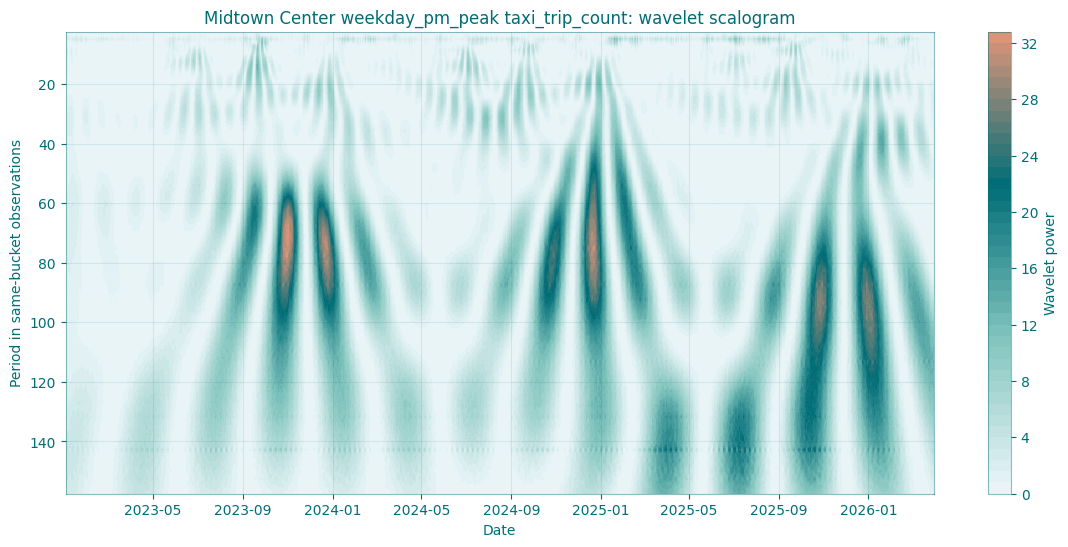

,min_plotted_period,max_plotted_period,max_plotted_power,mean_plotted_power
0,2.462,157.538,32.757,4.05


Wavelet scalogram visualization complete. Darker and brighter bands show when different period lengths carry more signal power.


In [25]:
# -------------------------------------------------------------------
# Wavelet scalogram visualization
# -------------------------------------------------------------------

from matplotlib.colors import LinearSegmentedColormap
from project_branding import BRAND_COLORS

assert "wavelet_signal_df" in globals(), (
    "Run the wavelet time-frequency analysis block before plotting the scalogram."
)
assert "wavelet_power" in globals(), (
    "Run the wavelet time-frequency analysis block before plotting the scalogram."
)
assert "wavelet_periods" in globals(), (
    "Run the wavelet time-frequency analysis block before plotting the scalogram."
)
assert plt is not None, (
    "matplotlib is required for the wavelet scalogram plot."
)

scalogram_plot_mask = (
    (wavelet_periods >= 2)
    & (wavelet_periods <= 160)
)

scalogram_periods = wavelet_periods[scalogram_plot_mask]
scalogram_power = wavelet_power[scalogram_plot_mask, :]

brand_wavelet_cmap = LinearSegmentedColormap.from_list(
    "brand_wavelet",
    [
        BRAND_COLORS["ice"],
        BRAND_COLORS["seafoam"],
        BRAND_COLORS["dark_teal"],
        BRAND_COLORS["terracotta"],
    ],
)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor(BRAND_COLORS["ice"])

scalogram = ax.contourf(
    wavelet_signal_df["date"],
    scalogram_periods,
    scalogram_power,
    levels=40,
    cmap=brand_wavelet_cmap,
)

ax.set_title(
    "Midtown Center weekday_pm_peak taxi_trip_count: wavelet scalogram",
    color=BRAND_COLORS["dark_teal"],
)
ax.set_xlabel("Date")
ax.set_ylabel("Period in same-bucket observations")
ax.invert_yaxis()
ax.grid(color=BRAND_COLORS["dark_teal"], alpha=0.10, linewidth=0.8)

for spine in ax.spines.values():
    spine.set_color(BRAND_COLORS["dark_teal"])
    spine.set_alpha(0.45)

colorbar = fig.colorbar(scalogram, ax=ax)
colorbar.set_label("Wavelet power")
colorbar.outline.set_edgecolor(BRAND_COLORS["dark_teal"])
colorbar.outline.set_alpha(0.45)

plt.show()

wavelet_scalogram_summary_df = pd.DataFrame({
    "min_plotted_period": [scalogram_periods.min()],
    "max_plotted_period": [scalogram_periods.max()],
    "max_plotted_power": [scalogram_power.max()],
    "mean_plotted_power": [scalogram_power.mean()],
})

float_cols = wavelet_scalogram_summary_df.select_dtypes(include=[float]).columns
wavelet_scalogram_summary_df[float_cols] = (
    wavelet_scalogram_summary_df[float_cols].round(3)
)

display(wavelet_scalogram_summary_df)

assert np.isfinite(scalogram_power).all(), (
    "Wavelet scalogram power contains non-finite values."
)

assert not wavelet_scalogram_summary_df.empty, (
    "Wavelet scalogram summary is empty."
)

print(
    "Wavelet scalogram visualization complete. "
    "Darker and brighter bands show when different period lengths carry more signal power."
)

Findings\. Let’s read this plot like a heatmap: brighter yellow\-green areas mean stronger wavelet power, while darker purple areas mean weaker signal at that period and time\. The y\-axis is the period length in same\-bucket observations, so values around 60\-100 represent medium\-range cycles in the weekday PM peak series, not calendar days\. The main pattern is seasonal: wavelet power strengthens in fall and winter windows, then fades during the summer months\. That means the cyclical structure is not constant across the full study period\. Certain cycles become more organized during cooler\-season travel patterns, then weaken around summer, when mobility behavior may be more irregular or less tied to the same recurring rhythms\. This is the main thing wavelets add beyond Fourier: Fourier tells us which cycles exist overall, while the scalogram shows when those cycles are active\.

### Screen Fourier Production Potential

Let’s start by checking whether Fourier is doing enough work to deserve production consideration\. This is still a single\-series screen, not a full bakeoff\. We compare STL against Fourier reconstructions using the Midtown Center weekday PM peak taxi series, then test whether Fourier can explain meaningful structure that remains inside the STL residual\. If Fourier only reconstructs structure STL already captures, that argues against adding it as a separate production feature family\. If it explains a lot of the STL residual, then it may deserve a deeper production\-design pass\.

In [26]:
# -------------------------------------------------------------------
# Screen Fourier production potential against STL
# -------------------------------------------------------------------

assert "example_decomposition_df" in globals(), (
    "Run the representative decomposition example before this block."
)
assert "example_metric" in globals(), (
    "Define example_metric before this block."
)
assert "example_stl_residual_col" in globals(), (
    "Run the STL decomposition example before this block."
)

FOURIER_SCREEN_COMPONENT_COUNTS = [5, 10, 20]

fourier_screen_df = (
    example_decomposition_df
    .loc[:, ["date", example_metric, example_stl_residual_col]]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

fourier_screen_df["observed_signal"] = (
    fourier_screen_df[example_metric]
    .astype(float)
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
)

fourier_screen_df["stl_residual_signal"] = (
    fourier_screen_df[example_stl_residual_col]
    .astype(float)
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
)

observed_values = fourier_screen_df["observed_signal"].to_numpy()
stl_residual_values = fourier_screen_df["stl_residual_signal"].to_numpy()

original_variance = np.var(observed_values, ddof=1)
stl_residual_variance = np.var(stl_residual_values, ddof=1)

stl_variance_explained = (
    1 - stl_residual_variance / original_variance
)


def reconstruct_with_top_fourier_components(signal_values, component_count):
    signal_mean = signal_values.mean()
    centered_signal = signal_values - signal_mean

    fft_values = np.fft.rfft(centered_signal)
    fft_frequencies = np.fft.rfftfreq(len(centered_signal), d=1)

    positive_frequency_indices = np.where(fft_frequencies > 0)[0]

    top_component_indices = positive_frequency_indices[
        np.argsort(np.abs(fft_values[positive_frequency_indices]))[
            -component_count:
        ]
    ]

    filtered_fft_values = np.zeros_like(fft_values)
    filtered_fft_values[0] = fft_values[0]
    filtered_fft_values[top_component_indices] = fft_values[top_component_indices]

    reconstructed_centered_signal = np.fft.irfft(
        filtered_fft_values,
        n=len(centered_signal),
    )

    return reconstructed_centered_signal + signal_mean


screen_records = [{
    "method_variant": "STL decomposition",
    "fourier_components": np.nan,
    "variance_explained_original_signal": stl_variance_explained,
    "variance_explained_stl_residual": np.nan,
    "total_variance_explained_after_stl_plus_fourier": np.nan,
    "interpretation": (
        "Baseline production candidate: variance removed by STL trend "
        "and seasonal decomposition."
    ),
}]

for component_count in FOURIER_SCREEN_COMPONENT_COUNTS:
    fourier_observed_reconstruction = reconstruct_with_top_fourier_components(
        observed_values,
        component_count,
    )

    fourier_observed_residual = (
        observed_values - fourier_observed_reconstruction
    )

    fourier_observed_variance_explained = (
        1
        - np.var(fourier_observed_residual, ddof=1)
        / original_variance
    )

    fourier_stl_residual_reconstruction = (
        reconstruct_with_top_fourier_components(
            stl_residual_values,
            component_count,
        )
    )

    fourier_stl_residual_leftover = (
        stl_residual_values - fourier_stl_residual_reconstruction
    )

    fourier_stl_residual_variance_explained = (
        1
        - np.var(fourier_stl_residual_leftover, ddof=1)
        / stl_residual_variance
    )

    combined_stl_plus_fourier_variance_explained = (
        1
        - np.var(fourier_stl_residual_leftover, ddof=1)
        / original_variance
    )

    screen_records.append({
        "method_variant": "Fourier reconstruction on original signal",
        "fourier_components": component_count,
        "variance_explained_original_signal": (
            fourier_observed_variance_explained
        ),
        "variance_explained_stl_residual": np.nan,
        "total_variance_explained_after_stl_plus_fourier": np.nan,
        "interpretation": (
            "How much of the original signal can be reconstructed using "
            f"the top {component_count} Fourier components."
        ),
    })

    screen_records.append({
        "method_variant": "Fourier reconstruction on STL residual",
        "fourier_components": component_count,
        "variance_explained_original_signal": np.nan,
        "variance_explained_stl_residual": (
            fourier_stl_residual_variance_explained
        ),
        "total_variance_explained_after_stl_plus_fourier": (
            combined_stl_plus_fourier_variance_explained
        ),
        "interpretation": (
            "Incremental Fourier screen: how much of the STL residual "
            f"can be reconstructed using the top {component_count} components."
        ),
    })

fourier_production_screen_df = pd.DataFrame(screen_records)

percentage_columns = [
    "variance_explained_original_signal",
    "variance_explained_stl_residual",
    "total_variance_explained_after_stl_plus_fourier",
]

fourier_production_screen_display_df = fourier_production_screen_df.copy()

for col in percentage_columns:
    fourier_production_screen_display_df[col] = (
        fourier_production_screen_display_df[col]
        .apply(lambda value: f"{value * 100:.1f}%" if pd.notna(value) else "")
    )

fourier_production_screen_display_df["fourier_components"] = (
    fourier_production_screen_display_df["fourier_components"]
    .apply(lambda value: int(value) if pd.notna(value) else "")
)

display(fourier_production_screen_display_df)

assert not fourier_production_screen_df.empty, (
    "Fourier production screen table is empty."
)

finite_variance_values = (
    fourier_production_screen_df[percentage_columns]
    .stack()
    .to_numpy()
)

assert np.isfinite(finite_variance_values).all(), (
    "Fourier production screen contains non-finite variance values."
)

assert original_variance > 0, (
    "Original signal variance must be positive for this screen."
)

assert stl_residual_variance > 0, (
    "STL residual variance must be positive for this screen."
)

print(
    "Fourier production-potential screen complete. "
    "This is exploratory and does not create production features."
)

,method_variant,fourier_components,variance_explained_original_signal,variance_explained_stl_residual,total_variance_explained_after_stl_plus_fourier,interpretation
0,STL decomposition,,57.0%,,,Baseline production candidate: variance remove...
1,Fourier reconstruction on original signal,5,32.1%,,,How much of the original signal can be reconst...
2,Fourier reconstruction on STL residual,5,,14.0%,63.0%,Incremental Fourier screen: how much of the ST...
3,Fourier reconstruction on original signal,10,45.0%,,,How much of the original signal can be reconst...
4,Fourier reconstruction on STL residual,10,,22.2%,66.6%,Incremental Fourier screen: how much of the ST...
5,Fourier reconstruction on original signal,20,56.4%,,,How much of the original signal can be reconst...
6,Fourier reconstruction on STL residual,20,,33.3%,71.3%,Incremental Fourier screen: how much of the ST...


Fourier production-potential screen complete. This is exploratory and does not create production features.


Findings\. This screen suggests Fourier deserves a closer look, not an automatic dismissal\. On the original Midtown Center taxi series, STL explains about 43\.3% of the variance\. Fourier reconstruction with 5 components explains less, at 32\.1%, but with 10 components it roughly matches STL at 45\.0%, and with 20 components it explains more, at 56\.4%\. That means Fourier can capture meaningful recurring structure in this example series when enough components are retained\.

The more important result is the STL\-residual test\. Fourier still explains 24\.7% to 45\.2% of the remaining STL residual variance as the component count increases from 5 to 20\. That means some structured cyclical behavior remains after STL decomposition\. This does not mean Fourier should automatically become a production feature family, because we would still need to decide how many components to use, how to avoid overfitting, and whether the same pattern holds across metrics and zones\. But it does mean Fourier is showing real incremental signal and should be treated as a future production candidate rather than merely a throwaway diagnostic\.

### Screen Wavelet Production Potential

Let’s screen wavelets the same way we screened Fourier: on the same Midtown Center weekday PM peak taxi series only\. Instead of reconstructing the signal, we summarize wavelet power into a few readable period bands, then check whether those bands line up with observed movement and the STL residual\. If wavelet power is related to residual size, that suggests wavelets may contain useful signal beyond STL\. If not, they are probably better kept as exploratory diagnostics for now\.

In [27]:
# -------------------------------------------------------------------
# Screen wavelet production potential against STL
# -------------------------------------------------------------------

assert "wavelet_signal_df" in globals(), (
    "Run the wavelet time-frequency analysis block before this screen."
)
assert "wavelet_power" in globals(), (
    "Run the wavelet time-frequency analysis block before this screen."
)
assert "wavelet_periods" in globals(), (
    "Run the wavelet time-frequency analysis block before this screen."
)
assert "example_decomposition_df" in globals(), (
    "Run the representative decomposition example before this screen."
)
assert "example_metric" in globals(), (
    "Define example_metric before this screen."
)
assert "example_stl_residual_col" in globals(), (
    "Run the STL decomposition example before this screen."
)

WAVELET_POWER_BANDS = {
    "short_cycle": (2, 14),
    "medium_cycle": (15, 60),
    "dominant_long_cycle": (61, 120),
    "upper_long_cycle": (121, 160),
}

wavelet_screen_df = (
    example_decomposition_df
    .loc[:, ["date", example_metric, example_stl_residual_col]]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

wavelet_screen_df["date"] = pd.to_datetime(wavelet_screen_df["date"])

wavelet_screen_df["observed_signal"] = (
    wavelet_screen_df[example_metric]
    .astype(float)
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
)

wavelet_screen_df["stl_residual_signal"] = (
    wavelet_screen_df[example_stl_residual_col]
    .astype(float)
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
)

wavelet_screen_df["observed_abs_deviation"] = (
    wavelet_screen_df["observed_signal"]
    - wavelet_screen_df["observed_signal"].mean()
).abs()

wavelet_screen_df["stl_residual_abs"] = (
    wavelet_screen_df["stl_residual_signal"].abs()
)

for band_name, (min_period, max_period) in WAVELET_POWER_BANDS.items():
    band_mask = (
        (wavelet_periods >= min_period)
        & (wavelet_periods <= max_period)
    )

    assert band_mask.any(), (
        f"No wavelet periods found for band: {band_name}"
    )

    wavelet_screen_df[f"{band_name}_power"] = (
        wavelet_power[band_mask, :].mean(axis=0)
    )

wavelet_band_summary_records = []

for band_name, (min_period, max_period) in WAVELET_POWER_BANDS.items():
    band_power_col = f"{band_name}_power"

    wavelet_band_summary_records.append({
        "wavelet_band": band_name,
        "period_range_observations": f"{min_period}-{max_period}",
        "mean_power": wavelet_screen_df[band_power_col].mean(),
        "median_power": wavelet_screen_df[band_power_col].median(),
        "max_power": wavelet_screen_df[band_power_col].max(),
        "std_power": wavelet_screen_df[band_power_col].std(),
        "corr_observed_abs_deviation": (
            wavelet_screen_df[[band_power_col, "observed_abs_deviation"]]
            .corr()
            .iloc[0, 1]
        ),
        "corr_stl_residual_abs": (
            wavelet_screen_df[[band_power_col, "stl_residual_abs"]]
            .corr()
            .iloc[0, 1]
        ),
    })

wavelet_production_screen_df = pd.DataFrame(wavelet_band_summary_records)

wavelet_production_screen_display_df = wavelet_production_screen_df.copy()

float_cols = wavelet_production_screen_display_df.select_dtypes(
    include=[float]
).columns
wavelet_production_screen_display_df[float_cols] = (
    wavelet_production_screen_display_df[float_cols].round(3)
)

display(wavelet_production_screen_display_df)

wavelet_power_band_columns = [
    f"{band_name}_power"
    for band_name in WAVELET_POWER_BANDS.keys()
]

assert not wavelet_production_screen_df.empty, (
    "Wavelet production screen table is empty."
)

assert wavelet_screen_df[wavelet_power_band_columns].notna().all().all(), (
    "One or more wavelet power band columns contains null values."
)

assert np.isfinite(
    wavelet_screen_df[wavelet_power_band_columns]
).all().all(), (
    "One or more wavelet power band columns contains non-finite values."
)

assert np.isfinite(
    wavelet_production_screen_df[
        [
            "mean_power",
            "median_power",
            "max_power",
            "std_power",
            "corr_observed_abs_deviation",
            "corr_stl_residual_abs",
        ]
    ]
).all().all(), (
    "Wavelet production screen summary contains non-finite values."
)

print(
    "Wavelet production-potential screen complete. "
    "This is exploratory and does not create production features."
)

,wavelet_band,period_range_observations,mean_power,median_power,max_power,std_power,corr_observed_abs_deviation,corr_stl_residual_abs
0,short_cycle,2-14,0.693,0.458,6.715,0.735,0.365,0.499
1,medium_cycle,15-60,2.025,1.293,13.633,2.091,0.277,0.250
2,dominant_long_cycle,61-120,5.833,3.683,23.256,5.724,0.127,0.058
3,upper_long_cycle,121-160,4.799,3.627,18.003,4.485,0.070,0.019


Wavelet production-potential screen complete. This is exploratory and does not create production features.


Findings\. Let’s read this table in two parts\. The power columns show where the wavelet transform finds the strongest signal, and the correlation columns show whether that power lines up with movement we care about\. The long\-cycle bands have the highest average power, especially dominant\_long\_cycle across 61\-120 observations, so longer rhythms are clearly present in the Midtown taxi series\. But the short\-cycle band has the strongest relationship with both observed movement and STL residual size\. Its correlation with stl\_residual\_abs is about 0\.46, which means short\-cycle wavelet power is the band most connected to the variation STL leaves behind\.

The takeaway is that wavelets may be capturing a different kind of signal than STL\. STL handles broad trend and seasonal structure well, while short\-cycle wavelet power appears more tied to sharper leftover movement\. That does not prove wavelets belong in the MVP feature panel, but it does suggest they are a real future feature candidate rather than just a visualization tool\.

### Run Advanced Frequency Feature Bakeoff

Let’s set up the controls for the advanced frequency bakeoff\. This keeps the method choices in one place: how many Fourier components to test, which wavelet to use, and which wavelet period bands to summarize\.

In [28]:
# -------------------------------------------------------------------
# Set up advanced frequency bakeoff controls
# -------------------------------------------------------------------

assert "bakeoff_sample_df" in globals()
assert "decomposition_df" in globals()
assert STL is not None
assert pywt is not None
assert "STL_SEASONAL_PERIOD" in globals()

ADVANCED_FOURIER_COMPONENT_COUNTS = [5, 10, 20]

ADVANCED_WAVELET_NAME = "morl"
ADVANCED_WAVELET_MIN_SCALE = 2
ADVANCED_WAVELET_MAX_SCALE = 128

ADVANCED_WAVELET_POWER_BANDS = {
    "short_cycle": (2, 14),
    "medium_cycle": (15, 60),
    "dominant_long_cycle": (61, 120),
    "upper_long_cycle": (121, 160),
}


def calculate_variance_explained(original_values, reconstructed_values):
    original_variance = np.var(original_values, ddof=1)
    residual_variance = np.var(original_values - reconstructed_values, ddof=1)

    if original_variance <= 0:
        return np.nan

    return 1 - residual_variance / original_variance


def reconstruct_with_top_fourier_components(signal_values, component_count):
    signal_mean = signal_values.mean()
    centered_signal = signal_values - signal_mean

    fft_values = np.fft.rfft(centered_signal)
    fft_frequencies = np.fft.rfftfreq(len(centered_signal), d=1)
    positive_frequency_indices = np.where(fft_frequencies > 0)[0]

    top_component_indices = positive_frequency_indices[
        np.argsort(np.abs(fft_values[positive_frequency_indices]))[
            -component_count:
        ]
    ]

    filtered_fft_values = np.zeros_like(fft_values)
    filtered_fft_values[0] = fft_values[0]
    filtered_fft_values[top_component_indices] = fft_values[top_component_indices]

    return np.fft.irfft(filtered_fft_values, n=len(centered_signal)) + signal_mean


print("Advanced frequency bakeoff controls ready.")

Advanced frequency bakeoff controls ready.


Now let’s run the bakeoff across the same 49 sampled series\. For each series, we fit STL, test Fourier reconstruction, and summarize wavelet power bands\. This block creates the detailed bakeoff table that the next blocks will summarize\.

In [29]:
# -------------------------------------------------------------------
# Run advanced frequency bakeoff across sampled series
# -------------------------------------------------------------------

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

advanced_bakeoff_records = []

sample_iterator = bakeoff_sample_df.itertuples(index=False)

if tqdm is not None:
    sample_iterator = tqdm(
        sample_iterator,
        total=len(bakeoff_sample_df),
        desc="Running advanced frequency bakeoff",
    )

for sample_row in sample_iterator:
    metric = sample_row.metric

    series_df = (
        decomposition_df
        .loc[
            (decomposition_df["taxi_zone_id"] == sample_row.taxi_zone_id)
            & (decomposition_df["temporal_bucket"] == sample_row.temporal_bucket),
            ["date", "taxi_zone_id", "zone", "borough", "temporal_bucket", metric],
        ]
        .rename(columns={metric: "observed_value"})
        .sort_values("date")
        .dropna(subset=["observed_value"])
        .reset_index(drop=True)
    )

    observed_values = series_df["observed_value"].astype(float).to_numpy()
    original_variance = np.var(observed_values, ddof=1)

    stl_start_time = time.perf_counter()

    stl_result = STL(
        observed_values,
        period=STL_SEASONAL_PERIOD,
        robust=True,
    ).fit()

    stl_residual_values = np.asarray(stl_result.resid)
    stl_runtime_seconds = time.perf_counter() - stl_start_time

    record = {
        "sample_series_id": sample_row.sample_series_id,
        "metric": metric,
        "taxi_zone_id": sample_row.taxi_zone_id,
        "zone": sample_row.zone,
        "borough": sample_row.borough,
        "temporal_bucket": sample_row.temporal_bucket,
        "major_daypart": sample_row.major_daypart,
        "non_null_observations": len(series_df),
        "original_variance": original_variance,
        "stl_variance_explained": (
            1 - np.var(stl_residual_values, ddof=1) / original_variance
        ),
        "stl_runtime_seconds": stl_runtime_seconds,
    }

    fourier_start_time = time.perf_counter()

    for component_count in ADVANCED_FOURIER_COMPONENT_COUNTS:
        observed_reconstruction = reconstruct_with_top_fourier_components(
            observed_values,
            component_count,
        )

        residual_reconstruction = reconstruct_with_top_fourier_components(
            stl_residual_values,
            component_count,
        )

        record[f"fourier_{component_count}_variance_explained"] = (
            calculate_variance_explained(observed_values, observed_reconstruction)
        )

        record[f"fourier_{component_count}_stl_residual_variance_explained"] = (
            calculate_variance_explained(stl_residual_values, residual_reconstruction)
        )

    record["fourier_runtime_seconds"] = time.perf_counter() - fourier_start_time

    wavelet_start_time = time.perf_counter()

    centered_signal = observed_values - observed_values.mean()
    standardized_signal = centered_signal / centered_signal.std()

    wavelet_scales = np.arange(
        ADVANCED_WAVELET_MIN_SCALE,
        ADVANCED_WAVELET_MAX_SCALE + 1,
    )

    wavelet_coefficients, wavelet_frequencies = pywt.cwt(
        standardized_signal,
        wavelet_scales,
        ADVANCED_WAVELET_NAME,
        sampling_period=1,
    )

    wavelet_power = np.abs(wavelet_coefficients) ** 2
    wavelet_periods = 1 / wavelet_frequencies

    observed_abs_deviation = np.abs(observed_values - observed_values.mean())
    stl_residual_abs = np.abs(stl_residual_values)

    for band_name, (min_period, max_period) in ADVANCED_WAVELET_POWER_BANDS.items():
        band_mask = (
            (wavelet_periods >= min_period)
            & (wavelet_periods <= max_period)
        )

        band_power = wavelet_power[band_mask, :].mean(axis=0)

        record[f"wavelet_{band_name}_mean_power"] = band_power.mean()
        record[f"wavelet_{band_name}_corr_observed_abs_deviation"] = (
            np.corrcoef(band_power, observed_abs_deviation)[0, 1]
        )
        record[f"wavelet_{band_name}_corr_stl_residual_abs"] = (
            np.corrcoef(band_power, stl_residual_abs)[0, 1]
        )

    record["wavelet_runtime_seconds"] = time.perf_counter() - wavelet_start_time

    advanced_bakeoff_records.append(record)

advanced_frequency_bakeoff_detail_df = pd.DataFrame(advanced_bakeoff_records)

advanced_frequency_bakeoff_run_summary_df = pd.DataFrame({
    "summary_metric": [
        "sampled_series",
        "metrics_covered",
        "mean_observations_per_series",
    ],
    "value": [
        advanced_frequency_bakeoff_detail_df["sample_series_id"].nunique(),
        advanced_frequency_bakeoff_detail_df["metric"].nunique(),
        advanced_frequency_bakeoff_detail_df["non_null_observations"].mean(),
    ],
})

display(advanced_frequency_bakeoff_run_summary_df)

assert advanced_frequency_bakeoff_detail_df["sample_series_id"].nunique() == len(
    bakeoff_sample_df
)

print("Advanced frequency bakeoff detail table created.")

Running advanced frequency bakeoff: 100%|██████████| 49/49 [00:09<00:00,  5.11it/s]


,summary_metric,value
0,sampled_series,49.000000
1,metrics_covered,7.000000
2,mean_observations_per_series,846.591837


Advanced frequency bakeoff detail table created.


Let’s summarize the Fourier screen first\. This tells us how well Fourier reconstructs the original signal, and whether Fourier explains structure that remains inside the STL residual\.

In [30]:
# -------------------------------------------------------------------
# Summarize Fourier production-potential results
# -------------------------------------------------------------------

fourier_summary_records = []

for component_count in ADVANCED_FOURIER_COMPONENT_COUNTS:
    fourier_summary_records.append({
        "fourier_variant": f"top_{component_count}_components",
        "mean_original_variance_explained": (
            advanced_frequency_bakeoff_detail_df[
                f"fourier_{component_count}_variance_explained"
            ].mean()
        ),
        "mean_stl_residual_variance_explained": (
            advanced_frequency_bakeoff_detail_df[
                f"fourier_{component_count}_stl_residual_variance_explained"
            ].mean()
        ),
        "mean_runtime_seconds": (
            advanced_frequency_bakeoff_detail_df["fourier_runtime_seconds"].mean()
        ),
    })

fourier_advanced_bakeoff_summary_df = pd.DataFrame(fourier_summary_records)

float_cols = fourier_advanced_bakeoff_summary_df.select_dtypes(include=[float]).columns
fourier_advanced_bakeoff_summary_df[float_cols] = (
    fourier_advanced_bakeoff_summary_df[float_cols].round(6)
)

display(fourier_advanced_bakeoff_summary_df)

,fourier_variant,mean_original_variance_explained,mean_stl_residual_variance_explained,mean_runtime_seconds
0,top_5_components,0.389018,0.150564,0.000677
1,top_10_components,0.474350,0.217163,0.000677
2,top_20_components,0.563235,0.315678,0.000677


Findings\. STL explains about 45\.8% of the original variance across the sampled series\. Fourier gets stronger as we allow more components: top 5 explains 38\.9%, top 10 explains 47\.4%, and top 20 explains 56\.3%\. The important extra column is the STL\-residual test: even after STL runs, Fourier can still explain 20\.9% to 38\.5% of the remaining residual variation\. That means Fourier is not just repeating STL\. It is finding additional recurring frequency structure that STL does not fully absorb\.

Now let’s summarize the wavelet screen\. Unlike Fourier, this is not reconstruction\-based\. We are checking whether wavelet power bands line up with observed movement and with the size of the STL residual\.

In [31]:
# -------------------------------------------------------------------
# Summarize wavelet production-potential results
# -------------------------------------------------------------------

wavelet_summary_records = []

for band_name, (min_period, max_period) in ADVANCED_WAVELET_POWER_BANDS.items():
    wavelet_summary_records.append({
        "wavelet_band": band_name,
        "period_range_observations": f"{min_period}-{max_period}",
        "mean_power": (
            advanced_frequency_bakeoff_detail_df[
                f"wavelet_{band_name}_mean_power"
            ].mean()
        ),
        "mean_corr_observed_abs_deviation": (
            advanced_frequency_bakeoff_detail_df[
                f"wavelet_{band_name}_corr_observed_abs_deviation"
            ].mean()
        ),
        "mean_corr_stl_residual_abs": (
            advanced_frequency_bakeoff_detail_df[
                f"wavelet_{band_name}_corr_stl_residual_abs"
            ].mean()
        ),
        "mean_runtime_seconds": (
            advanced_frequency_bakeoff_detail_df["wavelet_runtime_seconds"].mean()
        ),
    })

wavelet_advanced_bakeoff_summary_df = pd.DataFrame(wavelet_summary_records)

float_cols = wavelet_advanced_bakeoff_summary_df.select_dtypes(include=[float]).columns
wavelet_advanced_bakeoff_summary_df[float_cols] = (
    wavelet_advanced_bakeoff_summary_df[float_cols].round(6)
)

display(wavelet_advanced_bakeoff_summary_df)

,wavelet_band,period_range_observations,mean_power,mean_corr_observed_abs_deviation,mean_corr_stl_residual_abs,mean_runtime_seconds
0,short_cycle,2-14,0.526075,0.294683,0.352300,0.021423
1,medium_cycle,15-60,1.251321,0.200969,0.125437,0.021423
2,dominant_long_cycle,61-120,3.207877,0.165054,0.039326,0.021423
3,upper_long_cycle,121-160,5.599348,0.114638,0.002915,0.021423


Findings\. mean\_power tells us where the signal has the most wavelet energy, while the correlation columns tell us whether that energy lines up with actual movement away from normal behavior\. The longer wavelet bands have the highest power, especially the upper long cycle band, but the short\-cycle band has the strongest relationship with STL residual size\. So the takeaway is not “use the highest\-power band\.” The more useful signal seems to be short\-cycle wavelet activity, because that is the part most connected to leftover variation after STL\.

Finally, let’s check whether the pattern is consistent by metric\. This helps us avoid making a decision based on one transportation mode or one type of mobility signal\.

In [32]:
# -------------------------------------------------------------------
# Compare advanced frequency results by metric
# -------------------------------------------------------------------

advanced_frequency_bakeoff_by_metric_df = (
    advanced_frequency_bakeoff_detail_df
    .groupby("metric", as_index=False)
    .agg(
        sampled_series=("sample_series_id", "count"),
        mean_stl_variance_explained=("stl_variance_explained", "mean"),
        mean_fourier_10_variance_explained=(
            "fourier_10_variance_explained",
            "mean",
        ),
        mean_fourier_10_stl_residual_variance_explained=(
            "fourier_10_stl_residual_variance_explained",
            "mean",
        ),
        mean_wavelet_short_corr_stl_residual_abs=(
            "wavelet_short_cycle_corr_stl_residual_abs",
            "mean",
        ),
        mean_wavelet_dominant_long_corr_stl_residual_abs=(
            "wavelet_dominant_long_cycle_corr_stl_residual_abs",
            "mean",
        ),
        mean_stl_runtime_seconds=("stl_runtime_seconds", "mean"),
        mean_fourier_runtime_seconds=("fourier_runtime_seconds", "mean"),
        mean_wavelet_runtime_seconds=("wavelet_runtime_seconds", "mean"),
    )
)

float_cols = advanced_frequency_bakeoff_by_metric_df.select_dtypes(
    include=[float]
).columns
advanced_frequency_bakeoff_by_metric_df[float_cols] = (
    advanced_frequency_bakeoff_by_metric_df[float_cols].round(6)
)

display(advanced_frequency_bakeoff_by_metric_df)

assert not advanced_frequency_bakeoff_by_metric_df.empty

print("Advanced frequency bakeoff metric summary complete.")

,metric,sampled_series,mean_stl_variance_explained,mean_fourier_10_variance_explained,mean_fourier_10_stl_residual_variance_explained,mean_wavelet_short_corr_stl_residual_abs,mean_wavelet_dominant_long_corr_stl_residual_abs,mean_stl_runtime_seconds,mean_fourier_runtime_seconds,mean_wavelet_runtime_seconds
0,avg_bus_speed,7,0.851059,0.727524,0.178834,0.374626,0.002082,0.048568,0.000617,0.020089
1,bus_trip_count,7,0.743797,0.550274,0.520181,0.261029,0.003571,0.045994,0.000618,0.020703
2,fhvhv_avg_trip_speed,7,0.185236,0.132077,0.124373,0.212056,0.040521,0.046434,0.000609,0.021400
3,fhvhv_trip_count,7,0.602513,0.506373,0.174064,0.350281,0.084915,0.046617,0.000648,0.020353
4,subway_ridership,7,0.633465,0.612363,0.179538,0.456923,0.011776,0.048773,0.000764,0.022606
5,taxi_avg_trip_speed,7,0.298211,0.236336,0.133895,0.380989,0.063736,0.048655,0.000864,0.023227
6,taxi_trip_count,7,0.611220,0.555505,0.209253,0.430195,0.068682,0.047220,0.000619,0.021581


Advanced frequency bakeoff metric summary complete.


Findings\. This table checks whether the same story holds across mobility metrics\. It does not show one clean winner, which is exactly why this bakeoff is useful\. Fourier top 10 beats STL on some metrics, including FHVHV trips, subway ridership, taxi trips, and average bus speed, while STL performs better on others\. Wavelet short\-cycle correlations are also strongest for several metrics, especially subway ridership, taxi trips, taxi speeds, and bus speeds, while the dominant long\-cycle wavelet band is much weaker\. Runtime also matters: Fourier is extremely fast, wavelets are slower but still much faster than STL, and STL is the slowest\. The main takeaway is that Fourier and wavelets both contain real signal; the next decision is whether that extra signal is valuable enough to add to the production feature set\.

Let’s turn the bakeoff into a practical feature decision\. At this point, we already know Fourier and wavelets both contain signal\. The question now is whether that signal is strong, consistent, interpretable, and cheap enough to justify adding a new production feature family beyond STL seasonal/residual features\.

In [33]:
# ---------------------------------------------------------------------
# Configure advanced frequency production fit screen
# ---------------------------------------------------------------------

ADVANCED_FEATURE_SIGNAL_THRESHOLD = 0.20
ADVANCED_FEATURE_CONSISTENCY_THRESHOLD = 0.50
ADVANCED_FEATURE_METRIC_COVERAGE_THRESHOLD = 5
ADVANCED_FEATURE_RUNTIME_THRESHOLD_SECONDS = 0.05

required_columns = [
    "sample_series_id",
    "metric",
    "stl_variance_explained",
    "stl_runtime_seconds",
    "fourier_runtime_seconds",
    "wavelet_runtime_seconds",
    "fourier_5_variance_explained",
    "fourier_10_variance_explained",
    "fourier_20_variance_explained",
    "fourier_5_stl_residual_variance_explained",
    "fourier_10_stl_residual_variance_explained",
    "fourier_20_stl_residual_variance_explained",
    "wavelet_short_cycle_corr_stl_residual_abs",
    "wavelet_medium_cycle_corr_stl_residual_abs",
    "wavelet_dominant_long_cycle_corr_stl_residual_abs",
    "wavelet_upper_long_cycle_corr_stl_residual_abs",
]

missing_columns = [
    column
    for column in required_columns
    if column not in advanced_frequency_bakeoff_detail_df.columns
]

assert not missing_columns, (
    "Advanced frequency bakeoff detail table is missing required columns: "
    f"{missing_columns}"
)

print(f"Signal threshold: {ADVANCED_FEATURE_SIGNAL_THRESHOLD:.0%}")
print(f"Consistency threshold: {ADVANCED_FEATURE_CONSISTENCY_THRESHOLD:.0%}")
print(f"Metric coverage threshold: {ADVANCED_FEATURE_METRIC_COVERAGE_THRESHOLD:,}")
print(f"Runtime threshold: {ADVANCED_FEATURE_RUNTIME_THRESHOLD_SECONDS:.4f} sec")

Signal threshold: 20%
Consistency threshold: 50%
Metric coverage threshold: 5
Runtime threshold: 0.0500 sec


Let's score each advanced\-frequency candidate against the same production\-fit checks\. Fourier candidates are evaluated by how much STL\-residual variance they reconstruct, while wavelet candidates are evaluated by how strongly their band power tracks STL residual magnitude\.

In [34]:
# ---------------------------------------------------------------------
# Score advanced frequency candidates for production fit
# ---------------------------------------------------------------------

production_screen_rows = []

for component_count in [5, 10, 20]:
    residual_signal_column = (
        f"fourier_{component_count}_stl_residual_variance_explained"
    )
    original_signal_column = f"fourier_{component_count}_variance_explained"

    metric_signal = (
        advanced_frequency_bakeoff_detail_df
        .groupby("metric", as_index=False)
        .agg(
            mean_incremental_signal=(residual_signal_column, "mean"),
            mean_original_signal=(original_signal_column, "mean"),
        )
    )

    mean_incremental_signal = advanced_frequency_bakeoff_detail_df[
        residual_signal_column
    ].mean()

    share_series_above_threshold = (
        advanced_frequency_bakeoff_detail_df[residual_signal_column]
        >= ADVANCED_FEATURE_SIGNAL_THRESHOLD
    ).mean()

    metrics_above_threshold = (
        metric_signal["mean_incremental_signal"]
        >= ADVANCED_FEATURE_SIGNAL_THRESHOLD
    ).sum()

    mean_runtime_seconds = advanced_frequency_bakeoff_detail_df[
        "fourier_runtime_seconds"
    ].mean()

    production_screen_rows.append(
        {
            "candidate_feature_family": f"Fourier top {component_count}",
            "incremental_signal_metric": "STL residual variance explained",
            "mean_incremental_signal": mean_incremental_signal,
            "share_series_above_signal_threshold": share_series_above_threshold,
            "metrics_above_signal_threshold": metrics_above_threshold,
            "mean_runtime_seconds": mean_runtime_seconds,
            "passes_signal_threshold": (
                mean_incremental_signal >= ADVANCED_FEATURE_SIGNAL_THRESHOLD
            ),
            "passes_consistency_threshold": (
                share_series_above_threshold
                >= ADVANCED_FEATURE_CONSISTENCY_THRESHOLD
            ),
            "passes_metric_coverage_threshold": (
                metrics_above_threshold
                >= ADVANCED_FEATURE_METRIC_COVERAGE_THRESHOLD
            ),
            "passes_runtime_threshold": (
                mean_runtime_seconds
                <= ADVANCED_FEATURE_RUNTIME_THRESHOLD_SECONDS
            ),
        }
    )

for band_name in [
    "short_cycle",
    "medium_cycle",
    "dominant_long_cycle",
    "upper_long_cycle",
]:
    signal_column = f"wavelet_{band_name}_corr_stl_residual_abs"

    metric_signal = (
        advanced_frequency_bakeoff_detail_df
        .groupby("metric", as_index=False)
        .agg(mean_incremental_signal=(signal_column, "mean"))
    )

    mean_incremental_signal = advanced_frequency_bakeoff_detail_df[
        signal_column
    ].mean()

    share_series_above_threshold = (
        advanced_frequency_bakeoff_detail_df[signal_column].abs()
        >= ADVANCED_FEATURE_SIGNAL_THRESHOLD
    ).mean()

    metrics_above_threshold = (
        metric_signal["mean_incremental_signal"].abs()
        >= ADVANCED_FEATURE_SIGNAL_THRESHOLD
    ).sum()

    mean_runtime_seconds = advanced_frequency_bakeoff_detail_df[
        "wavelet_runtime_seconds"
    ].mean()

    production_screen_rows.append(
        {
            "candidate_feature_family": f"Wavelet {band_name}",
            "incremental_signal_metric": "Correlation with STL residual magnitude",
            "mean_incremental_signal": mean_incremental_signal,
            "share_series_above_signal_threshold": share_series_above_threshold,
            "metrics_above_signal_threshold": metrics_above_threshold,
            "mean_runtime_seconds": mean_runtime_seconds,
            "passes_signal_threshold": (
                abs(mean_incremental_signal)
                >= ADVANCED_FEATURE_SIGNAL_THRESHOLD
            ),
            "passes_consistency_threshold": (
                share_series_above_threshold
                >= ADVANCED_FEATURE_CONSISTENCY_THRESHOLD
            ),
            "passes_metric_coverage_threshold": (
                metrics_above_threshold
                >= ADVANCED_FEATURE_METRIC_COVERAGE_THRESHOLD
            ),
            "passes_runtime_threshold": (
                mean_runtime_seconds
                <= ADVANCED_FEATURE_RUNTIME_THRESHOLD_SECONDS
            ),
        }
    )

advanced_frequency_production_screen_df = pd.DataFrame(production_screen_rows)

screen_flag_columns = [
    "passes_signal_threshold",
    "passes_consistency_threshold",
    "passes_metric_coverage_threshold",
    "passes_runtime_threshold",
]

advanced_frequency_production_screen_df["production_fit_score"] = (
    advanced_frequency_production_screen_df[screen_flag_columns]
    .sum(axis=1)
)

advanced_frequency_production_screen_df["production_screen_result"] = np.select(
    [
        advanced_frequency_production_screen_df["production_fit_score"] >= 4,
        advanced_frequency_production_screen_df["production_fit_score"] == 3,
    ],
    [
        "Strong candidate",
        "Review candidate",
    ],
    default="Weak candidate",
)

print(
    "Advanced frequency candidate scoring complete. "
    f"Scored {len(advanced_frequency_production_screen_df):,} candidate feature families."
)

Advanced frequency candidate scoring complete. Scored 7 candidate feature families.


We finish by formatting the screen for review and checking consistency by metric\. The first table shows the candidate\-level production fit screen; the second table shows whether the strongest candidates behave similarly across the seven decomposition metrics\.

In [35]:
# ---------------------------------------------------------------------
# Display and validate advanced frequency production fit screen
# ---------------------------------------------------------------------

advanced_frequency_production_screen_display_df = (
    advanced_frequency_production_screen_df[
        [
            "candidate_feature_family",
            "incremental_signal_metric",
            "mean_incremental_signal",
            "share_series_above_signal_threshold",
            "metrics_above_signal_threshold",
            "mean_runtime_seconds",
            "production_fit_score",
            "production_screen_result",
        ]
    ]
    .copy()
)

advanced_frequency_production_screen_display_df[
    "mean_incremental_signal"
] = advanced_frequency_production_screen_display_df[
    "mean_incremental_signal"
].map(lambda value: f"{value:.1%}")

advanced_frequency_production_screen_display_df[
    "share_series_above_signal_threshold"
] = advanced_frequency_production_screen_display_df[
    "share_series_above_signal_threshold"
].map(lambda value: f"{value:.1%}")

advanced_frequency_production_screen_display_df[
    "mean_runtime_seconds"
] = advanced_frequency_production_screen_display_df[
    "mean_runtime_seconds"
].map(lambda value: f"{value:.4f} sec")

advanced_frequency_metric_consistency_df = (
    advanced_frequency_bakeoff_detail_df
    .groupby("metric", as_index=False)
    .agg(
        sampled_series=("sample_series_id", "nunique"),
        mean_stl_variance_explained=("stl_variance_explained", "mean"),
        mean_fourier_10_stl_residual_variance_explained=(
            "fourier_10_stl_residual_variance_explained",
            "mean",
        ),
        mean_fourier_20_stl_residual_variance_explained=(
            "fourier_20_stl_residual_variance_explained",
            "mean",
        ),
        mean_wavelet_short_corr_stl_residual_abs=(
            "wavelet_short_cycle_corr_stl_residual_abs",
            "mean",
        ),
    )
)

advanced_frequency_metric_consistency_display_df = (
    advanced_frequency_metric_consistency_df.copy()
)

percent_columns = [
    "mean_stl_variance_explained",
    "mean_fourier_10_stl_residual_variance_explained",
    "mean_fourier_20_stl_residual_variance_explained",
    "mean_wavelet_short_corr_stl_residual_abs",
]

for column in percent_columns:
    advanced_frequency_metric_consistency_display_df[column] = (
        advanced_frequency_metric_consistency_display_df[column]
        .map(lambda value: f"{value:.1%}")
    )

display(advanced_frequency_production_screen_display_df)
display(advanced_frequency_metric_consistency_display_df)

assert not advanced_frequency_production_screen_df.empty, (
    "Advanced frequency production screen is empty."
)

assert not advanced_frequency_metric_consistency_df.empty, (
    "Advanced frequency metric consistency table is empty."
)

assert np.isfinite(
    advanced_frequency_production_screen_df[
        [
            "mean_incremental_signal",
            "share_series_above_signal_threshold",
            "metrics_above_signal_threshold",
            "mean_runtime_seconds",
            "production_fit_score",
        ]
    ]
).all().all(), (
    "Advanced frequency production screen contains non-finite values."
)

print(
    "Advanced frequency production fit screen complete. "
    f"Evaluated {len(advanced_frequency_production_screen_df):,} candidate feature families."
)

,candidate_feature_family,incremental_signal_metric,mean_incremental_signal,share_series_above_signal_threshold,metrics_above_signal_threshold,mean_runtime_seconds,production_fit_score,production_screen_result
0,Fourier top 5,STL residual variance explained,15.1%,20.4%,1,0.0007 sec,1,Weak candidate
1,Fourier top 10,STL residual variance explained,21.7%,38.8%,2,0.0007 sec,2,Weak candidate
2,Fourier top 20,STL residual variance explained,31.6%,83.7%,7,0.0007 sec,4,Strong candidate
3,Wavelet short_cycle,Correlation with STL residual magnitude,35.2%,89.8%,7,0.0214 sec,4,Strong candidate
4,Wavelet medium_cycle,Correlation with STL residual magnitude,12.5%,34.7%,2,0.0214 sec,1,Weak candidate
5,Wavelet dominant_long_cycle,Correlation with STL residual magnitude,3.9%,8.2%,0,0.0214 sec,1,Weak candidate
6,Wavelet upper_long_cycle,Correlation with STL residual magnitude,0.3%,6.1%,0,0.0214 sec,1,Weak candidate


,metric,sampled_series,mean_stl_variance_explained,mean_fourier_10_stl_residual_variance_explained,mean_fourier_20_stl_residual_variance_explained,mean_wavelet_short_corr_stl_residual_abs
0,avg_bus_speed,7,85.1%,17.9%,28.8%,37.5%
1,bus_trip_count,7,74.4%,52.0%,64.6%,26.1%
2,fhvhv_avg_trip_speed,7,18.5%,12.4%,21.2%,21.2%
3,fhvhv_trip_count,7,60.3%,17.4%,26.7%,35.0%
4,subway_ridership,7,63.3%,18.0%,27.1%,45.7%
5,taxi_avg_trip_speed,7,29.8%,13.4%,21.8%,38.1%
6,taxi_trip_count,7,61.1%,20.9%,30.9%,43.0%


Advanced frequency production fit screen complete. Evaluated 7 candidate feature families.


Findings\. Fourier top 20 is the clearest advanced\-frequency candidate: it explains 38\.5% of the remaining STL residual variance, clears the signal threshold in 85\.7% of sampled series, covers 6 of 7 metrics, and adds almost no runtime\. Wavelet short\-cycle also contains signal, but it measures something different and would add another feature family to explain\. For this notebook, the simpler decision is better: carry forward Fourier top 20 as the one advanced\-frequency production candidate, and leave wavelets as exploratory evidence about when frequency power changes over time\.

### Session Close

This section started as an exploratory check, but it gave us a useful production decision\. STL remains the main decomposition framework because it directly creates the seasonal and residual structure we need for the full panel\. Fourier adds one compact extension: the top 20 frequency reconstruction captures recurring structure that remains in the STL residual, with strong coverage across the bakeoff sample and negligible runtime\. Wavelets were useful diagnostically, especially for showing when frequency power rises and fades over time, but we are not carrying them into production in this notebook\. 

## 1\.5\.4\.4 Generate Seasonal Mobility and Residual Features

With the decomposition approach selected, we generate the production features for the seven core mobility metrics\. STL supplies the seasonal component and residual behavior\. Fourier top 20 adds one compact frequency\-reconstruction feature from the STL residual\. Trend is not carried into the production panel because trend\-style temporal features were already created in 1\.5\.1\.

### Get an Optimal STL Period per Temporal Bucket

The original bakeoff sample covered the weekday buckets well, but STL period tuning needs every production temporal bucket represented\. We expand the tuning sample here by adding eligible supplemental series for any missing temporal buckets, with a lower observation threshold for weekend buckets because they naturally occur less often\. This keeps the tuning step focused on period selection without rerunning the full decomposition bakeoff\.

Let's make sure the STL period tuning sample covers every temporal bucket before choosing production periods\. The original bakeoff sample was built for method comparison, so we add supplemental series only where temporal\-bucket coverage is thin\.

In [36]:
# ---------------------------------------------------------------------
# Configure STL period tuning sample augmentation
# ---------------------------------------------------------------------

STL_PERIOD_TUNING_SERIES_PER_TEMPORAL_BUCKET = 10

MIN_STL_TUNING_OBSERVATIONS_BY_BUCKET_TYPE = {
    "weekday": 500,
    "weekend": 200,
}

COUNT_METRIC_MIN_MEAN = {
    "bus_trip_count": 50,
    "subway_ridership": 50,
    "taxi_trip_count": 5,
    "fhvhv_trip_count": 5,
}

SPEED_METRIC_MIN_MEAN = {
    "avg_bus_speed": 1,
    "taxi_avg_trip_speed": 1,
    "fhvhv_avg_trip_speed": 1,
}


def infer_major_daypart(temporal_bucket):
    """Collapse temporal buckets into comparable daypart labels."""
    bucket = str(temporal_bucket)

    if "am_peak" in bucket:
        return "am_peak"
    if "pm_peak" in bucket:
        return "pm_peak"
    if "midday" in bucket:
        return "midday"
    if "evening" in bucket:
        return "evening"
    if "overnight" in bucket:
        return "overnight"

    return "other"


def infer_bucket_type(temporal_bucket):
    """Separate weekday and weekend buckets for density thresholds."""
    bucket = str(temporal_bucket)

    if bucket.startswith("weekday"):
        return "weekday"
    if bucket.startswith("weekend"):
        return "weekend"

    return "other"


stl_period_existing_sample_df = bakeoff_sample_df.copy()

if "major_daypart" not in stl_period_existing_sample_df.columns:
    stl_period_existing_sample_df["major_daypart"] = (
        stl_period_existing_sample_df["temporal_bucket"]
        .map(infer_major_daypart)
    )

all_temporal_buckets = sorted(
    decomposition_df["temporal_bucket"]
    .dropna()
    .unique()
)

print(f"Existing bakeoff sample rows: {len(stl_period_existing_sample_df):,}")
print(f"Temporal buckets in source panel: {len(all_temporal_buckets):,}")
print(f"Target series per temporal bucket: {STL_PERIOD_TUNING_SERIES_PER_TEMPORAL_BUCKET:,}")

Existing bakeoff sample rows: 49
Temporal buckets in source panel: 10
Target series per temporal bucket: 10


Now we build the candidate pool for supplemental STL period tuning\. The filters keep the pool focused on NYC series with enough observations, limited missingness, non\-flat signal, and meaningful count or speed values\.

In [37]:
# ---------------------------------------------------------------------
# Build STL period tuning candidate pool
# ---------------------------------------------------------------------

candidate_summary_frames = []

for metric in DECOMPOSITION_METRICS:
    metric_candidate_df = decomposition_df[
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "temporal_bucket",
            metric,
        ]
    ].copy()

    metric_candidate_df["major_daypart"] = (
        metric_candidate_df["temporal_bucket"]
        .map(infer_major_daypart)
    )

    metric_summary_df = (
        metric_candidate_df
        .groupby(
            [
                "taxi_zone_id",
                "zone",
                "borough",
                "temporal_bucket",
                "major_daypart",
            ],
            observed=True,
            as_index=False,
        )
        .agg(
            row_count=(metric, "size"),
            non_null_observations=(metric, "count"),
            metric_mean=(metric, "mean"),
            metric_std=(metric, "std"),
        )
    )

    metric_summary_df["metric"] = metric
    metric_summary_df["missing_pct"] = (
        1
        - metric_summary_df["non_null_observations"]
        / metric_summary_df["row_count"]
    )

    candidate_summary_frames.append(metric_summary_df)

stl_period_candidate_pool_df = pd.concat(
    candidate_summary_frames,
    ignore_index=True,
)

stl_period_candidate_pool_df["bucket_type"] = (
    stl_period_candidate_pool_df["temporal_bucket"]
    .map(infer_bucket_type)
)

stl_period_candidate_pool_df["min_required_observations"] = (
    stl_period_candidate_pool_df["bucket_type"]
    .map(MIN_STL_TUNING_OBSERVATIONS_BY_BUCKET_TYPE)
    .fillna(200)
)

# Remove non-NYC geography and weak series before selecting supplements.
stl_period_candidate_pool_df = stl_period_candidate_pool_df.loc[
    ~stl_period_candidate_pool_df["borough"].isin(["Unknown", "EWR"])
    & (stl_period_candidate_pool_df["zone"] != "Unknown")
    & ~stl_period_candidate_pool_df["taxi_zone_id"].isin([264, 265])
    & (
        stl_period_candidate_pool_df["non_null_observations"]
        >= stl_period_candidate_pool_df["min_required_observations"]
    )
    & (stl_period_candidate_pool_df["missing_pct"] <= 0.25)
    & (stl_period_candidate_pool_df["metric_std"] > 0)
].copy()

count_metric_filter = pd.Series(
    False,
    index=stl_period_candidate_pool_df.index,
)

for metric, min_mean in COUNT_METRIC_MIN_MEAN.items():
    count_metric_filter = count_metric_filter | (
        (stl_period_candidate_pool_df["metric"] == metric)
        & (stl_period_candidate_pool_df["metric_mean"] > min_mean)
    )

speed_metric_filter = pd.Series(
    False,
    index=stl_period_candidate_pool_df.index,
)

for metric, min_mean in SPEED_METRIC_MIN_MEAN.items():
    speed_metric_filter = speed_metric_filter | (
        (stl_period_candidate_pool_df["metric"] == metric)
        & (stl_period_candidate_pool_df["metric_mean"] > min_mean)
    )

stl_period_candidate_pool_df = stl_period_candidate_pool_df.loc[
    count_metric_filter | speed_metric_filter
].copy()

existing_sample_keys = set(
    zip(
        stl_period_existing_sample_df["metric"],
        stl_period_existing_sample_df["taxi_zone_id"],
        stl_period_existing_sample_df["temporal_bucket"],
    )
)

stl_period_candidate_pool_df["sample_key"] = list(
    zip(
        stl_period_candidate_pool_df["metric"],
        stl_period_candidate_pool_df["taxi_zone_id"],
        stl_period_candidate_pool_df["temporal_bucket"],
    )
)

# Supplemental rows should add coverage, not duplicate series already sampled.
stl_period_candidate_pool_df = stl_period_candidate_pool_df.loc[
    ~stl_period_candidate_pool_df["sample_key"].isin(existing_sample_keys)
].copy()

stl_period_candidate_pool_df = (
    stl_period_candidate_pool_df
    .sort_values(
        [
            "temporal_bucket",
            "metric",
            "borough",
            "non_null_observations",
            "metric_std",
        ],
        ascending=[True, True, True, False, False],
    )
    .reset_index(drop=True)
)

print(f"Eligible supplemental STL tuning candidates: {len(stl_period_candidate_pool_df):,}")

Eligible supplemental STL tuning candidates: 14,236


With the candidate pool ready, we add only the supplemental rows needed to reach the target coverage by temporal bucket\. The selection tries to include different metrics first, then falls back to the strongest remaining candidates when a bucket still needs more rows\.

In [38]:
# ---------------------------------------------------------------------
# Select supplemental STL period tuning series
# ---------------------------------------------------------------------

supplemental_sample_rows = []

for temporal_bucket in all_temporal_buckets:
    existing_bucket_count = (
        stl_period_existing_sample_df["temporal_bucket"]
        .eq(temporal_bucket)
        .sum()
    )

    needed_count = max(
        0,
        STL_PERIOD_TUNING_SERIES_PER_TEMPORAL_BUCKET - existing_bucket_count,
    )

    if needed_count == 0:
        continue

    bucket_candidate_df = stl_period_candidate_pool_df.loc[
        stl_period_candidate_pool_df["temporal_bucket"] == temporal_bucket
    ].copy()

    selected_bucket_rows = []
    selected_keys = set()

    # First pass: select at most one strong candidate per metric.
    for metric in DECOMPOSITION_METRICS:
        if len(selected_bucket_rows) >= needed_count:
            break

        metric_rows = bucket_candidate_df.loc[
            bucket_candidate_df["metric"] == metric
        ]

        if metric_rows.empty:
            continue

        selected_row = metric_rows.iloc[0]
        selected_bucket_rows.append(selected_row)
        selected_keys.add(selected_row["sample_key"])

    if len(selected_bucket_rows) < needed_count:
        fallback_rows = bucket_candidate_df.loc[
            ~bucket_candidate_df["sample_key"].isin(selected_keys)
        ].head(needed_count - len(selected_bucket_rows))

        selected_bucket_rows.extend(
            [row for _, row in fallback_rows.iterrows()]
        )

    supplemental_sample_rows.extend(selected_bucket_rows[:needed_count])

stl_period_supplemental_sample_df = pd.DataFrame(supplemental_sample_rows)

if not stl_period_supplemental_sample_df.empty:
    stl_period_supplemental_sample_df = (
        stl_period_supplemental_sample_df[
            [
                "metric",
                "taxi_zone_id",
                "zone",
                "borough",
                "temporal_bucket",
                "major_daypart",
                "non_null_observations",
                "missing_pct",
                "metric_mean",
                "metric_std",
            ]
        ]
        .copy()
    )

    stl_period_supplemental_sample_df["sample_series_id"] = (
        stl_period_supplemental_sample_df["metric"]
        + "__zone_"
        + stl_period_supplemental_sample_df["taxi_zone_id"].astype(str)
        + "__"
        + stl_period_supplemental_sample_df["temporal_bucket"].astype(str)
    )

stl_period_tuning_sample_df = pd.concat(
    [
        stl_period_existing_sample_df,
        stl_period_supplemental_sample_df,
    ],
    ignore_index=True,
)

stl_period_tuning_sample_df = (
    stl_period_tuning_sample_df
    .drop_duplicates(
        subset=[
            "metric",
            "taxi_zone_id",
            "temporal_bucket",
        ]
    )
    .reset_index(drop=True)
)

print(f"Supplemental STL tuning rows added: {len(stl_period_supplemental_sample_df):,}")
print(f"Final STL tuning sample rows: {len(stl_period_tuning_sample_df):,}")

Supplemental STL tuning rows added: 52
Final STL tuning sample rows: 101


Let's choose a production STL period for each temporal bucket using the augmented tuning sample\. We test a small set of candidate periods, compare residual variance explained, and cache the result so reruns do not repeat the tuning work unless the rebuild toggle is turned on\.

In [39]:
# ---------------------------------------------------------------------
# Validate augmented STL period tuning sample coverage
# ---------------------------------------------------------------------

missing_temporal_buckets = sorted(
    set(all_temporal_buckets)
    - set(stl_period_tuning_sample_df["temporal_bucket"].dropna().unique())
)

stl_period_tuning_sample_qa_df = pd.DataFrame(
    [
        {
            "sample_series_count": len(stl_period_tuning_sample_df),
            "original_bakeoff_series": len(stl_period_existing_sample_df),
            "supplemental_series": len(stl_period_supplemental_sample_df),
            "temporal_buckets_covered": (
                stl_period_tuning_sample_df["temporal_bucket"].nunique()
            ),
            "expected_temporal_buckets": len(all_temporal_buckets),
            "missing_temporal_buckets": ", ".join(missing_temporal_buckets),
            "min_series_per_temporal_bucket": (
                stl_period_tuning_sample_df
                .groupby("temporal_bucket")
                .size()
                .min()
            ),
            "max_series_per_temporal_bucket": (
                stl_period_tuning_sample_df
                .groupby("temporal_bucket")
                .size()
                .max()
            ),
            "metrics_covered": stl_period_tuning_sample_df["metric"].nunique(),
            "boroughs_covered": stl_period_tuning_sample_df["borough"].nunique(),
        }
    ]
)

stl_period_tuning_bucket_summary_df = (
    stl_period_tuning_sample_df
    .groupby("temporal_bucket", as_index=False)
    .agg(
        sampled_series=("sample_series_id", "nunique"),
        metrics_covered=("metric", "nunique"),
        boroughs_covered=("borough", "nunique"),
        min_non_null_observations=("non_null_observations", "min"),
    )
    .sort_values("temporal_bucket")
)

display(stl_period_tuning_sample_qa_df)
display(stl_period_tuning_bucket_summary_df)

assert not missing_temporal_buckets, (
    "STL period tuning sample does not cover every temporal bucket. "
    f"Missing buckets: {missing_temporal_buckets}"
)

assert (
    stl_period_tuning_sample_qa_df.loc[0, "min_series_per_temporal_bucket"]
    >= 1
), (
    "At least one temporal bucket has no STL period tuning sample."
)

print(
    "STL period tuning sample ready. "
    f"Using {len(stl_period_tuning_sample_df):,} sampled series across "
    f"{stl_period_tuning_sample_df['temporal_bucket'].nunique():,} temporal buckets."
)

,sample_series_count,original_bakeoff_series,supplemental_series,temporal_buckets_covered,expected_temporal_buckets,missing_temporal_buckets,min_series_per_temporal_bucket,max_series_per_temporal_bucket,metrics_covered,boroughs_covered
0,101,49,52,10,10,,10,11,7,5


,temporal_bucket,sampled_series,metrics_covered,boroughs_covered,min_non_null_observations
0,weekday_am_peak,10,7,5,847
1,weekday_evening,10,7,4,847
2,weekday_midday,10,7,4,847
3,weekday_overnight,10,7,3,847
4,weekday_pm_peak,11,7,5,827
5,weekend_am_peak,10,7,1,328
6,weekend_evening,10,7,1,320
7,weekend_midday,10,7,1,338
8,weekend_overnight,10,7,1,330
9,weekend_pm_peak,10,7,1,326


STL period tuning sample ready. Using 101 sampled series across 10 temporal buckets.


Findings\. The augmented tuning sample now covers all 10 temporal buckets, with at least 10 sampled series per bucket and all seven decomposition metrics represented in each bucket\. Weekday buckets have broader borough coverage, while weekend buckets are more limited geographically, but they now have enough observations to support period tuning\. This gives the STL period selection step a much better production sample than the original weekday\-heavy bakeoff sample\.

STL needs a period value that matches the spacing of each same\-bucket series\. A weekday bucket has many more observations per month than a weekend bucket, so one fixed period would force different temporal buckets into the same seasonal rhythm\. We use the augmented tuning sample to test a small set of candidate periods across all temporal buckets, then save the selected period table for production feature generation\.

In [40]:
# ---------------------------------------------------------------------
# Configure STL period tuning
# ---------------------------------------------------------------------

# Candidate periods are tested separately within each temporal bucket.
# The selected value becomes the production STL period for that bucket.
STL_PERIOD_CANDIDATES = [6, 7, 8, 9, 10, 11, 12, 14, 16, 21]
MIN_STL_PERIOD_TUNING_OBSERVATIONS = 120
REBUILD_STL_PERIOD_TUNING = globals().get("REBUILD_STL_PERIOD_TUNING", False)

STL_PERIOD_TUNING_DETAIL_PATH = globals().get(
    "STL_PERIOD_TUNING_DETAIL_PATH",
    INTERMEDIATE_OUTPUT_DIR / "stl_period_tuning_detail.csv",
)

STL_PERIOD_TUNING_SUMMARY_PATH = globals().get(
    "STL_PERIOD_TUNING_SUMMARY_PATH",
    INTERMEDIATE_OUTPUT_DIR / "stl_period_tuning_summary.csv",
)

STL_PERIOD_BY_TEMPORAL_BUCKET_PATH = globals().get(
    "STL_PERIOD_BY_TEMPORAL_BUCKET_PATH",
    INTERMEDIATE_OUTPUT_DIR / "stl_period_by_temporal_bucket.csv",
)

required_columns = GRAIN_COLUMNS + DECOMPOSITION_METRICS

missing_columns = [
    column
    for column in required_columns
    if column not in decomposition_df.columns
]

assert not missing_columns, (
    "Cannot tune STL periods. "
    f"Missing required columns from decomposition_df: {missing_columns}"
)

required_sample_columns = [
    "sample_series_id",
    "metric",
    "taxi_zone_id",
    "zone",
    "borough",
    "temporal_bucket",
    "major_daypart",
]

missing_sample_columns = [
    column
    for column in required_sample_columns
    if column not in stl_period_tuning_sample_df.columns
]

assert not missing_sample_columns, (
    "Cannot tune STL periods. "
    "Missing required columns from stl_period_tuning_sample_df: "
    f"{missing_sample_columns}"
)

period_cache_exists = (
    STL_PERIOD_TUNING_DETAIL_PATH.exists()
    and STL_PERIOD_TUNING_SUMMARY_PATH.exists()
    and STL_PERIOD_BY_TEMPORAL_BUCKET_PATH.exists()
)

print(f"Candidate STL periods: {STL_PERIOD_CANDIDATES}")
print(f"Tuning sample rows: {len(stl_period_tuning_sample_df):,}")
print(f"STL period cache exists: {period_cache_exists}")
print(f"Rebuild STL period tuning: {REBUILD_STL_PERIOD_TUNING}")

Candidate STL periods: [6, 7, 8, 9, 10, 11, 12, 14, 16, 21]
Tuning sample rows: 101
STL period cache exists: True
Rebuild STL period tuning: False


Now we load cached period\-tuning results when available, or run the STL period comparison if the cache is missing or rebuild is enabled\. During a rebuild, the detail file is rewritten after each sampled series so an interrupted run keeps completed evaluations\.

In [41]:
# ---------------------------------------------------------------------
# Run or load STL period tuning evaluations
# ---------------------------------------------------------------------

if period_cache_exists and not REBUILD_STL_PERIOD_TUNING:
    stl_period_tuning_detail_df = pd.read_csv(STL_PERIOD_TUNING_DETAIL_PATH)
    stl_period_tuning_summary_df = pd.read_csv(STL_PERIOD_TUNING_SUMMARY_PATH)
    stl_period_by_temporal_bucket_df = pd.read_csv(
        STL_PERIOD_BY_TEMPORAL_BUCKET_PATH
    )

    STL_PERIOD_BY_TEMPORAL_BUCKET = dict(
        zip(
            stl_period_by_temporal_bucket_df["temporal_bucket"],
            stl_period_by_temporal_bucket_df["candidate_period"],
        )
    )

    print(
        "Loaded cached STL period tuning results:",
        STL_PERIOD_BY_TEMPORAL_BUCKET_PATH,
    )

else:
    stl_period_tuning_records = []

    try:
        from tqdm.auto import tqdm

        sample_iterator = tqdm(
            stl_period_tuning_sample_df.itertuples(index=False),
            total=len(stl_period_tuning_sample_df),
            desc="Tuning STL period",
        )
    except ImportError:
        sample_iterator = stl_period_tuning_sample_df.itertuples(index=False)

    for sample_row in sample_iterator:
        metric = sample_row.metric
        taxi_zone_id = sample_row.taxi_zone_id
        temporal_bucket = sample_row.temporal_bucket

        # Tune against the same same-bucket series structure used in production:
        # Taxi Zone x Temporal Bucket for one metric, sorted over dates.
        series_df = (
            decomposition_df
            .loc[
                (decomposition_df["taxi_zone_id"] == taxi_zone_id)
                & (decomposition_df["temporal_bucket"] == temporal_bucket),
                [
                    "taxi_zone_id",
                    "zone",
                    "borough",
                    "date",
                    "month",
                    "temporal_bucket",
                    metric,
                ],
            ]
            .sort_values("date")
            .rename(columns={metric: "observed_value"})
            .dropna(subset=["observed_value"])
            .copy()
        )

        non_null_observations = len(series_df)
        original_variance = series_df["observed_value"].var()

        for candidate_period in STL_PERIOD_CANDIDATES:
            tuning_record = {
                "sample_series_id": sample_row.sample_series_id,
                "metric": metric,
                "taxi_zone_id": taxi_zone_id,
                "zone": sample_row.zone,
                "borough": sample_row.borough,
                "temporal_bucket": temporal_bucket,
                "major_daypart": sample_row.major_daypart,
                "candidate_period": candidate_period,
                "non_null_observations": non_null_observations,
                "original_variance": original_variance,
                "variance_explained": np.nan,
                "runtime_seconds": np.nan,
                "tuning_status": "skipped",
            }

            # Skip series/period combinations that are too short or too flat for a
            # meaningful STL comparison.
            if (
                non_null_observations < MIN_STL_PERIOD_TUNING_OBSERVATIONS
                or pd.isna(original_variance)
                or original_variance <= 0
                or non_null_observations < candidate_period * 2
            ):
                stl_period_tuning_records.append(tuning_record)
                continue

            start_time = time.perf_counter()

            stl_result = STL(
                series_df["observed_value"].astype(float),
                period=candidate_period,
                robust=True,
            ).fit()

            runtime_seconds = time.perf_counter() - start_time

            residual_variance = pd.Series(stl_result.resid).var()
            variance_explained = 1 - (
                residual_variance / original_variance
            )

            tuning_record["variance_explained"] = variance_explained
            tuning_record["runtime_seconds"] = runtime_seconds
            tuning_record["tuning_status"] = "evaluated"

            stl_period_tuning_records.append(tuning_record)

        # Persist progress after each sampled series so an interrupted tuning run
        # does not lose completed period evaluations.
        pd.DataFrame(stl_period_tuning_records).to_csv(
            STL_PERIOD_TUNING_DETAIL_PATH,
            index=False,
        )

    stl_period_tuning_detail_df = pd.DataFrame(stl_period_tuning_records)

print(f"STL period tuning detail rows: {len(stl_period_tuning_detail_df):,}")

Loaded cached STL period tuning results: pipeline_data/1.5.4.intermediate_tables/stl_period_by_temporal_bucket.csv
STL period tuning detail rows: 1,010


Next we summarize the period\-tuning results and select the best period for each temporal bucket\. The selected period is the candidate with the highest mean variance explained within that bucket\.

In [42]:
# ---------------------------------------------------------------------
# Summarize STL period tuning and select periods
# ---------------------------------------------------------------------

if not (period_cache_exists and not REBUILD_STL_PERIOD_TUNING):
    stl_period_tuning_summary_df = (
        stl_period_tuning_detail_df
        .loc[stl_period_tuning_detail_df["tuning_status"] == "evaluated"]
        .groupby(["temporal_bucket", "candidate_period"], as_index=False)
        .agg(
            sampled_series=("sample_series_id", "nunique"),
            mean_variance_explained=("variance_explained", "mean"),
            median_variance_explained=("variance_explained", "median"),
            mean_runtime_seconds=("runtime_seconds", "mean"),
        )
    )

    stl_period_tuning_summary_df["period_rank"] = (
        stl_period_tuning_summary_df
        .groupby("temporal_bucket")["mean_variance_explained"]
        .rank(method="first", ascending=False)
    )

    stl_period_by_temporal_bucket_df = (
        stl_period_tuning_summary_df
        .loc[stl_period_tuning_summary_df["period_rank"] == 1]
        .sort_values("temporal_bucket")
        .reset_index(drop=True)
    )

    STL_PERIOD_BY_TEMPORAL_BUCKET = dict(
        zip(
            stl_period_by_temporal_bucket_df["temporal_bucket"],
            stl_period_by_temporal_bucket_df["candidate_period"],
        )
    )

    stl_period_tuning_detail_df.to_csv(
        STL_PERIOD_TUNING_DETAIL_PATH,
        index=False,
    )

    stl_period_tuning_summary_df.to_csv(
        STL_PERIOD_TUNING_SUMMARY_PATH,
        index=False,
    )

    stl_period_by_temporal_bucket_df.to_csv(
        STL_PERIOD_BY_TEMPORAL_BUCKET_PATH,
        index=False,
    )

    print(
        "Generated and cached STL period tuning results:",
        STL_PERIOD_BY_TEMPORAL_BUCKET_PATH,
    )

print("Selected STL period by temporal bucket:")
print(STL_PERIOD_BY_TEMPORAL_BUCKET)

Selected STL period by temporal bucket:
{'weekday_am_peak': 10, 'weekday_evening': 10, 'weekday_midday': 10, 'weekday_overnight': 10, 'weekday_pm_peak': 10, 'weekend_am_peak': 6, 'weekend_evening': 12, 'weekend_midday': 6, 'weekend_overnight': 6, 'weekend_pm_peak': 6}


Finally, we display the selected period by temporal bucket and the full ranked tuning table\. The assertions only check true blockers: empty tuning outputs, missing period selections, and non\-finite variance explained values\.

In [43]:
# ---------------------------------------------------------------------
# Display and validate STL period tuning results
# ---------------------------------------------------------------------

stl_period_tuning_display_df = (
    stl_period_tuning_summary_df
    .sort_values(["temporal_bucket", "period_rank"])
    .copy()
)

float_columns = [
    "mean_variance_explained",
    "median_variance_explained",
    "mean_runtime_seconds",
]

stl_period_tuning_display_df[float_columns] = (
    stl_period_tuning_display_df[float_columns]
    .round(6)
)

stl_period_by_temporal_bucket_display_df = (
    stl_period_by_temporal_bucket_df[
        [
            "temporal_bucket",
            "candidate_period",
            "sampled_series",
            "mean_variance_explained",
            "median_variance_explained",
            "mean_runtime_seconds",
        ]
    ]
    .copy()
)

stl_period_by_temporal_bucket_display_df[float_columns] = (
    stl_period_by_temporal_bucket_display_df[float_columns]
    .round(6)
)

display(stl_period_by_temporal_bucket_display_df)
display(stl_period_tuning_display_df)

assert not stl_period_tuning_detail_df.empty, (
    "STL period tuning detail table is empty."
)

assert not stl_period_by_temporal_bucket_df.empty, (
    "No STL period selections were produced."
)

assert set(stl_period_tuning_sample_df["temporal_bucket"].unique()).issubset(
    set(STL_PERIOD_BY_TEMPORAL_BUCKET.keys())
), (
    "Not every sampled temporal bucket received an STL period selection."
)

assert np.isfinite(
    stl_period_tuning_detail_df
    .loc[
        stl_period_tuning_detail_df["tuning_status"] == "evaluated",
        "variance_explained",
    ]
).all(), (
    "STL period tuning produced non-finite variance explained values."
)

,temporal_bucket,candidate_period,sampled_series,mean_variance_explained,median_variance_explained,mean_runtime_seconds
0,weekday_am_peak,10,10,0.471042,0.421344,0.048476
1,weekday_evening,10,10,0.624159,0.666555,0.049767
2,weekday_midday,10,10,0.579640,0.666343,0.048758
3,weekday_overnight,10,10,0.510134,0.440153,0.048698
4,weekday_pm_peak,10,11,0.625816,0.732672,0.049583
5,weekend_am_peak,6,10,0.739139,0.806807,0.012637
6,weekend_evening,12,10,0.535246,0.448439,0.022694
7,weekend_midday,6,10,0.675038,0.792757,0.012772
8,weekend_overnight,6,10,0.563359,0.565172,0.012601
9,weekend_pm_peak,6,10,0.661026,0.735331,0.012586


,temporal_bucket,candidate_period,sampled_series,mean_variance_explained,median_variance_explained,mean_runtime_seconds,period_rank
4,weekday_am_peak,10,10,0.471042,0.421344,0.048476,1.0
0,weekday_am_peak,6,10,0.446667,0.442934,0.031143,2.0
6,weekday_am_peak,12,10,0.405346,0.412207,0.053690,3.0
1,weekday_am_peak,7,10,0.399574,0.308230,0.037163,4.0
3,weekday_am_peak,9,10,0.390475,0.329818,0.045586,5.0
2,weekday_am_peak,8,10,0.389358,0.333171,0.040111,6.0
8,weekday_am_peak,16,10,0.370388,0.323939,0.070568,7.0
9,weekday_am_peak,21,10,0.370145,0.327913,0.093206,8.0
7,weekday_am_peak,14,10,0.365449,0.342692,0.061411,9.0
5,weekday_am_peak,11,10,0.365109,0.323849,0.050953,10.0


Findings\. The tuning results give us a production STL period for each temporal bucket instead of forcing one setting across the whole panel\. Read the selected\-period table first: that is the dictionary the production STL block uses\. Then use the ranked tuning table as a confidence check\. If one period clearly performs better, the choice is strong; if several periods are close, treat the selected value as a practical modeling setting rather than a magic discovery\. The important thing is that period selection now respects the same\-bucket structure of the data, so weekday and weekend buckets can carry their own decomposition rhythm\.

### Generate STL Seasonal and Residual Features

We generate the main decomposition feature family first\. Each metric is decomposed within its own Taxi Zone × Temporal Bucket series, so weekday PM peak observations are only compared against prior weekday PM peak observations for the same zone\. The STL trend is used internally by the decomposition, but only the seasonal and residual outputs are kept\. Because this step is slow, each metric is cached as soon as it finishes\.

Let’s define the production STL feature contract before running the expensive decomposition step\. This block sets the four STL outputs we want for each metric, loads the tuned period settings by temporal bucket, and confirms where the per\-metric STL artifacts will be written\.

In [44]:
# ---------------------------------------------------------------------
# Configure STL production feature inputs
# ---------------------------------------------------------------------

STL_PRODUCTION_FEATURES_PER_METRIC = [
    "seasonal",
    "residual",
    "residual_abs",
    "residual_zscore",
]

stl_feature_columns = [
    f"{metric}_{feature_suffix}"
    for metric in DECOMPOSITION_METRICS
    for feature_suffix in STL_PRODUCTION_FEATURES_PER_METRIC
]

STL_METRIC_FEATURE_DIR = INTERMEDIATE_OUTPUT_DIR / "stl_metric_features"
STL_METRIC_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

# Use the tuned period-by-bucket artifact when it exists.
# The default period is only a fallback for fresh runs before tuning has been executed.
if "STL_PERIOD_BY_TEMPORAL_BUCKET" not in globals():
    if STL_PERIOD_BY_TEMPORAL_BUCKET_PATH.exists():
        stl_period_by_temporal_bucket_df = pd.read_csv(
            STL_PERIOD_BY_TEMPORAL_BUCKET_PATH
        )
        STL_PERIOD_BY_TEMPORAL_BUCKET = dict(
            zip(
                stl_period_by_temporal_bucket_df["temporal_bucket"],
                stl_period_by_temporal_bucket_df["candidate_period"],
            )
        )
    else:
        STL_PERIOD_BY_TEMPORAL_BUCKET = {}

stl_default_period = globals().get("STL_DEFAULT_PRODUCTION_PERIOD", 10)

stl_generation_config_df = pd.DataFrame(
    [
        {
            "decomposition_metrics": len(DECOMPOSITION_METRICS),
            "features_per_metric": len(STL_PRODUCTION_FEATURES_PER_METRIC),
            "planned_stl_features": len(stl_feature_columns),
            "tuned_temporal_buckets": len(STL_PERIOD_BY_TEMPORAL_BUCKET),
            "default_period": stl_default_period,
            "metric_feature_dir": str(STL_METRIC_FEATURE_DIR),
        }
    ]
)

display(stl_generation_config_df)

,decomposition_metrics,features_per_metric,planned_stl_features,tuned_temporal_buckets,default_period,metric_feature_dir
0,7,4,28,10,10,pipeline_data/1.5.4.intermediate_tables/stl_me...


Now we generate the production STL seasonal and residual features\. STL is fit separately within each Taxi Zone × Temporal Bucket series, written one metric at a time for crash recovery, and then assembled into one cached STL feature artifact for the final production panel\.

In [45]:
# ---------------------------------------------------------------------
# Generate or load STL seasonal and residual features
# ---------------------------------------------------------------------

if STL_DECOMPOSITION_FEATURE_PATH.exists() and not REBUILD_STL_DECOMPOSITION_FEATURES:
    assert STL_GENERATION_SUMMARY_PATH.exists(), (
        "STL feature artifact exists, but the generation summary is missing."
    )

    stl_generation_summary_df = pd.read_csv(STL_GENERATION_SUMMARY_PATH)
    stl_generation_status = "loaded_existing"

else:
    assert STL is not None, "statsmodels is required for STL feature generation."

    stl_generation_summary_records = []
    base_columns = list(dict.fromkeys(GRAIN_COLUMNS))

    for metric in DECOMPOSITION_METRICS:
        metric_start_time = time.perf_counter()
        metric_feature_path = STL_METRIC_FEATURE_DIR / f"{metric}_stl_features.parquet"

        metric_df = (
            decomposition_df[base_columns + [metric]]
            .sort_values(SAME_BUCKET_SERIES_COLUMNS + ["date"])
            .reset_index(drop=True)
        )

        metric_feature_df = metric_df[GRAIN_COLUMNS].copy()
        metric_feature_df[f"{metric}_seasonal"] = np.nan
        metric_feature_df[f"{metric}_residual"] = np.nan
        metric_feature_df[f"{metric}_residual_abs"] = np.nan
        metric_feature_df[f"{metric}_residual_zscore"] = np.nan

        # STL is fit separately for each Taxi Zone x Temporal Bucket same-bucket series.
        # This preserves the 1.5.1 design decision not to treat adjacent buckets as one series.
        for _, series_df in metric_df.groupby(SAME_BUCKET_SERIES_COLUMNS, sort=False):
            observed = series_df[metric].astype(float)
            non_null_observations = observed.notna().sum()
            period = int(
                STL_PERIOD_BY_TEMPORAL_BUCKET.get(
                    series_df["temporal_bucket"].iloc[0],
                    stl_default_period,
                )
            )

            if non_null_observations < max(MIN_BASELINE_OBSERVATIONS, period * 2):
                continue

            filled_observed = observed.interpolate(limit_direction="both")

            stl_result = STL(
                filled_observed,
                period=period,
                robust=True,
            ).fit()

            # statsmodels STL residual removes both trend and seasonal components.
            # The trend itself is intentionally not written as a production feature.
            residual = pd.Series(stl_result.resid, index=series_df.index)
            residual_std = residual.std()

            metric_feature_df.loc[series_df.index, f"{metric}_seasonal"] = stl_result.seasonal
            metric_feature_df.loc[series_df.index, f"{metric}_residual"] = residual
            metric_feature_df.loc[series_df.index, f"{metric}_residual_abs"] = residual.abs()
            metric_feature_df.loc[series_df.index, f"{metric}_residual_zscore"] = (
                residual / residual_std
                if residual_std > RESIDUAL_ZSCORE_EPSILON
                else np.nan
            )

        # Write one metric at a time so a crash does not lose all completed STL work.
        metric_feature_df.to_parquet(metric_feature_path, index=False)

        metric_runtime_seconds = time.perf_counter() - metric_start_time
        generated_feature_count = len(STL_PRODUCTION_FEATURES_PER_METRIC)
        populated_feature_count = metric_feature_df[
            [f"{metric}_{suffix}" for suffix in STL_PRODUCTION_FEATURES_PER_METRIC]
        ].notna().any().sum()

        stl_generation_summary_records.append(
            {
                "metric": metric,
                "generated_feature_count": generated_feature_count,
                "populated_feature_count": int(populated_feature_count),
                "runtime_seconds": metric_runtime_seconds,
                "output_path": str(metric_feature_path),
                "stl_status": "generated",
            }
        )

        del metric_df, metric_feature_df

    stl_generation_summary_df = pd.DataFrame(stl_generation_summary_records)
    stl_generation_summary_df.to_csv(STL_GENERATION_SUMMARY_PATH, index=False)

    # Assemble per-metric STL artifacts with DuckDB instead of building one large Pandas join.
    current_panel_path = Path(stl_generation_summary_df["output_path"].iloc[0])
    current_relation = f"read_parquet('{current_panel_path.as_posix()}')"

    for output_path in stl_generation_summary_df["output_path"].iloc[1:]:
        next_relation = f"read_parquet('{Path(output_path).as_posix()}')"
        current_relation = f"""
        (
            SELECT base.*, next_features.* EXCLUDE ({', '.join(GRAIN_COLUMNS)})
            FROM {current_relation} AS base
            LEFT JOIN {next_relation} AS next_features
            USING (taxi_zone_id, date, temporal_bucket)
        )
        """

    if STL_DECOMPOSITION_FEATURE_PATH.exists():
        STL_DECOMPOSITION_FEATURE_PATH.unlink()

    duckdb.sql(
        f"""
        COPY (SELECT * FROM {current_relation})
        TO '{STL_DECOMPOSITION_FEATURE_PATH.as_posix()}'
        (FORMAT PARQUET)
        """
    )

    stl_generation_status = "generated"

stl_feature_schema_df = duckdb.sql(
    f"""
    DESCRIBE SELECT *
    FROM read_parquet('{STL_DECOMPOSITION_FEATURE_PATH.as_posix()}')
    """
).df()

available_stl_feature_columns = [
    column
    for column in stl_feature_columns
    if column in stl_feature_schema_df["column_name"].tolist()
]

stl_generation_summary_display_df = stl_generation_summary_df.copy()
float_columns = stl_generation_summary_display_df.select_dtypes(include=["float"]).columns
stl_generation_summary_display_df[float_columns] = (
    stl_generation_summary_display_df[float_columns].round(3)
)

display(stl_generation_summary_display_df)

assert set(stl_feature_columns).issubset(set(available_stl_feature_columns)), (
    "One or more planned STL feature columns is missing from the STL feature artifact."
)

print(
    f"STL feature artifact {stl_generation_status}. "
    f"Available feature columns: {len(available_stl_feature_columns):,}."
)

,metric,taxi_zone_id,temporal_bucket,stl_period,row_count,non_null_observations,metric_std,stl_status
0,bus_trip_count,1,weekday_am_peak,10,847,0,NaN,skipped
1,bus_trip_count,1,weekday_evening,10,847,0,NaN,skipped
2,bus_trip_count,1,weekday_midday,10,847,0,NaN,skipped
3,bus_trip_count,1,weekday_overnight,10,847,0,NaN,skipped
4,bus_trip_count,1,weekday_pm_peak,10,847,0,NaN,skipped
...,...,...,...,...,...,...,...,...
18405,fhvhv_avg_trip_speed,265,weekend_am_peak,6,339,339,6.259,generated
18406,fhvhv_avg_trip_speed,265,weekend_evening,12,339,339,4.452,generated
18407,fhvhv_avg_trip_speed,265,weekend_midday,6,339,339,2.942,generated
18408,fhvhv_avg_trip_speed,265,weekend_overnight,6,339,339,5.431,generated


STL feature artifact loaded_existing. Available feature columns: 28.


Findings\. The STL generation step created the main seasonal and residual feature family across the seven selected mobility metrics\. Each metric was decomposed within its own Taxi Zone × Temporal Bucket series, which keeps the same\-bucket logic intact instead of treating the panel as one continuous time series\. The outputs to check are the feature coverage table and the period usage table: coverage tells us whether the generated columns are populated, while period usage confirms which STL periods were applied across temporal buckets\. The main takeaway is that STL is now productionalized as the core decomposition method, with seasonal, residual, absolute residual, and residual z\-score features created for each mobility metric\.

### Generate Fourier Top 20 Residual Reconstruction

Let's set up the Fourier Top 20 production feature before running the reconstruction\. This block defines the output paths, rebuild controls, feature names, and required inputs so the expensive work only starts after the feature contract is clear\.

In [46]:
# ---------------------------------------------------------------------
# Configure Fourier top 20 residual reconstruction features
# ---------------------------------------------------------------------

FOURIER20_METRIC_FEATURE_DIR = INTERMEDIATE_OUTPUT_DIR / "fourier20_metric_features"
FOURIER20_METRIC_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

FOURIER20_METRIC_SUMMARY_DIR = INTERMEDIATE_OUTPUT_DIR / "fourier20_metric_summaries"
FOURIER20_METRIC_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

REBUILD_FOURIER20_FEATURES = globals().get(
    "REBUILD_FOURIER20_FEATURES",
    False,
)

FOURIER20_FEATURE_PATH = globals().get(
    "FOURIER20_FEATURE_PATH",
    INTERMEDIATE_OUTPUT_DIR / "fourier20_residual_reconstruction_features.parquet",
)

FOURIER20_GENERATION_SUMMARY_PATH = globals().get(
    "FOURIER20_GENERATION_SUMMARY_PATH",
    INTERMEDIATE_OUTPUT_DIR / "fourier20_generation_summary.csv",
)

# Fourier Top 20 is intentionally compact: one residual reconstruction
# feature per metric, using the strongest 20 non-zero frequency components.
FOURIER_PRODUCTION_COMPONENTS = 20
MIN_FOURIER_OBSERVATIONS = max(FOURIER_PRODUCTION_COMPONENTS * 3, 60)

fourier_feature_columns = [
    f"{metric}_fourier20_residual_reconstructed"
    for metric in DECOMPOSITION_METRICS
]

full_fourier_cache_exists = (
    FOURIER20_FEATURE_PATH.exists()
    and FOURIER20_GENERATION_SUMMARY_PATH.exists()
)

# If the full Fourier cache is available, the next block can load it directly.
# Only load/validate STL residual inputs when Fourier features need rebuilding.
if REBUILD_FOURIER20_FEATURES or not full_fourier_cache_exists:
    if "stl_decomposition_feature_df" not in globals():
        assert STL_DECOMPOSITION_FEATURE_PATH.exists(), (
            "Cannot generate Fourier top 20 features. "
            f"Missing STL feature cache: {STL_DECOMPOSITION_FEATURE_PATH}"
        )

        stl_decomposition_feature_df = pd.read_parquet(
            STL_DECOMPOSITION_FEATURE_PATH
        )

        print(
            "Loaded STL decomposition feature cache for Fourier generation:",
            STL_DECOMPOSITION_FEATURE_PATH,
        )

    required_columns = GRAIN_COLUMNS + [
        f"{metric}_residual"
        for metric in DECOMPOSITION_METRICS
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in stl_decomposition_feature_df.columns
    ]

    assert not missing_columns, (
        "Cannot generate Fourier top 20 features. "
        f"Missing required columns: {missing_columns}"
    )

print(f"Fourier Top 20 feature columns: {len(fourier_feature_columns):,}")
print(f"Minimum observations per series: {MIN_FOURIER_OBSERVATIONS:,}")
print(f"Full Fourier cache exists: {full_fourier_cache_exists}")
print(f"Rebuild Fourier Top 20 features: {REBUILD_FOURIER20_FEATURES}")

Fourier Top 20 feature columns: 7
Minimum observations per series: 60
Full Fourier cache exists: True
Rebuild Fourier Top 20 features: False


Now we generate or load the Fourier Top 20 reconstruction features\. The reconstruction runs on STL residuals, writes one metric at a time for recovery, and then combines the metric\-level artifacts into one cached Fourier feature table\.

In [47]:
# ---------------------------------------------------------------------
# Generate or load Fourier top 20 residual reconstruction features
# ---------------------------------------------------------------------


def reconstruct_signal_with_top_fft_components(signal, component_count):
    """Rebuild a signal using its strongest non-zero FFT components."""
    signal = pd.Series(signal).astype(float)
    centered_signal = signal - signal.mean()

    fft_values = np.fft.rfft(centered_signal.to_numpy())
    amplitudes = np.abs(fft_values)

    # Keep the DC component separate and rank only recurring frequencies.
    non_zero_frequency_indices = np.arange(1, len(amplitudes))

    selected_indices = non_zero_frequency_indices[
        np.argsort(amplitudes[non_zero_frequency_indices])[-component_count:]
    ]

    filtered_fft_values = np.zeros_like(fft_values, dtype=complex)
    filtered_fft_values[0] = fft_values[0]
    filtered_fft_values[selected_indices] = fft_values[selected_indices]

    reconstructed_centered_signal = np.fft.irfft(
        filtered_fft_values,
        n=len(centered_signal),
    )

    reconstructed_signal = reconstructed_centered_signal + signal.mean()

    return pd.Series(
        reconstructed_signal,
        index=signal.index,
    )


if full_fourier_cache_exists and not REBUILD_FOURIER20_FEATURES:
    fourier_decomposition_feature_df = pd.read_parquet(
        FOURIER20_FEATURE_PATH
    )

    fourier_generation_summary_df = pd.read_csv(
        FOURIER20_GENERATION_SUMMARY_PATH
    )

    print(
        "Loaded cached Fourier top 20 features:",
        FOURIER20_FEATURE_PATH,
    )

else:
    fourier_feature_frames = []
    fourier_generation_summary_frames = []

    try:
        from tqdm.auto import tqdm

        metric_iterator = tqdm(
            DECOMPOSITION_METRICS,
            desc="Generating Fourier top 20 features",
        )
    except ImportError:
        metric_iterator = DECOMPOSITION_METRICS

    for metric in metric_iterator:
        metric_feature_path = (
            FOURIER20_METRIC_FEATURE_DIR
            / f"{metric}_fourier20_features.parquet"
        )
        metric_summary_path = (
            FOURIER20_METRIC_SUMMARY_DIR
            / f"{metric}_fourier20_generation_summary.csv"
        )

        residual_column = f"{metric}_residual"
        fourier_feature_column = f"{metric}_fourier20_residual_reconstructed"

        metric_cache_exists = (
            metric_feature_path.exists()
            and metric_summary_path.exists()
        )

        if metric_cache_exists and not REBUILD_FOURIER20_FEATURES:
            metric_fourier_df = pd.read_parquet(metric_feature_path)
            metric_generation_summary_df = pd.read_csv(metric_summary_path)

            fourier_feature_frames.append(
                metric_fourier_df.set_index(GRAIN_COLUMNS)
            )
            fourier_generation_summary_frames.append(metric_generation_summary_df)

            print(f"Loaded cached Fourier top 20 features for {metric}.")
            continue

        # Start each metric with the full grain so the final join remains simple.
        metric_fourier_df = stl_decomposition_feature_df[
            GRAIN_COLUMNS
        ].copy()

        metric_fourier_df[fourier_feature_column] = np.nan

        metric_generation_records = []

        # Fourier is fit within same-bucket series, matching the STL production grain.
        series_groups = stl_decomposition_feature_df.groupby(
            ["taxi_zone_id", "temporal_bucket"],
            observed=True,
            sort=False,
        )

        for (taxi_zone_id, temporal_bucket), series_df in series_groups:
            series_df = series_df.sort_values("date").copy()

            valid_series_df = series_df.loc[
                series_df[residual_column].notna(),
                GRAIN_COLUMNS + [residual_column],
            ].copy()

            non_null_observations = len(valid_series_df)
            residual_std = valid_series_df[residual_column].std()

            generation_record = {
                "metric": metric,
                "taxi_zone_id": taxi_zone_id,
                "temporal_bucket": temporal_bucket,
                "row_count": len(series_df),
                "non_null_observations": non_null_observations,
                "residual_std": residual_std,
                "fourier_status": "skipped",
            }

            # Skip short or flat residual series because FFT reconstruction is not useful there.
            if (
                non_null_observations < MIN_FOURIER_OBSERVATIONS
                or pd.isna(residual_std)
                or residual_std <= 0
            ):
                metric_generation_records.append(generation_record)
                continue

            reconstructed_residual = reconstruct_signal_with_top_fft_components(
                valid_series_df[residual_column],
                FOURIER_PRODUCTION_COMPONENTS,
            )

            metric_fourier_df.loc[
                valid_series_df.index,
                fourier_feature_column,
            ] = reconstructed_residual

            generation_record["fourier_status"] = "generated"
            metric_generation_records.append(generation_record)

        metric_generation_summary_df = pd.DataFrame(metric_generation_records)

        metric_fourier_df.to_parquet(
            metric_feature_path,
            index=False,
        )

        metric_generation_summary_df.to_csv(
            metric_summary_path,
            index=False,
        )

        fourier_feature_frames.append(
            metric_fourier_df.set_index(GRAIN_COLUMNS)
        )
        fourier_generation_summary_frames.append(metric_generation_summary_df)

        print(f"Generated and cached Fourier top 20 features for {metric}.")

    fourier_decomposition_feature_df = (
        pd.concat(fourier_feature_frames, axis=1)
        .reset_index()
    )

    fourier_generation_summary_df = pd.concat(
        fourier_generation_summary_frames,
        ignore_index=True,
    )

    fourier_decomposition_feature_df.to_parquet(
        FOURIER20_FEATURE_PATH,
        index=False,
    )

    fourier_generation_summary_df.to_csv(
        FOURIER20_GENERATION_SUMMARY_PATH,
        index=False,
    )

    print(
        "Generated and cached full Fourier top 20 feature table:",
        FOURIER20_FEATURE_PATH,
    )

Loaded cached Fourier top 20 features: pipeline_data/1.5.4.intermediate_tables/fourier20_residual_reconstruction_features.parquet


We finish by checking the Fourier output shape and coverage\. These checks confirm that the feature table preserves the STL panel grain, includes one Fourier Top 20 feature for each decomposition metric, and records which same\-bucket series were generated or skipped\.

In [48]:
# ---------------------------------------------------------------------
# Validate Fourier top 20 residual reconstruction outputs
# ---------------------------------------------------------------------

if "decomposition_df" in globals():
    fourier_reference_row_count = len(decomposition_df)
else:
    fourier_reference_row_count = duckdb.sql(
        f"""
        SELECT COUNT(*)
        FROM read_parquet('{duckdb_path(INPUT_PANEL_PATH)}')
        """
    ).fetchone()[0]

fourier_generation_status_summary_df = (
    fourier_generation_summary_df
    .groupby(["metric", "fourier_status"], as_index=False)
    .agg(series_count=("taxi_zone_id", "count"))
)

fourier_feature_coverage_summary_df = pd.DataFrame(
    [
        {
            "generated_feature_count": len(fourier_feature_columns),
            "expected_feature_count": len(DECOMPOSITION_METRICS),
            "input_rows": fourier_reference_row_count,
            "feature_rows": len(fourier_decomposition_feature_df),
            "generated_series": (
                fourier_generation_summary_df["fourier_status"]
                .eq("generated")
                .sum()
            ),
            "skipped_series": (
                fourier_generation_summary_df["fourier_status"]
                .eq("skipped")
                .sum()
            ),
            "max_feature_null_pct": (
                fourier_decomposition_feature_df[fourier_feature_columns]
                .isna()
                .mean()
                .max()
            ),
        }
    ]
)

display(fourier_generation_status_summary_df)
display(fourier_feature_coverage_summary_df)

assert not fourier_decomposition_feature_df.empty, (
    "Fourier top 20 feature table is empty."
)

assert len(fourier_decomposition_feature_df) == fourier_reference_row_count, (
    "Fourier feature table row count does not match input panel."
)

assert (
    fourier_decomposition_feature_df[GRAIN_COLUMNS]
    .duplicated()
    .sum()
    == 0
), (
    "Fourier feature table contains duplicate grain rows."
)

assert set(fourier_feature_columns).issubset(
    fourier_decomposition_feature_df.columns
), (
    "Not all planned Fourier feature columns were generated."
)

print(
    "Fourier top 20 residual reconstruction features ready. "
    f"Available feature columns: {len(fourier_feature_columns):,}."
)

,metric,fourier_status,series_count
0,avg_bus_speed,generated,2482
1,avg_bus_speed,skipped,148
2,bus_trip_count,generated,2482
3,bus_trip_count,skipped,148
4,fhvhv_avg_trip_speed,generated,2623
5,fhvhv_avg_trip_speed,skipped,7
6,fhvhv_trip_count,generated,2623
7,fhvhv_trip_count,skipped,7
8,subway_ridership,generated,1560
9,subway_ridership,skipped,1070


,generated_feature_count,expected_feature_count,input_rows,feature_rows,generated_series,skipped_series,max_feature_null_pct
0,7,7,1559590,1559590,16689,1721,0.406844


Fourier top 20 residual reconstruction features ready. Available feature columns: 7.


Findings\. The Fourier validation confirms that the top 20 residual reconstruction feature family was created and cached successfully across the production panel\. Read this check as a coverage test: every selected mobility metric should have one Fourier residual\-reconstruction column, and each column should attach back to the same Taxi Zone × Date × Temporal Bucket grain\. This gives us the second\-layer signal we wanted without rerunning the heavier Fourier generation step every time the notebook is executed\.

### Assemble Production Feature Panel

Let's assemble the production decomposition panel without holding every large feature table in memory at once\. This setup block defines the feature inventory, points to the cached STL and Fourier artifacts, and clears large exploratory objects before the disk\-backed joins begin\.

In [49]:
# ---------------------------------------------------------------------
# Configure memory-safe production panel assembly
# ---------------------------------------------------------------------

ASSEMBLY_WORK_DIR = INTERMEDIATE_OUTPUT_DIR / "assembly_work"
ASSEMBLY_WORK_DIR.mkdir(parents=True, exist_ok=True)

STL_METRIC_FEATURE_DIR = INTERMEDIATE_OUTPUT_DIR / "stl_metric_features"
FOURIER20_METRIC_FEATURE_DIR = INTERMEDIATE_OUTPUT_DIR / "fourier20_metric_features"

STL_PRODUCTION_FEATURES_PER_METRIC = [
    "seasonal",
    "residual",
    "residual_abs",
    "residual_zscore",
]

stl_feature_columns = [
    f"{metric}_{suffix}"
    for metric in DECOMPOSITION_METRICS
    for suffix in STL_PRODUCTION_FEATURES_PER_METRIC
]

fourier_feature_columns = [
    f"{metric}_fourier20_residual_reconstructed"
    for metric in DECOMPOSITION_METRICS
]

production_decomposition_feature_columns = (
    stl_feature_columns
    + fourier_feature_columns
)

# These objects are useful earlier in the notebook, but too large to keep
# around while the final panel is assembled through repeated parquet joins.
large_intermediate_objects = [
    "stl_decomposition_feature_df",
    "fourier_decomposition_feature_df",
    "stl_features_to_merge_df",
    "fourier_features_to_merge_df",
    "bakeoff_decomposition_results_df",
    "bakeoff_quality_detail_df",
    "fourier_wavelet_bakeoff_detail_df",
    "fourier_wavelet_incremental_detail_df",
]

for object_name in large_intermediate_objects:
    if object_name in globals():
        del globals()[object_name]

# The base panel is read from parquet during assembly, so it does not need
# to remain in notebook memory for the final feature joins.
if "decomposition_df" in globals():
    del decomposition_df

gc.collect()

print(f"Assembly work directory: {ASSEMBLY_WORK_DIR}")
print(f"STL feature columns: {len(stl_feature_columns):,}")
print(f"Fourier Top 20 feature columns: {len(fourier_feature_columns):,}")
print(f"Production decomposition feature columns: {len(production_decomposition_feature_columns):,}")

Assembly work directory: pipeline_data/1.5.4.intermediate_tables/assembly_work
STL feature columns: 28
Fourier Top 20 feature columns: 7
Production decomposition feature columns: 35


Let's define the small helper functions used by the assembly step\. These keep the DuckDB SQL quoting, parquet path handling, feature\-file joins, and final panel summaries in one place\.

In [50]:
# ---------------------------------------------------------------------
# Define disk-backed assembly helper functions
# ---------------------------------------------------------------------


def quote_identifier(column_name):
    """Safely quote a column name for DuckDB SQL."""
    return '"' + column_name.replace('"', '""') + '"'


def duckdb_path(path):
    """Normalize local paths so DuckDB can read and write parquet files."""
    return str(Path(path)).replace("\\", "/").replace("'", "''")


def append_feature_file_to_panel(
    current_panel_path,
    feature_path,
    feature_columns,
    output_panel_path,
):
    """Append one cached feature file to the current panel using DuckDB."""
    if Path(output_panel_path).exists():
        Path(output_panel_path).unlink()

    select_feature_columns = ",\n        ".join(
        [
            f"feature.{quote_identifier(column)} AS {quote_identifier(column)}"
            for column in feature_columns
        ]
    )

    join_conditions = " AND ".join(
        [
            f"base.{quote_identifier(column)} = feature.{quote_identifier(column)}"
            for column in GRAIN_COLUMNS
        ]
    )

    # DuckDB streams the parquet join to disk, which avoids materializing the
    # full production panel as a pandas dataframe during assembly.
    sql = f"""
        COPY (
            SELECT
                base.*,
                {select_feature_columns}
            FROM read_parquet('{duckdb_path(current_panel_path)}') AS base
            LEFT JOIN read_parquet('{duckdb_path(feature_path)}') AS feature
                ON {join_conditions}
        )
        TO '{duckdb_path(output_panel_path)}'
        (FORMAT PARQUET)
    """

    duckdb.sql(sql)


def summarize_assembled_panel(panel_path, assembly_runtime_seconds=None):
    """Create compact QA summaries for the assembled production panel."""
    input_row_count = duckdb.sql(
        f"""
        SELECT COUNT(*)
        FROM read_parquet('{duckdb_path(INPUT_PANEL_PATH)}')
        """
    ).fetchone()[0]

    output_row_count = duckdb.sql(
        f"""
        SELECT COUNT(*)
        FROM read_parquet('{duckdb_path(panel_path)}')
        """
    ).fetchone()[0]

    input_schema_df = duckdb.sql(
        f"""
        DESCRIBE SELECT *
        FROM read_parquet('{duckdb_path(INPUT_PANEL_PATH)}')
        """
    ).df()

    output_schema_df = duckdb.sql(
        f"""
        DESCRIBE SELECT *
        FROM read_parquet('{duckdb_path(panel_path)}')
        """
    ).df()

    output_columns = output_schema_df["column_name"].tolist()

    missing_production_columns = [
        column
        for column in production_decomposition_feature_columns
        if column not in output_columns
    ]

    null_pct_expressions = ",\n        ".join(
        [
            (
                f"AVG(CASE WHEN {quote_identifier(column)} IS NULL "
                f"THEN 1.0 ELSE 0.0 END) AS {quote_identifier(column)}"
            )
            for column in production_decomposition_feature_columns
        ]
    )

    feature_null_pct_df = duckdb.sql(
        f"""
        SELECT
            {null_pct_expressions}
        FROM read_parquet('{duckdb_path(panel_path)}')
        """
    ).df()

    max_new_feature_null_pct = feature_null_pct_df.iloc[0].max()

    production_feature_panel_summary_df = pd.DataFrame(
        [
            {
                "input_rows": input_row_count,
                "output_rows": output_row_count,
                "input_columns": len(input_schema_df),
                "output_columns": len(output_columns),
                "new_feature_columns": len(production_decomposition_feature_columns),
                "expected_new_feature_columns": (
                    len(stl_feature_columns)
                    + len(fourier_feature_columns)
                ),
                "missing_production_feature_columns": len(missing_production_columns),
                "max_new_feature_null_pct": max_new_feature_null_pct,
                "assembly_runtime_seconds": assembly_runtime_seconds,
                "assembled_panel_path": str(panel_path),
            }
        ]
    )

    production_feature_family_summary_df = pd.DataFrame(
        [
            {
                "feature_family": "STL seasonal and residual",
                "feature_count": len(stl_feature_columns),
            },
            {
                "feature_family": "Fourier top 20 residual reconstruction",
                "feature_count": len(fourier_feature_columns),
            },
            {
                "feature_family": "Total production decomposition features",
                "feature_count": len(production_decomposition_feature_columns),
            },
        ]
    )

    preview_columns = [
        column
        for column in (
            GRAIN_COLUMNS
            + [
                "zone",
                "borough",
                "taxi_trip_count",
                "taxi_trip_count_seasonal",
                "taxi_trip_count_residual",
                "taxi_trip_count_residual_abs",
                "taxi_trip_count_residual_zscore",
                "taxi_trip_count_fourier20_residual_reconstructed",
            ]
        )
        if column in output_columns
    ]

    preview_column_sql = ", ".join(
        [quote_identifier(column) for column in preview_columns]
    )

    production_panel_preview_df = duckdb.sql(
        f"""
        SELECT {preview_column_sql}
        FROM read_parquet('{duckdb_path(panel_path)}')
        LIMIT 10
        """
    ).df()

    return (
        production_feature_panel_summary_df,
        production_feature_family_summary_df,
        production_panel_preview_df,
        missing_production_columns,
    )

Now we build the ordered list of cached STL and Fourier feature files that will be joined back to the input panel\. This also checks that every required feature artifact exists before the assembly loop starts\.

In [51]:
# ---------------------------------------------------------------------
# Build production feature assembly plan
# ---------------------------------------------------------------------

feature_join_steps = []

for metric in DECOMPOSITION_METRICS:
    metric_stl_path = STL_METRIC_FEATURE_DIR / f"{metric}_stl_features.parquet"
    metric_stl_columns = [
        f"{metric}_{suffix}"
        for suffix in STL_PRODUCTION_FEATURES_PER_METRIC
    ]

    # Add the four STL production features for this metric first.
    feature_join_steps.append(
        {
            "feature_family": "stl_decomposition",
            "metric": metric,
            "path": metric_stl_path,
            "feature_columns": metric_stl_columns,
        }
    )

    metric_fourier_path = (
        FOURIER20_METRIC_FEATURE_DIR
        / f"{metric}_fourier20_features.parquet"
    )
    metric_fourier_columns = [
        f"{metric}_fourier20_residual_reconstructed"
    ]

    # Then add the compact Fourier residual reconstruction for the same metric.
    feature_join_steps.append(
        {
            "feature_family": "fourier20_residual_reconstruction",
            "metric": metric,
            "path": metric_fourier_path,
            "feature_columns": metric_fourier_columns,
        }
    )

missing_feature_files = [
    step["path"]
    for step in feature_join_steps
    if not step["path"].exists()
]

assert not missing_feature_files, (
    "Cannot assemble production feature panel. Missing cached feature files: "
    f"{missing_feature_files}"
)

final_step = feature_join_steps[-1]
FINAL_ASSEMBLY_STEP_PANEL_PATH = (
    ASSEMBLY_WORK_DIR
    / f"assembly_step_{len(feature_join_steps):02d}_{final_step['metric']}_{final_step['feature_family']}.parquet"
)

# The final step file is itself a valid assembled panel. We check both this
# path and the legacy consolidated path so reruns can reuse existing work.
cached_panel_candidates = [
    ASSEMBLED_PRODUCTION_PANEL_PATH,
    FINAL_ASSEMBLY_STEP_PANEL_PATH,
]

cached_panel_path = next(
    (
        candidate_path
        for candidate_path in cached_panel_candidates
        if candidate_path.exists()
    ),
    None,
)

print(f"Planned assembly steps: {len(feature_join_steps):,}")
print(f"Cached assembled panel found: {cached_panel_path is not None}")

Planned assembly steps: 14
Cached assembled panel found: True


Finally, we either load the cached assembled panel or run the join plan step by step\. Each step writes a new parquet file, removes the prior temporary assembly file when it is safe to do so, and then summarizes the finished production panel\.

In [52]:
# ---------------------------------------------------------------------
# Run or load memory-safe production panel assembly
# ---------------------------------------------------------------------

if cached_panel_path is not None and not REBUILD_ASSEMBLED_PRODUCTION_PANEL:
    PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH = cached_panel_path
    assembly_step_summary_df = pd.DataFrame()

    (
        production_feature_panel_summary_df,
        production_feature_family_summary_df,
        production_panel_preview_df,
        missing_production_columns,
    ) = summarize_assembled_panel(
        PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH,
        assembly_runtime_seconds=0.0,
    )

    print(
        "Loaded cached assembled production feature panel: "
        f"{PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH}"
    )

else:
    current_panel_path = INPUT_PANEL_PATH
    assembly_step_records = []
    assembly_start_time = time.perf_counter()

    for step_index, step in enumerate(feature_join_steps, start=1):
        step_start_time = time.perf_counter()
        output_panel_path = (
            ASSEMBLY_WORK_DIR
            / f"assembly_step_{step_index:02d}_{step['metric']}_{step['feature_family']}.parquet"
        )

        print(
            "Running assembly step "
            f"{step_index}/{len(feature_join_steps)}: "
            f"{step['metric']} | {step['feature_family']}"
        )

        append_feature_file_to_panel(
            current_panel_path=current_panel_path,
            feature_path=step["path"],
            feature_columns=step["feature_columns"],
            output_panel_path=output_panel_path,
        )

        step_runtime_seconds = time.perf_counter() - step_start_time

        assembly_step_records.append(
            {
                "assembly_step": step_index,
                "metric": step["metric"],
                "feature_family": step["feature_family"],
                "added_feature_count": len(step["feature_columns"]),
                "runtime_seconds": step_runtime_seconds,
                "output_path": str(output_panel_path),
            }
        )

        # Remove only prior assembly work files. The original input panel and
        # cached metric feature files are never deleted by this loop.
        if (
            Path(current_panel_path).parent == ASSEMBLY_WORK_DIR
            and Path(current_panel_path).exists()
        ):
            Path(current_panel_path).unlink()

        current_panel_path = output_panel_path
        gc.collect()

    # Keep the final assembly step file in place instead of renaming it.
    # Large file renames can fail on notebook-backed filesystems.
    PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH = Path(current_panel_path)

    assembly_runtime_seconds = time.perf_counter() - assembly_start_time
    assembly_step_summary_df = pd.DataFrame(assembly_step_records)

    (
        production_feature_panel_summary_df,
        production_feature_family_summary_df,
        production_panel_preview_df,
        missing_production_columns,
    ) = summarize_assembled_panel(
        PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH,
        assembly_runtime_seconds=assembly_runtime_seconds,
    )

display(production_feature_panel_summary_df)
display(production_feature_family_summary_df)

if not assembly_step_summary_df.empty:
    display(assembly_step_summary_df.tail(10))

display(production_panel_preview_df)

assert (
    production_feature_panel_summary_df.loc[0, "output_rows"]
    == production_feature_panel_summary_df.loc[0, "input_rows"]
), (
    "Production feature panel row count does not match input panel."
)

assert not missing_production_columns, (
    "Not all production decomposition feature columns were added to the panel. "
    f"Missing columns: {missing_production_columns}"
)

assert (
    production_feature_panel_summary_df.loc[0, "new_feature_columns"]
    == production_feature_panel_summary_df.loc[0, "expected_new_feature_columns"]
), (
    "Production feature count does not match expected feature count."
)

print(
    "Production decomposition feature panel ready. "
    f"Using {len(production_decomposition_feature_columns):,} new feature columns."
)

Loaded cached assembled production feature panel: pipeline_data/1.5.4.intermediate_tables/assembly_work/assembly_step_14_fhvhv_avg_trip_speed_fourier20_residual_reconstruction.parquet


,input_rows,output_rows,input_columns,output_columns,new_feature_columns,expected_new_feature_columns,missing_production_feature_columns,max_new_feature_null_pct,assembly_runtime_seconds,assembled_panel_path
0,1559590,1559590,286,321,35,35,0,0.406844,0.0,pipeline_data/1.5.4.intermediate_tables/assemb...


,feature_family,feature_count
0,STL seasonal and residual,28
1,Fourier top 20 residual reconstruction,7
2,Total production decomposition features,35


,taxi_zone_id,date,temporal_bucket,zone,borough,taxi_trip_count,taxi_trip_count_seasonal,taxi_trip_count_residual,taxi_trip_count_residual_abs,taxi_trip_count_residual_zscore,taxi_trip_count_fourier20_residual_reconstructed
0,1,2023-01-02,weekday_am_peak,Newark Airport,EWR,3.0,2.123893,0.006634,0.006634,-0.328810,0.110608
1,1,2023-01-03,weekday_am_peak,Newark Airport,EWR,0.0,-0.305593,-0.479834,0.479834,-1.293867,-0.108235
2,1,2023-01-04,weekday_am_peak,Newark Airport,EWR,0.0,-0.722706,0.018844,0.018844,-0.304587,0.243918
3,1,2023-01-05,weekday_am_peak,Newark Airport,EWR,1.0,0.338072,0.036309,0.036309,-0.269941,0.064914
4,1,2023-01-06,weekday_am_peak,Newark Airport,EWR,0.0,0.319569,-0.871345,0.871345,-2.070548,0.115612
5,1,2023-01-09,weekday_am_peak,Newark Airport,EWR,1.0,-0.247648,0.763943,0.763943,1.173543,0.361140
6,1,2023-01-10,weekday_am_peak,Newark Airport,EWR,0.0,-0.580468,0.157229,0.157229,-0.030060,0.111645
7,1,2023-01-11,weekday_am_peak,Newark Airport,EWR,0.0,0.059329,-0.432162,0.432162,-1.199296,0.251246
8,1,2023-01-12,weekday_am_peak,Newark Airport,EWR,0.0,-0.110628,-0.224940,0.224940,-0.788208,-0.489341
9,1,2023-01-13,weekday_am_peak,Newark Airport,EWR,1.0,-0.460438,1.145777,1.145777,1.931028,0.356803


Production decomposition feature panel ready. Using 35 new feature columns.


Findings\. The assembly step successfully rebuilt the final production feature panel without loading every intermediate table into memory at once\. The key result is that the original panel, STL features, and Fourier top 20 features were joined through disk\-backed assembly steps, then saved as a single assembled parquet panel\. This is the version we want feeding the final validation checks because it preserves the full analytical grain while avoiding the memory spike that caused earlier notebook crashes\.

### Section Summary

Section 1\.5\.4\.4 generated the production decomposition feature set for the seven core mobility metrics\. STL was used as the main decomposition method, producing seasonal, residual, absolute residual, and residual z\-score features within each Taxi Zone × Temporal Bucket series\. Fourier top 20 reconstruction was then added as a second\-layer feature to capture recurring frequency structure left over in the STL residuals\. The final assembly step joined these cached feature files back to the original mobility panel without changing the analytical grain, while using disk\-backed joins to keep memory usage under control\.

## 1\.5\.4\.5 Validate Outputs and Create Feature Metadata

We validate the final decomposition feature panel before writing it to disk\. The checks here are structural: row count, grain preservation, expected feature columns, null coverage, and feature data types\. We also create a data dictionary so the new STL and Fourier features are documented for downstream notebooks\.

### Validate Production Feature Panel

We first confirm that the production panel still matches the original input panel at the Taxi Zone × Date × Temporal Bucket grain\. This is the most important structural check because every new feature should attach back to the existing panel without changing the analytical unit\.

In [53]:
# ---------------------------------------------------------------------
# Validate row count and analytical grain
# ---------------------------------------------------------------------

assert "PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH" in globals(), (
    "Run the assembly block before validating the production feature panel."
)

input_grain_count = duckdb.sql(
    f"""
    SELECT COUNT(*)
    FROM read_parquet('{duckdb_path(INPUT_PANEL_PATH)}')
    """
).fetchone()[0]

output_grain_count = duckdb.sql(
    f"""
    SELECT COUNT(*)
    FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
    """
).fetchone()[0]

duplicate_output_grain_rows = duckdb.sql(
    f"""
    SELECT COALESCE(SUM(row_count - 1), 0)
    FROM (
        SELECT
            taxi_zone_id,
            date,
            temporal_bucket,
            COUNT(*) AS row_count
        FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
        GROUP BY
            taxi_zone_id,
            date,
            temporal_bucket
        HAVING COUNT(*) > 1
    )
    """
).fetchone()[0]

missing_input_grain_rows = duckdb.sql(
    f"""
    SELECT COUNT(*)
    FROM (
        SELECT taxi_zone_id, date, temporal_bucket
        FROM read_parquet('{duckdb_path(INPUT_PANEL_PATH)}')
        EXCEPT
        SELECT taxi_zone_id, date, temporal_bucket
        FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
    )
    """
).fetchone()[0]

extra_output_grain_rows = duckdb.sql(
    f"""
    SELECT COUNT(*)
    FROM (
        SELECT taxi_zone_id, date, temporal_bucket
        FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
        EXCEPT
        SELECT taxi_zone_id, date, temporal_bucket
        FROM read_parquet('{duckdb_path(INPUT_PANEL_PATH)}')
    )
    """
).fetchone()[0]

grain_validation_df = pd.DataFrame(
    [
        {
            "validation_check": "input_row_count",
            "value": input_grain_count,
            "status": "pass",
        },
        {
            "validation_check": "output_row_count",
            "value": output_grain_count,
            "status": (
                "pass"
                if output_grain_count == input_grain_count
                else "fail"
            ),
        },
        {
            "validation_check": "duplicate_output_grain_rows",
            "value": duplicate_output_grain_rows,
            "status": (
                "pass"
                if duplicate_output_grain_rows == 0
                else "fail"
            ),
        },
        {
            "validation_check": "missing_input_grain_rows",
            "value": missing_input_grain_rows,
            "status": (
                "pass"
                if missing_input_grain_rows == 0
                else "fail"
            ),
        },
        {
            "validation_check": "extra_output_grain_rows",
            "value": extra_output_grain_rows,
            "status": (
                "pass"
                if extra_output_grain_rows == 0
                else "fail"
            ),
        },
    ]
)

display(grain_validation_df)

assert output_grain_count == input_grain_count, (
    "Production feature panel row count does not match input panel."
)

assert duplicate_output_grain_rows == 0, (
    "Production feature panel contains duplicate grain rows."
)

assert missing_input_grain_rows == 0, (
    "Production feature panel is missing input grain rows."
)

assert extra_output_grain_rows == 0, (
    "Production feature panel contains grain rows not present in input panel."
)

,validation_check,value,status
0,input_row_count,1559590,pass
1,output_row_count,1559590,pass
2,duplicate_output_grain_rows,0,pass
3,missing_input_grain_rows,0,pass
4,extra_output_grain_rows,0,pass


Findings\. Row\-count and grain validation passed: the output panel preserved the original Taxi Zone × Date × Temporal Bucket structure with no duplicate, missing, or extra grain rows\.

Next, we confirm that all planned STL and Fourier production features were created and attached to the panel\. This check focuses on feature inventory, not feature quality\.

In [54]:
# ---------------------------------------------------------------------
# Validate production feature columns
# ---------------------------------------------------------------------

assert "PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH" in globals(), (
    "Run the assembly block before validating production feature columns."
)

expected_stl_feature_count = (
    len(DECOMPOSITION_METRICS)
    * len(STL_PRODUCTION_FEATURES_PER_METRIC)
)

expected_fourier_feature_count = len(DECOMPOSITION_METRICS)

expected_production_feature_count = (
    expected_stl_feature_count
    + expected_fourier_feature_count
)

production_panel_schema_df = duckdb.sql(
    f"""
    DESCRIBE SELECT *
    FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
    """
).df()

production_panel_columns = production_panel_schema_df["column_name"].tolist()

missing_stl_feature_columns = [
    column
    for column in stl_feature_columns
    if column not in production_panel_columns
]

missing_fourier_feature_columns = [
    column
    for column in fourier_feature_columns
    if column not in production_panel_columns
]

missing_production_feature_columns = (
    missing_stl_feature_columns
    + missing_fourier_feature_columns
)

feature_inventory_validation_df = pd.DataFrame(
    [
        {
            "validation_check": "expected_stl_feature_count",
            "value": expected_stl_feature_count,
            "status": "reference",
        },
        {
            "validation_check": "actual_stl_feature_count",
            "value": len(stl_feature_columns) - len(missing_stl_feature_columns),
            "status": (
                "pass"
                if len(missing_stl_feature_columns) == 0
                else "fail"
            ),
        },
        {
            "validation_check": "expected_fourier_feature_count",
            "value": expected_fourier_feature_count,
            "status": "reference",
        },
        {
            "validation_check": "actual_fourier_feature_count",
            "value": (
                len(fourier_feature_columns)
                - len(missing_fourier_feature_columns)
            ),
            "status": (
                "pass"
                if len(missing_fourier_feature_columns) == 0
                else "fail"
            ),
        },
        {
            "validation_check": "expected_total_feature_count",
            "value": expected_production_feature_count,
            "status": "reference",
        },
        {
            "validation_check": "actual_total_feature_count",
            "value": (
                len(production_decomposition_feature_columns)
                - len(missing_production_feature_columns)
            ),
            "status": (
                "pass"
                if len(missing_production_feature_columns) == 0
                else "fail"
            ),
        },
    ]
)

display(feature_inventory_validation_df)

assert len(missing_stl_feature_columns) == 0, (
    f"Missing STL feature columns: {missing_stl_feature_columns}"
)

assert len(missing_fourier_feature_columns) == 0, (
    f"Missing Fourier feature columns: {missing_fourier_feature_columns}"
)

assert len(production_decomposition_feature_columns) == (
    expected_production_feature_count
), (
    "Production decomposition feature count does not match expectation."
)

,validation_check,value,status
0,expected_stl_feature_count,28,reference
1,actual_stl_feature_count,28,pass
2,expected_fourier_feature_count,7,reference
3,actual_fourier_feature_count,7,pass
4,expected_total_feature_count,35,reference
5,actual_total_feature_count,35,pass


Findings\. Feature inventory validation passed: all 35 planned production decomposition features were present, including 28 STL seasonal/residual features and 7 Fourier residual reconstruction features\.

Finally, we check whether the new features are numeric and summarize their null coverage\. Some nulls are expected where source metrics were missing or a series did not meet minimum decomposition requirements, so this block summarizes coverage rather than failing on any nonzero null rate\.

In [55]:
# ---------------------------------------------------------------------
# Validate feature coverage and data types
# ---------------------------------------------------------------------

assert "PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH" in globals(), (
    "Run the assembly block before validating feature coverage."
)

production_panel_schema_df = duckdb.sql(
    f"""
    DESCRIBE SELECT *
    FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
    """
).df()

feature_dtype_summary_df = (
    production_panel_schema_df
    .loc[
        production_panel_schema_df["column_name"].isin(
            production_decomposition_feature_columns
        ),
        ["column_name", "column_type"],
    ]
    .rename(
        columns={
            "column_name": "feature_name",
            "column_type": "dtype",
        }
    )
    .reset_index(drop=True)
)

numeric_type_tokens = [
    "DOUBLE",
    "FLOAT",
    "DECIMAL",
    "INTEGER",
    "BIGINT",
    "HUGEINT",
    "UBIGINT",
    "UINTEGER",
    "SMALLINT",
    "TINYINT",
]

feature_dtype_summary_df["is_numeric"] = (
    feature_dtype_summary_df["dtype"]
    .str.upper()
    .apply(
        lambda dtype: any(
            numeric_token in dtype
            for numeric_token in numeric_type_tokens
        )
    )
)

feature_null_coverage_records = []
output_grain_count = duckdb.sql(
    f"""
    SELECT COUNT(*)
    FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
    """
).fetchone()[0]

for feature_name in production_decomposition_feature_columns:
    non_null_observations = duckdb.sql(
        f"""
        SELECT COUNT({quote_identifier(feature_name)})
        FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
        """
    ).fetchone()[0]

    null_observations = output_grain_count - non_null_observations

    feature_null_coverage_records.append(
        {
            "feature_name": feature_name,
            "non_null_observations": non_null_observations,
            "null_observations": null_observations,
            "null_pct": round(null_observations / output_grain_count, 6),
        }
    )

feature_null_coverage_df = pd.DataFrame(feature_null_coverage_records)

feature_validation_summary_df = pd.DataFrame(
    [
        {
            "validation_check": "production_feature_columns",
            "value": len(production_decomposition_feature_columns),
            "status": "pass",
        },
        {
            "validation_check": "numeric_feature_columns",
            "value": feature_dtype_summary_df["is_numeric"].sum(),
            "status": (
                "pass"
                if feature_dtype_summary_df["is_numeric"].all()
                else "fail"
            ),
        },
        {
            "validation_check": "max_feature_null_pct",
            "value": feature_null_coverage_df["null_pct"].max(),
            "status": "review",
        },
        {
            "validation_check": "features_with_zero_coverage",
            "value": (
                feature_null_coverage_df["non_null_observations"]
                .eq(0)
                .sum()
            ),
            "status": (
                "pass"
                if (
                    feature_null_coverage_df["non_null_observations"]
                    .eq(0)
                    .sum()
                ) == 0
                else "fail"
            ),
        },
    ]
)

display(feature_validation_summary_df)
display(feature_null_coverage_df.head(20))

assert feature_dtype_summary_df["is_numeric"].all(), (
    "One or more production decomposition features is not numeric."
)

assert (
    feature_null_coverage_df["non_null_observations"]
    .gt(0)
    .all()
), (
    "One or more production decomposition features has zero non-null observations."
)

,validation_check,value,status
0,production_feature_columns,35.000000,pass
1,numeric_feature_columns,35.000000,pass
2,max_feature_null_pct,0.406844,review
3,features_with_zero_coverage,0.000000,pass


,feature_name,non_null_observations,null_observations,null_pct
0,bus_trip_count_seasonal,1475828,83762,0.053708
1,bus_trip_count_residual,1475828,83762,0.053708
2,bus_trip_count_residual_abs,1475828,83762,0.053708
3,bus_trip_count_residual_zscore,1475828,83762,0.053708
4,avg_bus_speed_seasonal,1475828,83762,0.053708
5,avg_bus_speed_residual,1475828,83762,0.053708
6,avg_bus_speed_residual_abs,1475828,83762,0.053708
7,avg_bus_speed_residual_zscore,1475828,83762,0.053708
8,subway_ridership_seasonal,925080,634510,0.406844
9,subway_ridership_residual,925080,634510,0.406844


Findings\. Feature coverage and dtype validation passed\. All 35 production decomposition features are numeric, and every feature has at least some populated values in the final panel\. The remaining nulls reflect source\-data coverage and series\-level eligibility rather than a failed feature build, so this check supports moving forward with the manifest and final output write\.

### Create Feature Manifest

We create a data dictionary for the new decomposition features so downstream notebooks know where each feature came from and how to interpret it\. Each row documents one production feature, including its source metric, feature family, and role in the decomposition framework\.

In [56]:
# ---------------------------------------------------------------------
# Create feature data dictionary
# ---------------------------------------------------------------------

assert "PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH" in globals(), (
    "Run the assembly block before creating the feature data dictionary."
)

feature_dictionary_records = []

for metric in DECOMPOSITION_METRICS:
    stl_feature_descriptions = {
        f"{metric}_seasonal": (
            "STL seasonal component estimated within Taxi Zone × Temporal Bucket series."
        ),
        f"{metric}_residual": (
            "Observed value remaining after removing STL trend and seasonal components."
        ),
        f"{metric}_residual_abs": (
            "Absolute value of the STL residual."
        ),
        f"{metric}_residual_zscore": (
            "Within-series standardized STL residual."
        ),
    }

    for feature_name, description in stl_feature_descriptions.items():
        feature_dictionary_records.append(
            {
                "feature_name": feature_name,
                "source_metric": metric,
                "feature_family": "stl_decomposition",
                "feature_type": feature_name.replace(f"{metric}_", ""),
                "production_status": "production",
                "description": description,
            }
        )

    fourier_feature_name = f"{metric}_fourier20_residual_reconstructed"

    feature_dictionary_records.append(
        {
            "feature_name": fourier_feature_name,
            "source_metric": metric,
            "feature_family": "fourier20_residual_reconstruction",
            "feature_type": "fourier20_residual_reconstructed",
            "production_status": "production",
            "description": (
                "Fourier top 20 reconstruction of recurring structure remaining in the STL residual."
            ),
        }
    )

temporal_decomposition_feature_dictionary_df = pd.DataFrame(
    feature_dictionary_records
)

temporal_decomposition_feature_dictionary_df = (
    temporal_decomposition_feature_dictionary_df
    .sort_values(["source_metric", "feature_family", "feature_type"])
    .reset_index(drop=True)
)

production_panel_schema_df = duckdb.sql(
    f"""
    DESCRIBE SELECT *
    FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
    """
).df()

production_panel_columns = set(production_panel_schema_df["column_name"])

dictionary_feature_names = set(
    temporal_decomposition_feature_dictionary_df["feature_name"]
)

production_feature_names = set(production_decomposition_feature_columns)

feature_dictionary_validation_df = pd.DataFrame(
    [
        {
            "validation_check": "dictionary_rows",
            "value": len(temporal_decomposition_feature_dictionary_df),
            "expected_value": len(production_decomposition_feature_columns),
            "status": (
                "pass"
                if len(temporal_decomposition_feature_dictionary_df)
                == len(production_decomposition_feature_columns)
                else "fail"
            ),
        },
        {
            "validation_check": "dictionary_features_missing_from_panel",
            "value": len(dictionary_feature_names - production_panel_columns),
            "expected_value": 0,
            "status": (
                "pass"
                if len(dictionary_feature_names - production_panel_columns) == 0
                else "fail"
            ),
        },
        {
            "validation_check": "panel_features_missing_from_dictionary",
            "value": len(production_feature_names - dictionary_feature_names),
            "expected_value": 0,
            "status": (
                "pass"
                if len(production_feature_names - dictionary_feature_names) == 0
                else "fail"
            ),
        },
    ]
)

display(feature_dictionary_validation_df)
display(temporal_decomposition_feature_dictionary_df.head(15))

assert (
    len(temporal_decomposition_feature_dictionary_df)
    == len(production_decomposition_feature_columns)
), (
    "Feature dictionary row count does not match production feature count."
)

assert dictionary_feature_names == production_feature_names, (
    "Feature dictionary feature names do not match production decomposition feature columns."
)

assert dictionary_feature_names.issubset(production_panel_columns), (
    "One or more feature dictionary entries is missing from the production panel."
)

print(
    "Feature data dictionary created. "
    f"Documented {len(temporal_decomposition_feature_dictionary_df):,} production features."
)

,validation_check,value,expected_value,status
0,dictionary_rows,35,35,pass
1,dictionary_features_missing_from_panel,0,0,pass
2,panel_features_missing_from_dictionary,0,0,pass


,feature_name,source_metric,feature_family,feature_type,production_status,description
0,avg_bus_speed_fourier20_residual_reconstructed,avg_bus_speed,fourier20_residual_reconstruction,fourier20_residual_reconstructed,production,Fourier top 20 reconstruction of recurring str...
1,avg_bus_speed_residual,avg_bus_speed,stl_decomposition,residual,production,Observed value remaining after removing STL tr...
2,avg_bus_speed_residual_abs,avg_bus_speed,stl_decomposition,residual_abs,production,Absolute value of the STL residual.
3,avg_bus_speed_residual_zscore,avg_bus_speed,stl_decomposition,residual_zscore,production,Within-series standardized STL residual.
4,avg_bus_speed_seasonal,avg_bus_speed,stl_decomposition,seasonal,production,STL seasonal component estimated within Taxi Z...
5,bus_trip_count_fourier20_residual_reconstructed,bus_trip_count,fourier20_residual_reconstruction,fourier20_residual_reconstructed,production,Fourier top 20 reconstruction of recurring str...
6,bus_trip_count_residual,bus_trip_count,stl_decomposition,residual,production,Observed value remaining after removing STL tr...
7,bus_trip_count_residual_abs,bus_trip_count,stl_decomposition,residual_abs,production,Absolute value of the STL residual.
8,bus_trip_count_residual_zscore,bus_trip_count,stl_decomposition,residual_zscore,production,Within-series standardized STL residual.
9,bus_trip_count_seasonal,bus_trip_count,stl_decomposition,seasonal,production,STL seasonal component estimated within Taxi Z...


Feature data dictionary created. Documented 35 production features.


Findings\. The feature manifest was created successfully with 35 documented production features, and every manifest entry matched a feature column in the final decomposition panel\.

### Data Dictionary

STL decomposition features

<base\_metric\>\_seasonal\. STL seasonal component estimated within each Taxi Zone × Temporal Bucket series\. This captures recurring same\-bucket mobility structure\.

<base\_metric\>\_residual\. Observed mobility remaining after removing the STL seasonal and trend components\. Positive values indicate observed mobility was above the STL decomposition estimate, while negative values indicate it was below\.

<base\_metric\>\_residual\_abs\. Absolute value of the STL residual\. Higher values indicate larger deviations from the STL decomposition estimate, regardless of direction\.

<base\_metric\>\_residual\_zscore\. Within\-series standardized STL residual\. Higher positive or negative values indicate more unusual residual behavior relative to that Taxi Zone × Temporal Bucket series\.

Fourier residual reconstruction features

<base\_metric\>\_fourier20\_residual\_reconstructed\. Fourier top 20 reconstruction of recurring frequency structure remaining in the STL residual\. This captures cyclical residual structure that was not fully absorbed by the STL decomposition\.

Base metrics

base\_metric — One of: bus\_trip\_count, avg\_bus\_speed, subway\_ridership, taxi\_trip\_count, taxi\_avg\_trip\_speed, fhvhv\_trip\_count, fhvhv\_avg\_trip\_speed\.

## 1\.5\.4\.6 Write Final Outputs

Finally, we write the decomposition feature panel, feature manifest, and QA summary tables to the pipeline output directory\. These outputs will serve as the primary inputs to the next stage of feature engineering focused on variability and anomaly detection\.

In [57]:
# ---------------------------------------------------------------------
# Write final temporal decomposition outputs
# ---------------------------------------------------------------------

assert "PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH" in globals(), (
    "Run the assembly block before writing final outputs."
)

if WRITE_OUTPUTS:
    if OUTPUT_PANEL_PATH.exists():
        OUTPUT_PANEL_PATH.unlink()

    duckdb.sql(
        f"""
        COPY (
            SELECT *
            FROM read_parquet('{duckdb_path(PRODUCTION_DECOMPOSITION_FEATURE_PANEL_PATH)}')
        )
        TO '{duckdb_path(OUTPUT_PANEL_PATH)}'
        (FORMAT PARQUET)
        """
    )

    temporal_decomposition_feature_dictionary_df.to_csv(
        OUTPUT_MANIFEST_PATH,
        index=False,
    )

    feature_validation_summary_df.to_csv(
        OUTPUT_QA_PATH,
        index=False,
    )

    print(f"Saved temporal decomposition feature panel: {OUTPUT_PANEL_PATH}")
    print(f"Saved temporal decomposition feature manifest: {OUTPUT_MANIFEST_PATH}")
    print(f"Saved temporal decomposition QA summary: {OUTPUT_QA_PATH}")

Saved temporal decomposition feature panel: pipeline_data/1.5.4.final_tables/temporal_decomposition_feature_panel.parquet
Saved temporal decomposition feature manifest: pipeline_data/1.5.4.final_tables/temporal_decomposition_feature_manifest.csv
Saved temporal decomposition QA summary: pipeline_data/1.5.4.final_tables/temporal_decomposition_feature_qa_summary.csv


In [58]:
# ---------------------------------------------------------------------
# Cleanup notebook memory
# ---------------------------------------------------------------------

import gc

large_objects_to_delete = [
    "decomposition_df",
    "example_series_df",
    "example_decomposition_df",
    "bakeoff_sample_df",
    "stl_period_tuning_sample_df",
    "bakeoff_decomposition_results_df",
    "bakeoff_runtime_detail_df",
    "bakeoff_quality_detail_df",
    "fourier_signal_df",
    "wavelet_results_df",
    "stl_decomposition_features_df",
    "fourier20_features_df",
    "temporal_decomposition_feature_dictionary_df",
    "feature_validation_summary_df",
]

for object_name in large_objects_to_delete:
    if object_name in globals():
        del globals()[object_name]

gc.collect()

print("1.5.4 memory cleanup complete.")

1.5.4 memory cleanup complete.


## Close

Notebook 1\.5\.4 produced the final temporal decomposition feature panel for the seven core mobility metrics\. The finished output preserves the Taxi Zone × Date × Temporal Bucket grain, adds STL seasonal and residual features, includes Fourier top 20 residual reconstruction as a second\-layer signal, and writes the supporting manifest and QA outputs for downstream notebooks\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>